# Team number:
# FULL names:
# Student ID numbers:

Acknowledgement Statement by students: <br>
Please keep one acknowledgment from the following<br>
	I acknowledge that I have not used GenAI (e. g., ChatGPT) in drafting and proofreading of this assignment.<br>
	I acknowledge that I have only used GenAI (e.g., ChatGPT) in drafting and proofreading this assignment, which is permitted in the assignment instructions. <br>



# Answer to Section 1: Clean the dataset  (in this section, insert as many cells as needed) 

## Data Import & Struture Review

### Import Libraries

In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.preprocessing import PowerTransformer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score, make_scorer
import sklearn.metrics as metrics
from sklearn.feature_selection import RFE
from sklearn.neighbors import KNeighborsClassifier
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import GridSearchCV
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import cross_val_score, KFold

### Import Dataset

In [8]:
df_2023 = pd.read_csv("/Users/rosie/Documents/BUSA8000_DOCUMENTS/BUSA8000_Group Assignment/2023.csv", encoding="ISO-8859-1", low_memory=False)
df_2023.head()

,accounting_date,fiscal_year,fiscal_month,company_code,customer_code,customer_district_code,item_code,business_area_code,item_group_code,item_class_code,...,value_quantity,value_price_adjustment,currency,item_source_class,invoice_number,line_number,invoice_date,customer_order_number,order_date,dss_update_time
0,20230523.0,2023.0,11.0,101.0,598961420.0,NaN,NaN,LMP,LMP01008,LMP01,...,6.0,0.0,AUD,NaN,2224423.0,1.0,20230523.0,5743886.0,20230523.0,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
df_2024 = pd.read_csv("/Users/rosie/Documents/BUSA8000_DOCUMENTS/BUSA8000_Group Assignment/2024.csv", encoding="ISO-8859-1", low_memory=False)
df_2024.head()

,accounting_date,fiscal_year,fiscal_month,company_code,customer_code,customer_district_code,item_code,business_area_code,item_group_code,item_class_code,...,value_price_adjustment,currency,item_source_class,invoice_number,line_number,invoice_date,customer_order_number,customer_order_number.1,order_date,dss_update_time
0,NaN,2024.0,7.0,NaN,NaN,NaN,na,COM,COM90001,COM90,...,0.0,AUD,NaN,277995,0.0,20240125,555990.0,555990.0,20240125.0,NaN
1,NaN,NaN,11.0,205,NaN,200,10311,COM,COM90001,COM90,...,0.0,AUD,NaN,749295,0.0,20240513,1734936.0,1734936.0,20240510.0,NaN
2,20240611,2024.0,NaN,205,584629402.0,200,10350,OTH,999,14001,...,NaN,AUD,NaN,756507,0.0,20240611,1761678.0,1761678.0,20240611.0,NaN
3,20240111,2024.0,7.0,205,0.0,200,NaN,OTH,999,14001,...,0.0,AUD,NaN,724149,0.0,20240111,1643108.0,1643108.0,20240111.0,NaN
4,20240321,NaN,9.0,205,942300030.0,400,10364,COM,COM03002,COM03,...,0.0,AUD,NaN,738377,0.0,20240321,1694342.0,1694342.0,20240320.0,NaN


In [10]:
df_2023.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1037205 entries, 0 to 1037204
Data columns (total 38 columns):
 #   Column                    Non-Null Count    Dtype  
---  ------                    --------------    -----  
 0   accounting_date           1037197 non-null  float64
 1   fiscal_year               1037197 non-null  float64
 2   fiscal_month              1037197 non-null  float64
 3   company_code              1037197 non-null  float64
 4   customer_code             986544 non-null   float64
 5   customer_district_code    1037187 non-null  object 
 6   item_code                 1037194 non-null  object 
 7   business_area_code        1037197 non-null  object 
 8   item_group_code           1037197 non-null  object 
 9   item_class_code           1037197 non-null  object 
 10  item_type                 1037197 non-null  float64
 11  bonus_group_code          1037197 non-null  object 
 12  environment_group_code    1037197 non-null  object 
 13  technology_group_code     1

In [11]:
df_2024.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 951177 entries, 0 to 951176
Data columns (total 39 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   accounting_date           951166 non-null  object 
 1   fiscal_year               951146 non-null  float64
 2   fiscal_month              951150 non-null  float64
 3   company_code              951147 non-null  object 
 4   customer_code             885149 non-null  float64
 5   customer_district_code    951144 non-null  object 
 6   item_code                 951135 non-null  object 
 7   business_area_code        951142 non-null  object 
 8   item_group_code           951145 non-null  object 
 9   item_class_code           951144 non-null  object 
 10  item_type                 951146 non-null  object 
 11  bonus_group_code          951147 non-null  object 
 12  environment_group_code    951147 non-null  object 
 13  technology_group_code     951142 non-null  o

## Data Type & Formart Correction

### Data Type & Format Correction 2023

In [14]:
numeric_cols = [
    'fiscal_year', 'fiscal_month', 'value_sales',
    'value_cost', 'value_quantity', 'value_price_adjustment'
]

categorical_cols = [
    'company_code', 'customer_code', 'item_type',
    'invoice_number', 'line_number', 'customer_order_number'
]

# Convert categorical columns into str
df_2023[categorical_cols] = df_2023[categorical_cols].astype('Int64').astype('str')

# Convert dtype in 'fiscal_year', 'fiscal_month' columns into int64
df_2023['fiscal_year'] = df_2023['fiscal_year'].astype('Int64')
df_2023['fiscal_month'] = df_2023['fiscal_month'].astype('Int64')

# Datetime format conversion
for col in ['accounting_date', 'invoice_date', 'order_date']:
    df_2023[col] = df_2023[col].astype(str).str.replace('.0', '', regex=False)
    df_2023[col] = pd.to_datetime(df_2023[col], format='%Y%m%d', errors='coerce')
    
df_2023.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1037205 entries, 0 to 1037204
Data columns (total 38 columns):
 #   Column                    Non-Null Count    Dtype         
---  ------                    --------------    -----         
 0   accounting_date           1032991 non-null  datetime64[ns]
 1   fiscal_year               1037197 non-null  Int64         
 2   fiscal_month              1037197 non-null  Int64         
 3   company_code              1037205 non-null  object        
 4   customer_code             1037205 non-null  object        
 5   customer_district_code    1037187 non-null  object        
 6   item_code                 1037194 non-null  object        
 7   business_area_code        1037197 non-null  object        
 8   item_group_code           1037197 non-null  object        
 9   item_class_code           1037197 non-null  object        
 10  item_type                 1037205 non-null  object        
 11  bonus_group_code          1037197 non-null  object

### Data Type & Format Correction 2024

In [16]:
numeric_cols = [
    'fiscal_year', 'fiscal_month', 'value_sales',
    'value_cost', 'value_quantity', 'value_price_adjustment'
]

categorical_cols = ['customer_code', 'customer_order_number']

# Convert categorical columns into str
df_2024[categorical_cols] = df_2024[categorical_cols].astype('Int64').astype('str')

# Convert dtype in 'fiscal_year', 'fiscal_month' columns into int64
df_2024['fiscal_year'] = df_2024['fiscal_year'].astype('Int64')
df_2024['fiscal_month'] = df_2024['fiscal_month'].astype('Int64')

# Convert value_sales column into numeric
df_2024['value_sales'] = pd.to_numeric(df_2024['value_sales'], errors='coerce')

# Datetime format conversion
for col in ['accounting_date', 'invoice_date', 'order_date']:
    df_2024[col] = df_2024[col].astype(str).str.replace('.0', '', regex=False)
    df_2024[col] = pd.to_datetime(df_2024[col], format='%Y%m%d', errors='coerce')
    
# Remove duplicate column in 2024
df_2024 = df_2024.drop(columns = ['customer_order_number.1'])

df_2024.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 951177 entries, 0 to 951176
Data columns (total 38 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   accounting_date           951165 non-null  datetime64[ns]
 1   fiscal_year               951146 non-null  Int64         
 2   fiscal_month              951150 non-null  Int64         
 3   company_code              951147 non-null  object        
 4   customer_code             951177 non-null  object        
 5   customer_district_code    951144 non-null  object        
 6   item_code                 951135 non-null  object        
 7   business_area_code        951142 non-null  object        
 8   item_group_code           951145 non-null  object        
 9   item_class_code           951144 non-null  object        
 10  item_type                 951146 non-null  object        
 11  bonus_group_code          951147 non-null  object        
 12  en

## Check Unique Values

### Check Unique Values - 2023

#### accounting_date 2023

In [20]:
unique_accounting_date_23 = df_2023['accounting_date'].unique()
print(unique_accounting_date_23)


<DatetimeArray>
['2023-05-23 00:00:00',                 'NaT', '2023-02-02 00:00:00',
 '2023-03-01 00:00:00', '2023-05-03 00:00:00', '2023-03-20 00:00:00',
 '2023-01-18 00:00:00', '2023-06-05 00:00:00', '2023-03-07 00:00:00',
 '2023-04-27 00:00:00',
 ...
 '2023-11-18 00:00:00', '2023-10-01 00:00:00', '2023-08-18 00:00:00',
 '2023-12-31 00:00:00', '2023-12-28 00:00:00', '2023-07-07 00:00:00',
 '2023-12-24 00:00:00', '2023-09-08 00:00:00', '2023-12-02 00:00:00',
 '2023-07-28 00:00:00']
Length: 274, dtype: datetime64[ns]


#### fiscal_year 2023

In [22]:
unique_fiscal_year_23 = df_2023['fiscal_year'].unique()
print(unique_fiscal_year_23)


<IntegerArray>
[2023, <NA>, 2024]
Length: 3, dtype: Int64


#### fiscal_month 2023

In [24]:
unique_fiscal_month_23 = df_2023['fiscal_month'].unique()
print(unique_fiscal_month_23)

<IntegerArray>
[11, <NA>, 8, 9, 7, 12, 10, 3, 5, 6, 1, 2, 4]
Length: 13, dtype: Int64


#### company_code 2023

In [26]:
unique_company_code_23 = df_2023['company_code'].unique()
print(unique_company_code_23)

['101' '<NA>' '100' '140' '205' '170' '220' '950' '240' '510']


#### customer_code 2023

In [28]:
unique_customer_code_23 = df_2023['customer_code'].unique()
print(unique_customer_code_23)

['598961420' '<NA>' '534802622' ... '1033800200' '818400200' '934000400']


#### customer_distric_code 2023

In [30]:
unique_customer_district_code_23 = df_2023['customer_district_code'].unique()
print(unique_customer_district_code_23)

[nan '200' '300' '400' 'Na' '410' '210' '720' '500' '710' '600' '310'
 '510' '530' '535' '540' '520' '545']


#### item_code 2023

In [32]:
unique_item_code_23 = df_2023['item_code'].unique()
print(unique_item_code_23)

[nan 'GENIE14WCDLES                 ' 'GENIE11WWWES                  ' ...
 '27099' '27052' '27143']


#### business_area_code 2023

In [34]:
unique_business_area_code_23 = df_2023['business_area_code'].unique()
print(unique_business_area_code_23)

['LMP                           ' nan 'FLD                           '
 'OTH                           ' 'SUR                           '
 'COM                           ' 'DLT                           '
 'TRO                           ' 'URB                           '
 'HLB                           ' 'SAE                           '
 'RWY                           ' 'LCP                           '
 'PEN                           ' 'EXL                           '
 'TAL                           ' '945' '950' '980' '920' '960' '910'
 '930' '999' '970' '940' '985' 'IAE                           '
 'IAI                           ']


#### item_group_code 2023

In [36]:
unique_item_group_code_23 = df_2023['item_group_code'].unique()
print(unique_item_group_code_23)

['LMP01008                      ' nan 'FLD03002                      '
 '999' 'SUR08001                      ' 'FLD02002                      '
 'COM90001                      ' 'DLT01002                      '
 'TRO03001                      ' 'COM99001                      '
 'SUR80001                      ' 'URB04002                      '
 'FLD90001                      ' 'SUR09001                      '
 'COM08001                      ' 'HLB02002                      '
 'URB04001                      ' 'SAE02001                      '
 'TRO02001                      ' 'SUR01001                      '
 'RWY01001                      ' 'COM07001                      '
 'COM12001                      ' 'LCP02001                      '
 'LMP04002                      ' 'SAE90001                      '
 'SUR04001                      ' 'TRO90001                      '
 'TRO02002                      ' 'TRO02004                      '
 'SAE80001                      ' 'FLD01002         

#### item_class_code 2023

In [38]:
unique_item_class_code_23 = df_2023['item_class_code'].unique()
print(unique_item_class_code_23)

['LMP01                         ' nan 'FLD03                         '
 '14001' 'SUR08                         ' 'FLD02                         '
 'COM90                         ' 'DLT01                         '
 'TRO03                         ' 'COM99                         '
 'SUR80                         ' 'URB04                         '
 'FLD90                         ' 'SUR09                         '
 'COM08                         ' 'HLB02                         '
 'SAE02                         ' 'TRO02                         '
 'SUR01                         ' 'RWY01                         '
 'COM07                         ' 'COM12                         '
 'LCP02                         ' 'LMP04                         '
 'SAE90                         ' 'SUR04                         '
 'TRO90                         ' 'SAE80                         '
 'FLD01                         ' 'SAE01                         '
 'SUR99                         ' 'SUR90          

#### item_type 2023

In [40]:
unique_item_type_23 = df_2023['item_type'].unique()
print(unique_item_type_23)

['5' '<NA>' '1' '7' '8' '6' '4' '2' '9' '3']


#### bonus_group_code 2023

In [42]:
unique_bonus_group_code_23 = df_2023['bonus_group_code'].unique()
print(unique_bonus_group_code_23)

['Trade          ' nan 'Professional   ']


#### environment_group_code 2023

In [44]:
unique_environment_group_code_23 = df_2023['environment_group_code'].unique()
print(unique_environment_group_code_23)

['S                             ' nan 'P                             '
 'D                             ' 'Z                             '
 'C                             ' 'M                             '
 'R                             ' 'I                             '
 'NA                            ']


#### technology_group_code 2023

In [46]:
unique_technology_group_code_23 = df_2023['technology_group_code'].unique()
print(unique_technology_group_code_23)

['SYLV                                    ' nan
 'NA                                      '
 'PIER                                    ' '96' '219' '92' '214' '380'
 '102' '123' '110' '98' '213' '580' '108' '999' '198'
 'SCHR                                    ' '82' '140' '540'
 'AUST                                    ' '480' '760' '460' '600' '520'
 '998' '570' '280' '330' '220' '415' '340' '225'
 'CSE                                     ' '565' '410' '560' '800' '680'
 '320' '550' '400' '160' '440' '420' '500' '555' '360' '290' '780' '545'
 '181' '240' '640' '820' '595' '300' '830' '70' '850' '86' '720' '740'
 '310' 'FGDFT                                   ' '350' '206' '64'
 'PNZ                                     ' '63'
 'CROM                                    ' '100' '78' '207' '208' '76'
 '211' '205' '85' '90' '68' '130'
 'GLG                                     '
 'INLIT                                   ' '72' '61' '880' '217' '215'
 '80' '210' 'INZ                          

#### commission_group_code 2023

In [48]:
unique_commission_group_code_23 = df_2023['commission_group_code'].unique()
print(unique_commission_group_code_23)

['NET_SALES                     ' nan 'REBATE_EXEMPT_EOL             '
 'REBATE_EXEMPT_TP              ']


#### reporting_classification 2023

In [50]:
unique_reporting_classification_23 = df_2023['reporting_classification'].unique()
print(unique_reporting_classification_23)

['Discontinuing' nan 'Continuing']


#### light_source 2023

In [52]:
unique_light_source_23 = df_2023['light_source'].unique()
print(unique_light_source_23)

['Traditional' nan 'LED' 'Accessories']


#### warehouse_code 2023

In [54]:
unique_warehouse_code_23 = df_2023['warehouse_code'].unique()
print(unique_warehouse_code_23)

['N0 ' nan 'V0 ' 'Q0 ' 'Q1 ' 'KN0' 'S0 ' 'W0 ' 'T0 ' 'S1 ' 'Unk' 'GS0'
 'GN0' 'CN0' 'CQ0' 'CV0' 'GW0' 'CS0' 'CW0' 'GQ0' 'AS0' 'CT0' 'CS1' 'CN1'
 'CZ0' 'LW0' 'LQ0' 'LS1' 'LV0' 'LN9' 'LS0' 'FWE' 'EN0' 'FW2' 'JT0' 'FA1'
 'FWA' 'FA2' '1N0' '1S0' '5N2' '5V0' '5S0' '5W0' '1V0' '1Q0' '1N1' '1W0'
 '1Q1' '5Q0' '5T0' '5S1' '5N1' '1T0' '1S1' '5Q1']


#### abc_class_code 2023

In [56]:
unique_abc_class_code_23 = df_2023['abc_class_code'].unique()
print(unique_abc_class_code_23)

['J' nan 'B' 'D' 'E' 'C' 'I' 'A' 'F' 'U' 'G']


#### abc_class_volumn 2023

In [58]:
unique_abc_class_volumn_23 = df_2023['abc_class_volume'].unique()
print(unique_abc_class_volumn_23)

['J' nan 'U' 'D' 'I' 'C' 'E' 'G' 'B' 'A' 'H']


#### business_chain_l1_code 2023

In [60]:
unique_business_chain_l1_code_23 = df_2023['business_chain_l1_code'].unique()
print(unique_business_chain_l1_code_23)

['MED' nan 'BPS' 'AEG' 'ELC' 'UES' 'INTERCO   ' 'PTD' 'GEW' 'NLG'
 'ZZZ       ' 'NES' 'ZZ2       ' 'ZZ7       ' 'ZZ8       ' 'ZZ1       '
 'ZZ3       ' 'ZZ6       ' 'CET       ' 'ZZ9       ' 'ZZ5       '
 'REP       ' 'Z4500     ' 'Z2000     ' 'Z4000     ' 'Z4100     '
 'Z3200     ' 'Z7500     ' 'Z8500     ' 'ZA900     ' 'ZI800     '
 'ZI900     ' 'Z6100     ' 'ZI3000    ' 'ZI4500    ' 'ZI4000    '
 'ZI2000    ' 'Z8100     ' 'Z2500     ' 'Z3500     ' 'Z6500     '
 'Z850339   ' 'Z6800     ']


#### business_chain_l1_name 2023

In [62]:
unique_business_chain_l1_name_23 = df_2023['business_chain_l1_name'].unique()
print(unique_business_chain_l1_name_23)

['Metro Electrical Distributors' nan 'BrightPower Solutions'
 'Aussie Energy Group' 'ElectraCorp Ltd' 'Unified Electrical Suppliers'
 'InterGlobal Trading' 'PowerTools Direct' 'Global Electric Wholesalers'
 'Nationwide Lighting Group' 'General Suppliers Pty'
 'NextGen Electrical Solutions' 'Independent Retailers Association'
 'UtilityWorks Group' 'EndUser Solutions' 'Builders Supply Network'
 'ProLighting Specialists' 'Constructor Supplies' 'CetraPro Distributors'
 'Corporate Builders Consortium' 'SalesPro Accounts'
 'PowerHub Distribution' 'Ideal Electrical Solutions'
 'Russell & Partners Electric' 'Stewart Electrical Wholesalers'
 'CraneCo Distribution' 'DIY Supplies Network' 'Independent Traders Ltd'
 'HeadOffice Electrical Group' 'Inlite Solutions' 'Inlite NZ Ltd'
 'Beacon Lighting Supplies' 'CraneCo Old Branch'
 'Russell & Radcliffe Electric' 'Corporate HQ Solutions'
 'NextGen Electrical Group' 'Corys Energy Systems' 'MitrePro Suppliers'
 'Active Electric Solutions' 'ITM Solutions

#### contact_method_code 2023

In [64]:
unique_contact_method_code_23 = df_2023['contact_method_code'].unique()
print(unique_contact_method_code_23)

['NA                            ' nan 'FAX                           '
 'NIM                           ' 'EDI                           '
 'CFM                           ' 'KAW                           '
 'ERA                           ' 'MEG                           '
 'TRI                           ' 'G&J                           '
 'TYB                           ' 'KMA                           '
 'H3A                           ' 'BLB                           '
 'NIB                           ' 'FLB                           '
 'GMG                           ' 'BLP                           '
 'PRC                           ' 'H2A                           '
 'A2A                           ' 'AAE                           '
 'PEM                           ' 'DEA                           '
 'PWC                           ' 'EGA                           '
 'DTA                           ' 'BIB                           '
 'POH                           ' 'ADH                    

#### saleperson_code 2023

In [66]:
unique_salesperson_code_23 = df_2023['salesperson_code'].unique()
print(unique_salesperson_code_23)

['P248' nan 'P347' 'P342' 'P415' 'P218' 'P344' 'P350' 'T204' 'T203' 'T215'
 'P345' 'T612' 'T432' 'T408' 'P237' 'R806' 'T200' 'T504' 'T220' 'T431'
 'T428' 'P515' 'P107' 'T607' 'T312' 'T400' 'T207' 'T418' 'T300' 'T405'
 'T206' 'T302' 'P506' 'P326' 'T602' 'T603' 'T606' 'P600' 'P399' 'T304'
 'R327' 'P421' 'P500' 'T217' 'T111' 'T306' 'P327' 'P225' 'P213' 'P427'
 'T503' 'T510' 'P300' 'P513' 'T303' 'T205' 'R520' 'T404' 'P200' 'T318'
 'P601' 'T508' 'P205' 'P331' 'P602' 'P245' 'T505' 'T501' 'P306' 'T227'
 'T414' 'T500' 'P202' 'T407' 'T228' 'T406' 'P419' 'P400' 'T214' 'R266'
 'R620' 'T413' 'T600' 'P227' 'P310' 'P404' 'R338' 'R635' 'T310' 'T314'
 'R622' 'P208' 'P134' 'P236' 'R300' 'P230' 'T225' 'T222' 'P304' 'T502'
 'T305' 'T401' 'T319' 'T308' 'R274' 'T513' 'R232' 'P246' 'T209' 'P516'
 'T415' 'P611' 'P412' 'T231' 'P504' 'P224' 'P211' 'T604' 'T229' 'P221'
 'P303' 'T403' 'P127' 'P214' 'P430' 'P417' 'T226' 'R436' 'T420' 'P239'
 'RM34' 'RM21' 'RM89' 'RM73' 'RM47' 'RM44' 'RM79' 'RM92' 'RM84' 'RM20'
 '

#### order_type_code 2023

In [68]:
unique_order_type_code_23 = df_2023['order_type_code'].unique()
print(unique_order_type_code_23)

['EDI' nan 'CDG' 'NOR' 'PRO' 'NOS' 'CRR' 'EXP' 'EDS' 'CSH' 'PRD' 'CRD'
 'NOH' 'COP' 'OBS' 'MIN' 'COA' 'PSA' 'PPD' 'WDC' 'PMO' 'CPR' 'CRP' 'PM0'
 'PGS' 'SPL' 'AES' 'ZCG' 'ZCR' 'SPC' 'ZOP' 'ZC2' '5TN' 'PUP' 'PPO' 'ZD3'
 'CSO']


#### market_segment 2023

In [70]:
unique_market_segment_23 = df_2023['market_segment'].unique()
print(unique_market_segment_23)

['Commercial & Industrial' nan]


#### value_sales 2023

In [72]:
unique_value_sales_23 = df_2023['value_sales'].unique()
print(unique_value_sales_23)

[  20.1      nan   -6.38 ... 2162.5  3992.   1222.08]


#### value_cost 2023

In [74]:
unique_value_cost_23 = df_2023['value_cost'].unique()
print(unique_value_cost_23)

[      nan   -4.2428   12.7284 ...  133.09   1023.75     71.66  ]


#### value_quantity 2023

In [76]:
unique_value_quantity_23 = df_2023['value_quantity'].unique()
print(unique_value_quantity_23)

[ 6.000e+00        nan -2.000e+00 ...  2.280e+03 -4.010e+02  1.364e+03]


#### value_price_adjustment 2023

In [78]:
unique_value_price_adjustment_23 = df_2023['value_price_adjustment'].unique()
print(unique_value_price_adjustment_23)

[ 0. nan  1.]


#### currency 2023

In [80]:
unique_currency_23 = df_2023['currency'].unique()
print(unique_currency_23)

['AUD' nan 'USD' 'AUS' 'NZD' '   ' 'EUR']


#### item_source_class 2023

In [82]:
unique_item_source_class_23 = df_2023['item_source_class'].unique()
print(unique_item_source_class_23)

[nan]


#### invoice_number 2023

In [84]:
unique_invoice_number_23 = df_2023['invoice_number'].unique()
print(unique_invoice_number_23)

['2224423' '<NA>' '2179885' ... '2217887' '2210804' '2235812']


#### line_number 2023

In [86]:
unique_line_number_23 = df_2023['line_number'].unique()
print(unique_line_number_23)

['1' '<NA>' '3' '2' '-2' '-3' '-7' '-6' '9' '-1' '-11' '-20' '4' '-5'
 '-16' '-8' '-4' '-17' '-13' '-12' '-9' '-18' '-10' '5' '7' '-19' '-21'
 '-22' '-14' '-15' '-24' '6' '-23' '-26' '0' '-28' '-27' '-33' '-32' '-29'
 '-30' '-31' '-25' '-40' '-35' '-36' '-34' '-37' '-38' '-39' '14' '12' '8'
 '11' '-56' '13' '10' '-47' '-48' '-49' '-50' '-41' '-66' '-67' '-68'
 '-61' '-62' '-63' '-64' '-65' '-69' '-70' '-51' '-52' '-53' '-54' '-57'
 '-58' '-59' '-60' '-71' '-72' '-73' '-74' '-75' '-76' '-77' '-78' '-79'
 '-80' '-81' '-82' '-83' '-84' '-42' '-43' '-44' '-45' '-46' '-85' '-86'
 '-87' '-88' '-89' '-90' '-91' '-92' '16' '15' '-55' '21' '22' '23' '24'
 '29' '17' '28' '25' '26' '27' '20' '19' '18' '31' '32' '30']


#### invoice_date 2023

In [88]:
unique_invoice_date_23 = df_2023['invoice_date'].unique()
print(unique_invoice_date_23)

<DatetimeArray>
['2023-05-23 00:00:00',                 'NaT', '2023-02-02 00:00:00',
 '2023-03-01 00:00:00', '2023-05-03 00:00:00', '2023-03-20 00:00:00',
 '2023-01-18 00:00:00', '2023-06-05 00:00:00', '2023-03-07 00:00:00',
 '2023-04-27 00:00:00',
 ...
 '2023-11-18 00:00:00', '2023-10-01 00:00:00', '2023-08-18 00:00:00',
 '2023-12-31 00:00:00', '2023-12-28 00:00:00', '2023-07-07 00:00:00',
 '2023-12-24 00:00:00', '2023-09-08 00:00:00', '2023-12-02 00:00:00',
 '2023-07-28 00:00:00']
Length: 274, dtype: datetime64[ns]


#### customer_order_number 2023

In [90]:
unique_customer_order_number_23 = df_2023['customer_order_number'].unique()
print(unique_customer_order_number_23)

['5743886' '<NA>' '12242270' ... '2886828' '2856808' '5730708']


#### order_date 2023

In [92]:
unique_order_date_23 = df_2023['order_date'].unique()
print(unique_order_date_23)

<DatetimeArray>
['2023-05-23 00:00:00',                 'NaT', '2023-02-02 00:00:00',
 '2023-03-01 00:00:00', '2023-04-27 00:00:00', '2023-03-19 00:00:00',
 '2023-01-11 00:00:00', '2023-06-05 00:00:00', '2023-03-07 00:00:00',
 '2023-05-04 00:00:00',
 ...
 '2023-08-19 00:00:00', '2023-09-01 00:00:00', '2021-03-09 00:00:00',
 '2023-09-08 00:00:00', '2023-07-28 00:00:00', '2023-11-03 00:00:00',
 '2023-12-16 00:00:00', '2023-12-23 00:00:00', '2023-10-27 00:00:00',
 '2023-08-04 00:00:00']
Length: 489, dtype: datetime64[ns]


#### dss_update_time 2023

In [94]:
unique_dss_update_time_23 = df_2023['dss_update_time'].unique()
print(unique_dss_update_time_23)

[nan]


#### Actions : Column selection & Existing value replacement & Currency conversion

In [96]:
columns_to_process = [
    'company_code', 'customer_district_code', 
    'item_code', 'business_area_code', 'item_group_code', 
    'item_class_code', 'item_type', 'bonus_group_code', 
    'environment_group_code', 'technology_group_code',
    'commission_group_code', 'reporting_classification', 
    'light_source', 'warehouse_code', 'abc_class_code', 
    'abc_class_volume', 'business_chain_l1_code', 
    'business_chain_l1_name','salesperson_code', 'order_type_code', 'currency',
    'invoice_number', 'line_number', 'customer_order_number'
]

# Apply the operations to the specific columns only
for column in columns_to_process:
    # Convert values to string, strip trailing spaces, and get unique values
    df_2023[column] = df_2023[column].astype(str).str.strip()
    df_2023[column] = df_2023[column].replace(['<NA>', 'NA','Na', 'nan', 'na', ''], np.nan)

# Dropping usable columns
unusable_column = ['customer_code','contact_method_code','market_segment', 'item_source_class', 'dss_update_time']
df_2023 = df_2023.drop(unusable_column, axis = 1)

# Replace business_area_code with correct values from metadata 
df_2023['business_area_code'] = df_2023['business_area_code'].replace('945', 'IAE')
df_2023['business_area_code'] = df_2023['business_area_code'].replace('920', 'FLD')
df_2023['business_area_code'] = df_2023['business_area_code'].replace('960', 'SAE')
df_2023['business_area_code'] = df_2023['business_area_code'].replace('930', 'RWY')
df_2023['business_area_code'] = df_2023['business_area_code'].replace('999', 'OTH')
df_2023['business_area_code'] = df_2023['business_area_code'].replace('970', 'LMP')
df_2023['business_area_code'] = df_2023['business_area_code'].replace('940', 'IAI')

# Converting currency to AUD with exchange rate
df_2023['currency'] = df_2023['currency'].replace({'AUS': 'AUD'})

exchange_rates = {'AUD': 1.0, 'USD': 0.66, 'NZD': 1.08, 'EUR': 0.61}
for col in ['value_sales', 'value_cost']:
    # [col + '_aud'] create new colums value_sales_aud, value_cost_aud (without modifying original data)
    df_2023[col + '_aud'] = df_2023.apply(
        lambda row: row[col] / exchange_rates.get(row['currency'], np.nan) 
        if pd.notnull(row[col]) and row['currency'] in exchange_rates 
        else np.nan, 
        axis=1
    )

In [97]:
for col in df_2023.columns:
    print(f"Column: {col}")
    print(df_2023[col].unique())
    print("-" * 40)  #Separator for better readability

Column: accounting_date
<DatetimeArray>
['2023-05-23 00:00:00',                 'NaT', '2023-02-02 00:00:00',
 '2023-03-01 00:00:00', '2023-05-03 00:00:00', '2023-03-20 00:00:00',
 '2023-01-18 00:00:00', '2023-06-05 00:00:00', '2023-03-07 00:00:00',
 '2023-04-27 00:00:00',
 ...
 '2023-11-18 00:00:00', '2023-10-01 00:00:00', '2023-08-18 00:00:00',
 '2023-12-31 00:00:00', '2023-12-28 00:00:00', '2023-07-07 00:00:00',
 '2023-12-24 00:00:00', '2023-09-08 00:00:00', '2023-12-02 00:00:00',
 '2023-07-28 00:00:00']
Length: 274, dtype: datetime64[ns]
----------------------------------------
Column: fiscal_year
<IntegerArray>
[2023, <NA>, 2024]
Length: 3, dtype: Int64
----------------------------------------
Column: fiscal_month
<IntegerArray>
[11, <NA>, 8, 9, 7, 12, 10, 3, 5, 6, 1, 2, 4]
Length: 13, dtype: Int64
----------------------------------------
Column: company_code
['101' nan '100' '140' '205' '170' '220' '950' '240' '510']
----------------------------------------
Column: customer_distr

### Check Unique Value - 2024

#### accounting_date 2024

In [100]:
unique_accounting_date_24 = df_2024['accounting_date'].unique()
print(unique_accounting_date_24)

<DatetimeArray>
[                'NaT', '2024-06-11 00:00:00', '2024-01-11 00:00:00',
 '2024-03-21 00:00:00', '2024-03-06 00:00:00', '2024-06-07 00:00:00',
 '2024-03-26 00:00:00', '2024-03-08 00:00:00', '2024-03-15 00:00:00',
 '2024-01-07 00:00:00',
 ...
 '2024-12-31 00:00:00', '2024-12-24 00:00:00', '2024-12-27 00:00:00',
 '2024-12-23 00:00:00', '2024-12-30 00:00:00', '2024-12-22 00:00:00',
 '2024-11-23 00:00:00', '2024-11-16 00:00:00', '2024-07-27 00:00:00',
 '2024-08-31 00:00:00']
Length: 270, dtype: datetime64[ns]


#### fiscal_year 2024

In [102]:
unique_fiscal_year_24 = df_2024['fiscal_year'].unique()
print(unique_fiscal_year_24)

<IntegerArray>
[2024, <NA>, 2025]
Length: 3, dtype: Int64


#### fiscal_month 2024

In [104]:
unique_fiscal_month_24 = df_2024['fiscal_month'].unique()
print(unique_fiscal_month_24)

<IntegerArray>
[7, 11, <NA>, 9, 12, 10, 8, 13, 5, 3, 2, 6, 4, 1]
Length: 14, dtype: Int64


In [105]:
df_2024 = df_2024[df_2024['fiscal_month'] != 13] 

#### company_code 2024

In [107]:
unique_company_code_24 = df_2024['company_code'].unique()
print(unique_company_code_24)

[nan '205' 'Na' '101' '950' '240' '120' '100']


#### customer_code 2024

In [109]:
unique_customer_code_24 = df_2024['customer_code'].unique()
print(unique_customer_code_24)

['<NA>' '0' '942300030' ... '934000400' '1619199802' '911620200']


#### customer_district_code 2024

In [111]:
unique_customer_district_code_24 = df_2024['customer_district_code'].unique()
print(unique_customer_district_code_24)

[nan '200' '400' '500' '410' '210' '300' '510' '600' '310' '720' '710'
 'na' '535' '530' '540' '520' '545' '100']


#### item_code 2024

In [113]:
unique_item_code_24 = df_2024['item_code'].unique()
print(unique_item_code_24)

['na' '10311' nan ... 'DT34675139E                   '
 'CRW25459I4XN01                ' '0.90811.00-910                ']


#### business_area_code 2024

In [115]:
unique_business_area_code_24 = df_2024['business_area_code'].unique()
print(unique_business_area_code_24)

['COM                           ' 'OTH                           ' nan
 'LMP                           ' 'PEN                           ' '940'
 'TRO                           ' 'DLT                           '
 'SUR                           ' 'TAL                           ' '970'
 '999' '980' 'FLD                           '
 'URB                           ' 'IAE                           ' '985'
 'LCP                           ' 'IAI                           ' '920'
 'SAE                           ' 'EXL                           '
 'HLB                           ' '950' 'RWY                           '
 '945' '910' '960' '930']


#### item_group_code 2024

In [117]:
unique_item_group_code_24 = df_2024['item_group_code'].unique()
print(unique_item_group_code_24)

['COM90001                      ' '999' 'COM03002                      '
 'LMP04002                      ' nan 'LMP05003                      '
 'PEN01001                      ' 'LMP05017                      ' '704'
 'LMP05002                      ' 'COM99001                      '
 'LMP02001                      ' 'LMP05025                      '
 'LMP05014                      ' 'LMP04006                      '
 'LMP05026                      ' 'LMP03002                      '
 'COM17001                      ' 'TRO01001                      '
 'DLT02002                      ' 'DLT01002                      ' 'na'
 'LMP03007                      ' 'LMP03008                      '
 'LMP05023                      ' 'LMP03001                      '
 'LMP06003                      ' 'LMP03015                      '
 'SUR90001                      ' 'TAL90001                      ' '16338'
 'LMP05022                      ' 'LMP07001                      '
 'LMP05029                      '

#### item_class_code 2024

In [119]:
unique_item_class_code_24 = df_2024['item_class_code'].unique()
print(unique_item_class_code_24)

['COM90                         ' '14001' 'COM03                         '
 'LMP04                         ' nan 'LMP05                         '
 'PEN01                         ' '2011' 'COM99                         '
 'LMP02                         ' 'LMP03                         '
 'COM17                         ' 'TRO01                         '
 'DLT02                         ' 'DLT01                         '
 'LMP06                         ' 'SUR90                         '
 'TAL90                         ' '16131' 'LMP07                         '
 'COM06                         ' 'PEN90                         '
 'LMP09                         ' '17100' '2501'
 'FLD04                         ' 'LMP10                         '
 'SUR12                         ' 'TAL01                         '
 'TAL08                         ' 'LMP11                         '
 'COM01                         ' 'SUR10                         ' '16137'
 'TAL05                         ' '2512' 'SUR

#### item_type 2024

In [121]:
unique_item_type_24 = df_2024['item_type'].unique()
print(unique_item_type_24)

['5' nan '7' '6' '1' '4' 'na' '9' '8' '2' '3']


#### bonus_group_code 2024

In [123]:
unique_bonus_group_code_24 = df_2024['bonus_group_code'].unique()
print(unique_bonus_group_code_24)

['Trade          ' nan 'Professional   ']


#### environment_group_code 2024

In [125]:
unique_environment_group_code_24 = df_2024['environment_group_code'].unique()
print(unique_environment_group_code_24)

['C                             ' nan 'P                             '
 'S                             ' 'R                             '
 'Z                             ' 'I                             '
 'NA                            ' 'M                             '
 'D                             ']


#### technology_group_code 2024

In [127]:
unique_technology_group_code_24 = df_2024['technology_group_code'].unique()
print(unique_technology_group_code_24)

['CROM                                    '
 'NA                                      ' '220' nan '76' '219'
 'PIER                                    ' '78' '206'
 'SYLV                                    ' '86' '68' '85' '198' '90'
 'PNZ                                     ' '130' '96' '500'
 'INZ                                     ' '61' '215' '360' '380'
 'GLG                                     ' '100'
 'CSE                                     ' '545' '225' '420' '217' '210'
 '320' '540' '460' '570' '565' '480' '580' '214' '830' '555' '330' '290'
 '280' '999' '760' '310' '400' '110' '560' '213' '160' '800' '440' '92'
 '600' '850' '70' 'SCHR                                    ' '102' '82'
 '300' '740' '181' '350' '520' '98' '415' '720' '340' '780' '108' '550'
 '240' 'FGDFT                                   ' '123' '595' '205' '64'
 'AUST                                    ' '880'
 'INLIT                                   ' '208' '118' '63' '211' '207'
 '72' '140' 'PHANT           

#### commission_group_code 2024

In [129]:
unique_commission_group_code_24 = df_2024['commission_group_code'].unique()
print(unique_commission_group_code_24)

['NET_SALES                     ' nan 'REBATE_EXEMPT_EOL             '
 'REBATE_EXEMPT_TP              ']


#### reporting_classification 2024

In [131]:
unique_reporting_classification_24 = df_2024['reporting_classification'].unique()
print(unique_reporting_classification_24)

['Continuing' nan 'Discontinuing']


#### light_source 2024

In [133]:
unique_light_source_24 = df_2024['light_source'].unique()
print(unique_light_source_24)

['Accessories' 'Traditional' nan 'Na' 'LED' 'na']


#### warehouse_code 2024

In [135]:
unique_warehouse_code_24 = df_2024['warehouse_code'].unique()
print(unique_warehouse_code_24)

['Unk' '5N2' nan '5V0' '5W0' '5S0' '1N0' '1V0' '1N1' '1Q0' '1S0' '1W0'
 '1Q1' '5Q0' '5T0' '5S1' 'FA1' 'FWE' 'FA2' '1S1' 'FW2' 'FWA' '5N1' '5Q1'
 '1T0' '1T1' 'EN0' 'BB1' '1N2' '1N3']


#### abc_class_code 2024

In [137]:
unique_abc_class_code_24 = df_2024['abc_class_code'].unique()
print(unique_abc_class_code_24)

['U' nan 'I' 'J' 'E' 'C' 'D' 'A' 'G' 'B' 'F']


#### abc_class_volume 2024

In [139]:
unique_abc_class_volume_24 = df_2024['abc_class_volume'].unique()
print(unique_abc_class_volume_24)

['U' 'J' nan 'E' 'I' 'D' 'A' 'B' 'C' 'H' 'G']


#### business_chain_l1_code 2024

In [141]:
unique_business_chain_l1_code_24 = df_2024['business_chain_l1_code'].unique()
print(unique_business_chain_l1_code_24)

['MED' nan 'NES' 'ZZ2       ' 'ELC' 'BPS' 'AEG' 'ZZ8       ' 'ZZZ       '
 'INTERCO   ' 'NLG' 'ZZ6       ' 'ZZ3       ' 'ZZ1       ' 'UES' 'GEW'
 'na' 'Z3500     ' 'Z4000     ' 'Z2000     ' 'Z4500     ' 'Z8500     '
 'Z4100     ' 'ZZ7       ' 'ZZ5       ' 'Z6100     ' 'Z850339   '
 'CET       ' 'PTD' 'Z6500     ' 'ZZ9       ' 'ZI900     ' 'ZI4000    '
 'Z7500     ' 'ZI800     ' 'ZI4500    ' 'Z3200     ' 'ZA900     '
 'ZI2000    ' 'Z850358   ' 'Z8100     ' 'Z6800     ' 'ZI3500    '
 'ZI3000    ' 'ZA800     ' 'Z9000     ' 'ZA200     ' 'ZI80084   '
 'REP       ']


#### business_chain_l1_name 2024

In [143]:
unique_business_chain_l1_name_24 = df_2024['business_chain_l1_name'].unique()
print(unique_business_chain_l1_name_24)

['Metro Electrical Distributors' 'Aussie Energy Group'
 'NextGen Electrical Solutions' 'Independent Retailers Association'
 'ElectraCorp Ltd' nan 'BrightPower Solutions' 'EndUser Solutions'
 'General Suppliers Pty' 'InterGlobal Trading' 'Nationwide Lighting Group'
 'Constructor Supplies' 'ProLighting Specialists'
 'Builders Supply Network' 'Unified Electrical Suppliers'
 'Global Electric Wholesalers' 'NA ' 'na' 'Corys Energy Systems'
 'Russell & Partners Electric' 'Ideal Electrical Solutions'
 'PowerHub Distribution' 'Independent Traders Ltd'
 'Stewart Electrical Wholesalers' 'UtilityWorks Group'
 'Beacon Lighting Supplies' 'Active Electric Solutions'
 'CetraPro Distributors' 'PowerTools Direct' 'MitrePro Suppliers'
 'Corporate Builders Consortium' 'Inlite NZ Ltd'
 'Russell & Radcliffe Electric' 'DIY Supplies Network' 'Inlite Solutions'
 'CraneCo Distribution' 'HeadOffice Electrical Group' 'Electical Vista'
 'Corporate HQ Solutions' 'ITM Solutions Group' 'CraneCo Old Branch'
 'Independ

#### contact_method_code 2024

In [145]:
unique_contact_method_code_24 = df_2024['contact_method_code'].unique()
print(unique_contact_method_code_24)

['NA                            ' nan 'MYM                           ' ...
 'PHA                           ' 'S                             '
 'SZA                           ']


#### salesperson_code 2024

In [147]:
unique_salesperson_code_24 = df_2024['salesperson_code'].unique()
print(unique_salesperson_code_24)

['T432' nan 'P248' 'T612' 'T203' 'P415' 'T504' 'T501' 'T428' 'T215' 'P513'
 'P342' 'P345' 'P506' 'T607' 'T408' 'T431' 'T300' 'P200' 'T503' 'P344'
 'T224' 'P107' 'T303' 'P326' 'P236' 'T200' 'T207' 'T602' 'P515' 'T227'
 'P300' 'T229' 'T220' 'P347' 'T400' 'P227' 'T418' 'T226' 'T600' 'T414'
 'T909' 'T208' 'T204' 'P500' 'T420' 'T206' 'T603' 'P427' 'T222' 'T228'
 'T317' 'T231' 'P400' 'P237' 'T225' 'P350' 'P225' 'T211' 'P331' 'T210'
 'P245' 'T302' 'T505' 'P327' 'T306' 'T111' 'T230' 'T906' 'P428' 'P421'
 'P134' 'T319' 'T506' 'T411' 'T508' 'NA                            '
 'T606' 'T502' 'RC17' 'T304' 'RC12' 'T405' 'P121' 'T310' 'T205' 'P221'
 'T221' 'P230' 'T314' 'RZ84' 'RZ81' 'RZ82' 'RZ63' 'RZ22' 'T312' 'RZ83'
 'T217' 'P507' 'P404' 'P516' 'P310' 'P504' 'P316' 'RZ52' 'P419' 'RZ70'
 'P600' 'T404' 'T500' 'T407' 'P218' 'P399' 'RZ85' 'T401' 'T318' 'RZ02'
 'T316' 'P599' 'RZ24' 'P602' 'IN01' 'IN06' 'IN03' 'RV01' 'T413' 'T209'
 'R300' 'P417' 'RZ38' 'P335' 'P304' 'P239' 'RZ72' 'P423' 'P606' 'RZ61'
 'RZ

#### order_type_code 2024

In [149]:
unique_order_type_code_24 = df_2024['order_type_code'].unique()
print(unique_order_type_code_24)

['CRR' 'NOR' nan 'PRO' 'CSH' 'PRD' 'PPO' 'CRD' 'EXP' 'na' 'PUP' 'CDG'
 'EDI' 'ZCR' 'NOS' 'NOH' 'AES' 'CPR' 'ZCG' 'SPC' 'EDS' 'PMO' 'CRP' 'COP'
 'MIN' 'PSA' 'SPL' 'COA' '5TN' 'WDC' 'PPD' 'OBS' 'CSO' 'PME']


#### market_segment 2024

In [151]:
unique_market_segment_24 = df_2024['market_segment'].unique()
print(unique_market_segment_24)

['Commercial & Industrial' nan 'na']


#### value_sales 2024

In [153]:
unique_value_sales_24 = df_2024['value_sales'].unique()
print(unique_value_sales_24)

[ -2.23   2.48  24.9  ... 425.9   48.44 232.19]


#### value_cost 2024

In [155]:
unique_value_cost_24 = df_2024['value_cost'].unique()
print(unique_value_cost_24)

[ -1.27        nan  11.485  ...  96.8759 681.45    58.7915]


#### value_quantity 2024

In [157]:
unique_value_quantity_24 = df_2024['value_quantity'].unique()
print(unique_value_quantity_24)

[-1.000e+00  1.000e+00        nan ...  1.664e+03  5.580e+02  4.520e+02]


#### value_price_adjustment 2024

In [159]:
unique_value_price_adjustment_24 = df_2024['value_price_adjustment'].unique()
print(unique_value_price_adjustment_24)

[ 0. nan  1.]


#### currency 2024

In [161]:
unique_currency_24 = df_2024['currency'].unique()
print(unique_currency_24)

['AUD' nan 'AUS' 'NZD' 'USD' '   ']


#### item_source_class 2024

In [163]:
unique_item_source_class_24 = df_2024['item_source_class'].unique()
print(unique_item_source_class_24)

[nan]


#### invoice_number 2024

In [165]:
unique_invoice_number_24 = df_2024['invoice_number'].unique()
print(unique_invoice_number_24)

['277995' '749295' '724149' ... '2423962' '2423898' '2383667']


#### line_number 2024

In [167]:
unique_line_number_24 = df_2024['line_number'].unique()
print(unique_line_number_24)

[  0.  nan  -1.  -2.   1.   3.   2.   4.   8.   5.  12.   6.   7.  10.
  -3.  -9.  17.   9.  11.  16.  -4. -10.  -5.  -6.  13.  -7.  26.  -8.
 -18. -16. -14. -11.  22.  21. -15. -12.  18.  23.  20. -13. -27. -30.
 -34.  15. -17. -19. -20. -22.  14. -23. -24. -26. -25.  24. -43.  19.
  25.  33.  29.  28.  27.  30.  32. -21. -33. -44. -46. -38. -39.  31.
 -29. -31. -32. -35. -42. -28. -40. -36.  34.  46.  43.  45.  40.  42.
  35.  44. -37.  36.  41.  38.  37.  39. -41. -86. -87. -88. -80. -53.
 -54. -78. -79. -81. -82. -65. -66. -67. -68. -75. -73. -74. -76. -77.
 -72. -69. -70. -71. -57. -49. -62. -48. -85. -47. -50. -51. -45. -52.
 -55.  48.  47. -61. -63. -64. -59. -60.  49. -56. -58. -83. -84.]


#### invoice_date 2024

In [169]:
unique_invoice_date_24 = df_2024['invoice_date'].unique()
print(unique_invoice_date_24)

<DatetimeArray>
['2024-01-25 00:00:00', '2024-05-13 00:00:00', '2024-01-11 00:00:00',
 '2024-03-21 00:00:00', '2024-03-28 00:00:00', '2024-03-06 00:00:00',
                 'NaT', '2024-03-15 00:00:00', '2024-05-27 00:00:00',
 '2024-05-06 00:00:00',
 ...
 '2024-12-31 00:00:00', '2024-12-24 00:00:00', '2024-12-27 00:00:00',
 '2024-12-23 00:00:00', '2024-12-30 00:00:00', '2024-12-22 00:00:00',
 '2024-11-23 00:00:00', '2024-11-16 00:00:00', '2024-07-27 00:00:00',
 '2024-08-31 00:00:00']
Length: 270, dtype: datetime64[ns]


#### customer_order_number 2024

In [171]:
unique_customer_order_number_24 = df_2024['customer_order_number'].unique()
print(unique_customer_order_number_24)

['555990' '1734936' '1643108' ... '6158914' '6159568' '6048946']


#### order_date 2024

In [173]:
unique_order_date_24 = df_2024['order_date'].unique()
print(unique_order_date_24)

<DatetimeArray>
['2024-01-25 00:00:00', '2024-05-10 00:00:00', '2024-01-11 00:00:00',
 '2024-03-20 00:00:00', '2024-03-27 00:00:00', '2024-03-05 00:00:00',
                 'NaT', '2024-03-15 00:00:00', '2024-05-27 00:00:00',
 '2024-05-06 00:00:00',
 ...
 '2024-07-20 00:00:00', '2023-06-01 00:00:00', '2024-09-08 00:00:00',
 '2023-03-13 00:00:00', '2024-07-06 00:00:00', '2004-03-26 00:00:00',
 '2024-11-17 00:00:00', '2024-08-24 00:00:00', '2024-12-22 00:00:00',
 '2023-03-08 00:00:00']
Length: 487, dtype: datetime64[ns]


#### dss_update_time 2024

In [175]:
unique_dss_update_time_24 = df_2024['dss_update_time'].unique()
print(unique_dss_update_time_24)

[nan]


#### Actions : Column selection & Exsiting value replacement & Currency conversion

In [177]:
columns_to_process = [
    'company_code','customer_district_code', 
    'item_code', 'business_area_code', 'item_group_code', 
    'item_class_code', 'item_type', 'bonus_group_code', 
    'environment_group_code', 'technology_group_code',
    'commission_group_code', 'reporting_classification', 
    'light_source', 'warehouse_code', 'abc_class_code', 
    'abc_class_volume', 'business_chain_l1_code', 
    'business_chain_l1_name', 'salesperson_code', 'order_type_code', 'currency',
    'invoice_number', 'line_number', 'customer_order_number'
]

# Apply the operations to the specific columns only
for column in columns_to_process:
    # Convert values to string, strip trailing spaces, and get unique values
    df_2024[column] = df_2024[column].astype(str).str.strip()
    df_2024[column] = df_2024[column].replace(['<NA>', 'NA', 'Na', 'nan', 'na', ''], np.nan)

# Dropping usable columns
unusable_column = ['customer_code','contact_method_code','market_segment', 'item_source_class', 'dss_update_time']
df_2024 = df_2024.drop(unusable_column, axis = 1)

# Replace business_area_code with correct values from metadata 
df_2024['business_area_code'] = df_2024['business_area_code'].replace('945', 'IAE')
df_2024['business_area_code'] = df_2024['business_area_code'].replace('920', 'FLD')
df_2024['business_area_code'] = df_2024['business_area_code'].replace('960', 'SAE')
df_2024['business_area_code'] = df_2024['business_area_code'].replace('930', 'RWY')
df_2024['business_area_code'] = df_2024['business_area_code'].replace('999', 'OTH')
df_2024['business_area_code'] = df_2024['business_area_code'].replace('970', 'LMP')
df_2024['business_area_code'] = df_2024['business_area_code'].replace('940', 'IAI')

# Converting currency to AUD with exchange rate
df_2024['currency'] = df_2024['currency'].replace({'AUS': 'AUD'})

exchange_rates = {'AUD': 1.0, 'USD': 0.66, 'NZD': 1.09, 'EUR': 0.61}
for col in ['value_sales', 'value_cost']:
    # [col + '_aud'] create new colums value_sales_aud, value_cost_aud (without modifying original data)
    df_2024[col + '_aud'] = df_2024.apply(
        lambda row: row[col] / exchange_rates.get(row['currency'], np.nan) 
        if pd.notnull(row[col]) and row['currency'] in exchange_rates 
        else np.nan, 
        axis=1
    )

# technology_group_code column: 'PHANT', 'DIGIN' not in metadata -> replace with Unknown
df_2024['technology_group_code'] = df_2024['technology_group_code'].replace(['PHANT', 'DIGIN'], 'Unknown')

# order_type_code column: 'PME' not in metadata -> replace with Unknown
df_2024['technology_group_code'] = df_2024['order_type_code'].replace('PME', 'Unknown')

In [178]:
for col in df_2024.columns:
    print(f"Column: {col}")
    print(df_2024[col].unique())
    print("-" * 40)  #Separator for better readability

Column: accounting_date
<DatetimeArray>
[                'NaT', '2024-01-11 00:00:00', '2024-03-21 00:00:00',
 '2024-03-06 00:00:00', '2024-03-15 00:00:00', '2024-05-27 00:00:00',
 '2024-06-17 00:00:00', '2024-06-13 00:00:00', '2024-01-17 00:00:00',
 '2024-04-19 00:00:00',
 ...
 '2024-12-31 00:00:00', '2024-12-24 00:00:00', '2024-12-27 00:00:00',
 '2024-12-23 00:00:00', '2024-12-30 00:00:00', '2024-12-22 00:00:00',
 '2024-11-23 00:00:00', '2024-11-16 00:00:00', '2024-07-27 00:00:00',
 '2024-08-31 00:00:00']
Length: 270, dtype: datetime64[ns]
----------------------------------------
Column: fiscal_year
<IntegerArray>
[2024, <NA>, 2025]
Length: 3, dtype: Int64
----------------------------------------
Column: fiscal_month
<IntegerArray>
[7, 11, 9, 12, 10, 8, 5, 3, 2, 6, 4, 1]
Length: 12, dtype: Int64
----------------------------------------
Column: company_code
[nan '205' '101' '950' '240' '120' '100']
----------------------------------------
Column: customer_district_code
[nan '200' '400

## Duplicate & Missing Value

#### Correspondence Checking for existing value replacement 2023

##### **value_price_adjustment**-related check
###### **testing on df23 to check the relationship between cost, quantity and price adjustment label**
**when both cost and quantity are 0, order is labelled as price adjusted (value = 1)**

In [182]:
# checking correspondence with 'value_quantity'
df_tmp_value = df_2023.groupby('value_price_adjustment')['value_quantity'].agg(lambda x: list(set(x)))\
    .reset_index()
df_tmp_value = df_tmp_value.loc[df_tmp_value['value_quantity'].map(len) == 1]
df_tmp_value

,value_price_adjustment,value_quantity
1,1.0,[0.0]


In [183]:
# check the unique correspondence in between proce adjustment and value cost
df_tmp_prct = df_2023.groupby('value_price_adjustment')['value_cost'].agg(lambda x: list(set(x)))\
    .reset_index()
df_tmp_prct = df_tmp_prct.loc[df_tmp_prct['value_cost'].map(len) == 1]
df_tmp_prct

,value_price_adjustment,value_cost
1,1.0,[0.0]


In [184]:
# check if any violated condition when price adjustment is 1 but quantity or cost is 0.
vio = df_2023.loc[(df_2023['value_price_adjustment'] == 1 ) & ((df_2023['value_quantity'] != 0 ) | (df_2023['value_cost'] != 0 ))]
vio

,accounting_date,fiscal_year,fiscal_month,company_code,customer_district_code,item_code,business_area_code,item_group_code,item_class_code,item_type,...,value_quantity,value_price_adjustment,currency,invoice_number,line_number,invoice_date,customer_order_number,order_date,value_sales_aud,value_cost_aud


In [185]:
df_2023['value_price_adjustment'].value_counts()

value_price_adjustment
0.0    1010390
1.0      26750
Name: count, dtype: int64

In [186]:
# check all exsiting values under the conditions of 0 quantity and 0 cost
df_2023.loc[(df_2023['value_quantity'] == 0) & (df_2023['value_cost'] == 0),'value_price_adjustment'].value_counts()

value_price_adjustment
1.0    26750
Name: count, dtype: int64

In [187]:
# fill 1 for confirmed correspondence with cost and quantity
df_2023.loc[(df_2023['value_price_adjustment'].isna())&(df_2023['value_cost'] == 0 ) & (df_2023['value_quantity'] == 0), 'value_price_adjustment'] = 1

# fill 0 for the rest of row with NaN value
df_2023.loc[df_2023['value_price_adjustment'].isna(),'value_price_adjustment'] = 0
df_2023['value_price_adjustment'].isna().sum()

0

#### Correspondence Checking for exsiting value replacement 2024

##### item_group_code vs item_class_code 

In [190]:
# overview of the correspondence by grouping item_group_code
df_2024.groupby('item_group_code')['item_class_code'].nunique()

item_group_code
038A        1
038B        1
1           1
10          1
10007       1
           ..
URB04002    1
URB05001    1
URB05002    1
URB90001    1
URB99001    1
Name: item_class_code, Length: 510, dtype: int64

In [191]:
# locate the code with multiple correspondence
df_tmp_ig = df_2024.groupby('item_group_code')['item_class_code'].agg(lambda x: list(set(x)))\
    .reset_index()
df_tmp_ig = df_tmp_ig.loc[df_tmp_ig['item_class_code'].map(len)>1]
df_tmp_ig

,item_group_code,item_class_code
136,CLED150T,"[6003, 2012]"
144,COM03002,"[COM03, nan]"
283,LMP02001,"[nan, LMP02]"
437,SMODAR00,"[2603, 2006]"


group code COM03002 map **COM03** to nan <br>
group code LMP02001 map **LMP02** to nan <br>

In [193]:
# Mapping COM03
df_2024.loc[(df_2024['item_group_code'] == 'COM03002'), 'item_class_code'] = 'COM03'
# Mapping LMP02
df_2024.loc[(df_2024['item_group_code'] == 'LMP02001'), 'item_class_code'] = 'LMP02'

In [194]:
# checking 
df_chk_ig = df_2024.groupby('item_group_code')['item_class_code'].agg(lambda x: list(set(x)))\
    .reset_index()
df_chk_ig = df_chk_ig.loc[df_chk_ig['item_class_code'].map(len)>1]
df_chk_ig

,item_group_code,item_class_code
136,CLED150T,"[6003, 2012]"
437,SMODAR00,"[2603, 2006]"


##### business_chain_l1_code & business_chain_l1_name 

In [196]:
# check mutiple row combinations by grouping code
df_tmp = df_2024.groupby('business_chain_l1_code')['business_chain_l1_name'].agg(lambda x: list(set(x)))\
    .reset_index()
df_tmp = df_tmp.loc[df_tmp['business_chain_l1_name'].map(len)>1]
df_tmp

,business_chain_l1_code,business_chain_l1_name
1,BPS,"[BrightPower Solutions, nan]"
6,MED,"[nan, Metro Electrical Distributors]"
39,ZZ2,"[nan, Independent Retailers Association]"
40,ZZ3,"[nan, ProLighting Specialists]"
46,ZZZ,"[nan, General Suppliers Pty]"


Code BPS to map **'BrightPower Solutions'** to nan <br>
Code MED to map **'Metro Electrical Distributors'** to nan <br>
Code ZZ2 to map **'Independent Retailers Association'** to nan <br>
Code ZZ3 to map **'ProLighting Specialists'** to nan <br>
Code ZZZ to map **'General Suppliers Pty'** to nan <br>

In [198]:
# BPS
df_2024.loc[(df_2024['business_chain_l1_code'] == 'BPS') & (df_2024['business_chain_l1_name'].isna()), 'business_chain_l1_name'] = 'BrightPower Solutions'
# MED
df_2024.loc[(df_2024['business_chain_l1_code'] == 'MED') & (df_2024['business_chain_l1_name'].isna()), 'business_chain_l1_name'] = 'Metro Electrical Distributors'
# ZZ2
df_2024.loc[(df_2024['business_chain_l1_code'] == 'ZZ2') & (df_2024['business_chain_l1_name'].isna()), 'business_chain_l1_name'] = 'Independent Retailers Association'
# ZZ3
df_2024.loc[(df_2024['business_chain_l1_code'] == 'ZZ3') & (df_2024['business_chain_l1_name'].isna()), 'business_chain_l1_name'] = 'ProLighting Specialists'
# ZZZ
df_2024.loc[(df_2024['business_chain_l1_code'] == 'ZZZ') & (df_2024['business_chain_l1_name'].isna()), 'business_chain_l1_name'] = 'General Suppliers Pty'

# Check the result of fix
df_check = df_2024.groupby('business_chain_l1_code')['business_chain_l1_name'].agg(lambda x: list(set(x))).reset_index()
df_check = df_check.loc[df_check['business_chain_l1_name'].map(len)>1]
df_check

,business_chain_l1_code,business_chain_l1_name


In [199]:
# check mutiple row combinations by grouping names
df_tmp = df_2024.groupby('business_chain_l1_name')['business_chain_l1_code'].agg(lambda x: list(set(x)))\
    .reset_index()
df_tmp = df_tmp.loc[df_tmp['business_chain_l1_code'].map(len)>1]
df_tmp

,business_chain_l1_name,business_chain_l1_code
1,Aussie Energy Group,"[nan, AEG]"
9,Corys Energy Systems,"[ZI3500, Z3500]"
18,General Suppliers Pty,"[ZZZ, ZZ5]"
22,Ideal Electrical Solutions,"[ZI2000, Z2000, ZA200]"
24,Independent Retailers Association,"[ZZ2, nan]"
33,PowerHub Distribution,"[ZI4500, Z4500]"


In [200]:
# Aussie Energy Group
df_2024.loc[(df_2024['business_chain_l1_name'] == 'Aussie Energy Group'), 'business_chain_l1_code'] = 'AEG'
# Independent Retailers Association
df_2024.loc[(df_2024['business_chain_l1_name'] == 'Independent Retailers Association') & (df_2024['business_chain_l1_code'].isna()), 'business_chain_l1_code'] = 'ZZ2'
# replace the incorrect duplicated codes to correct code
df_2024['business_chain_l1_code']=df_2024['business_chain_l1_code'].replace({'ZI3500':'Z3500','ZZZ':'ZZ5','ZA200':'Z2000','ZI2000':'Z2000','ZI4500':'Z4500'})

# Check the result of fix
df_check = df_2024.groupby('business_chain_l1_name')['business_chain_l1_code'].agg(lambda x: list(set(x))).reset_index()
df_check = df_check.loc[df_check['business_chain_l1_code'].map(len)>1]
df_check

,business_chain_l1_name,business_chain_l1_code


##### accounting_date & invoice_date

In [202]:
# find the pair where accounting_date not match with invoice_date
df_idad = df_2024.groupby('accounting_date')['invoice_date'].agg(lambda x: list(set(x)))\
    .reset_index()
df_idad = df_idad.loc[df_idad['invoice_date'].map(len)>1]
df_idad

,accounting_date,invoice_date
17,2024-01-24,"[NaT, 2024-01-24 00:00:00]"
46,2024-03-06,"[NaT, 2024-03-06 00:00:00]"


In [203]:
# map accounting date to invoice date
df_2024.loc[(df_2024['accounting_date'] == '2024-01-07') & (df_2024['invoice_date'].isna()), 'invoice_date'] = '2024-01-07 00:00:00'
df_2024.loc[(df_2024['accounting_date'] == '2024-01-24') & (df_2024['invoice_date'].isna()), 'invoice_date'] = '2024-01-24 00:00:00'
df_2024.loc[(df_2024['accounting_date'] == '2024-02-12') & (df_2024['invoice_date'].isna()), 'invoice_date'] = '2024-02-12 00:00:00'
df_2024.loc[(df_2024['accounting_date'] == '2024-02-28') & (df_2024['invoice_date'].isna()), 'invoice_date'] = '2024-02-28 00:00:00'
df_2024.loc[(df_2024['accounting_date'] == '2024-03-06') & (df_2024['invoice_date'].isna()), 'invoice_date'] = '2024-03-06 00:00:00'
df_2024.loc[(df_2024['accounting_date'] == '2024-03-08') & (df_2024['invoice_date'].isna()), 'invoice_date'] = '2024-03-08 00:00:00'
df_2024.loc[(df_2024['accounting_date'] == '2024-03-15') & (df_2024['invoice_date'].isna()), 'invoice_date'] = '2024-03-15 00:00:00'
df_2024.loc[(df_2024['accounting_date'] == '2024-03-26') & (df_2024['invoice_date'].isna()), 'invoice_date'] = '2024-03-26 00:00:00'
df_2024.loc[(df_2024['accounting_date'] == '2024-04-11') & (df_2024['invoice_date'].isna()), 'invoice_date'] = '2024-04-11 00:00:00'
df_2024.loc[(df_2024['accounting_date'] == '2024-04-24') & (df_2024['invoice_date'].isna()), 'invoice_date'] = '2024-04-24 00:00:00'
df_2024.loc[(df_2024['accounting_date'] == '2024-05-02') & (df_2024['invoice_date'].isna()), 'invoice_date'] = '2024-05-02 00:00:00'
df_2024.loc[(df_2024['accounting_date'] == '2024-05-09') & (df_2024['invoice_date'].isna()), 'invoice_date'] = '2024-05-09 00:00:00'
df_2024.loc[(df_2024['accounting_date'] == '2024-05-20') & (df_2024['invoice_date'].isna()), 'invoice_date'] = '2024-05-20 00:00:00'
df_2024.loc[(df_2024['accounting_date'] == '2024-05-21') & (df_2024['invoice_date'].isna()), 'invoice_date'] = '2024-05-21 00:00:00'
df_2024.loc[(df_2024['accounting_date'] == '2024-05-23') & (df_2024['invoice_date'].isna()), 'invoice_date'] = '2024-05-23 00:00:00'
df_2024.loc[(df_2024['accounting_date'] == '2024-06-07') & (df_2024['invoice_date'].isna()), 'invoice_date'] = '2024-06-07 00:00:00'
df_2024.loc[(df_2024['accounting_date'] == '2024-06-26') & (df_2024['invoice_date'].isna()), 'invoice_date'] = '2024-06-26 00:00:00'

# check result
df_check = df_2024.groupby('accounting_date')['invoice_date'].agg(lambda x: list(set(x)))\
    .reset_index()
df_check = df_check.loc[df_check['invoice_date'].map(len)>1]
df_check

,accounting_date,invoice_date


In [204]:
# checking correspondence by invoice date
df_adid = df_2024.groupby('invoice_date')['accounting_date'].agg(lambda x: list(set(x)))\
    .reset_index()
df_adid = df_adid.loc[df_adid['accounting_date'].map(len)>1]
df_adid

,invoice_date,accounting_date
18,2024-01-25,"[NaT, 2024-01-25 00:00:00]"
42,2024-02-28,"[NaT, 2024-02-28 00:00:00]"
46,2024-03-06,"[NaT, 2024-03-06 00:00:00]"
63,2024-03-28,"[NaT, 2024-03-28 00:00:00]"
81,2024-04-24,"[NaT, 2024-04-24 00:00:00]"
82,2024-04-26,"[NaT, 2024-04-26 00:00:00]"
88,2024-05-06,"[NaT, 2024-05-06 00:00:00]"
93,2024-05-13,"[NaT, 2024-05-13 00:00:00]"
114,2024-06-06,"[NaT, 2024-06-06 00:00:00]"
115,2024-06-07,"[NaT, 2024-06-07 00:00:00]"


In [205]:
# map invoice date to accounting date 
df_2024.loc[(df_2024['invoice_date'] == '2024-01-25') & (df_2024['accounting_date'].isna()), 'accounting_date'] = '2024-01-25 00:00:00'
df_2024.loc[(df_2024['invoice_date'] == '2024-02-28') & (df_2024['accounting_date'].isna()), 'accounting_date'] = '2024-02-28 00:00:00'
df_2024.loc[(df_2024['invoice_date'] == '2024-03-06') & (df_2024['accounting_date'].isna()), 'accounting_date'] = '2024-03-06 00:00:00'
df_2024.loc[(df_2024['invoice_date'] == '2024-03-28') & (df_2024['accounting_date'].isna()), 'accounting_date'] = '2024-03-28 00:00:00'
df_2024.loc[(df_2024['invoice_date'] == '2024-04-24') & (df_2024['accounting_date'].isna()), 'accounting_date'] = '2024-04-24 00:00:00'
df_2024.loc[(df_2024['invoice_date'] == '2024-04-26') & (df_2024['accounting_date'].isna()), 'accounting_date'] = '2024-04-26 00:00:00'
df_2024.loc[(df_2024['invoice_date'] == '2024-05-06') & (df_2024['accounting_date'].isna()), 'accounting_date'] = '2024-05-06 00:00:00'
df_2024.loc[(df_2024['invoice_date'] == '2024-05-13') & (df_2024['accounting_date'].isna()), 'accounting_date'] = '2024-05-13 00:00:00'
df_2024.loc[(df_2024['invoice_date'] == '2024-06-06') & (df_2024['accounting_date'].isna()), 'accounting_date'] = '2024-06-06 00:00:00'
df_2024.loc[(df_2024['invoice_date'] == '2024-06-07') & (df_2024['accounting_date'].isna()), 'accounting_date'] = '2024-06-07 00:00:00'
df_2024.loc[(df_2024['invoice_date'] == '2024-06-12') & (df_2024['accounting_date'].isna()), 'accounting_date'] = '2024-06-12 00:00:00'

# check result
df_check = df_2024.groupby('invoice_date')['accounting_date'].agg(lambda x: list(set(x)))\
    .reset_index()
df_check = df_check.loc[df_check['accounting_date'].map(len)>1]
df_check

,invoice_date,accounting_date


##### value_price_adjustment vs value_quantity vs value_cost 

**Note:** as checked in 2023, when cost and quantity is 0, the order can be labeled as price adjusted order

In [208]:
# fill 1 for confirmed correspondence with cost and quantity
df_2024.loc[(df_2024['value_price_adjustment'].isna())&(df_2024['value_cost'] == 0 ) & (df_2024['value_quantity'] == 0), 'value_price_adjustment'] = 1

# fill 0 for the rest of row with NaN value
df_2024.loc[df_2024['value_price_adjustment'].isna(),'value_price_adjustment'] = 0
df_2024['value_price_adjustment'].isna().sum()

0

### Check Duplicates 2023

In [210]:
df_2023.duplicated().sum()

4839

In [211]:
df_2023.drop_duplicates(inplace=True)
df_2023.shape

(1032366, 35)

### Check Duplicates 2024

In [213]:
df_2024.duplicated().sum()

3382

In [214]:
df_2024.drop_duplicates(inplace=True)
df_2024.shape

(947763, 35)

### Check & Handle Missing Value 2023

In [216]:
df_2023.replace(['NA','Na', 'nan', '<NA>', 'na'], np.nan, inplace=True)
df_2023.isna().sum()

accounting_date               4194
fiscal_year                      1
fiscal_month                     1
company_code                     1
customer_district_code          15
item_code                        4
business_area_code               1
item_group_code                  1
item_class_code                  1
item_type                        1
bonus_group_code                 1
environment_group_code         135
technology_group_code       120749
commission_group_code            1
reporting_classification         1
light_source                     1
warehouse_code                   1
abc_class_code                   1
abc_class_volume                 1
business_chain_l1_code           1
business_chain_l1_name           1
salesperson_code                 1
order_type_code                  1
value_sales                      1
value_cost                       2
value_quantity                   6
value_price_adjustment           0
currency                         2
invoice_number      

In [217]:
df_2023 = df_2023.dropna()
df_2023.shape

(906965, 35)

### Check & Handle Missing Value 2024

In [219]:
df_2024.replace(['NA', 'Na', 'na', 'nan', '<NA>'], np.nan, inplace=True)
df_2024.isna().sum()

accounting_date              0
fiscal_year                  7
fiscal_month                 0
company_code                 7
customer_district_code      10
item_code                   19
business_area_code          11
item_group_code              9
item_class_code              5
item_type                    8
bonus_group_code             6
environment_group_code      34
technology_group_code       10
commission_group_code        7
reporting_classification    12
light_source                10
warehouse_code               8
abc_class_code               7
abc_class_volume             7
business_chain_l1_code       7
business_chain_l1_name       7
salesperson_code            14
order_type_code             10
value_sales                 12
value_cost                  11
value_quantity               7
value_price_adjustment       0
currency                     2
invoice_number               5
line_number                  1
invoice_date                 0
customer_order_number        3
order_da

In [220]:
df_2024 = df_2024.dropna()
df_2024.shape

(947635, 35)

## Visualization & Outlier Treatment & Transformation on original Columns (value_sales_aud,value_cost_aud,value_quantity)

### Value_Sales (AUD) 2023

#### Visualization - outliers

##### Scatter Plot

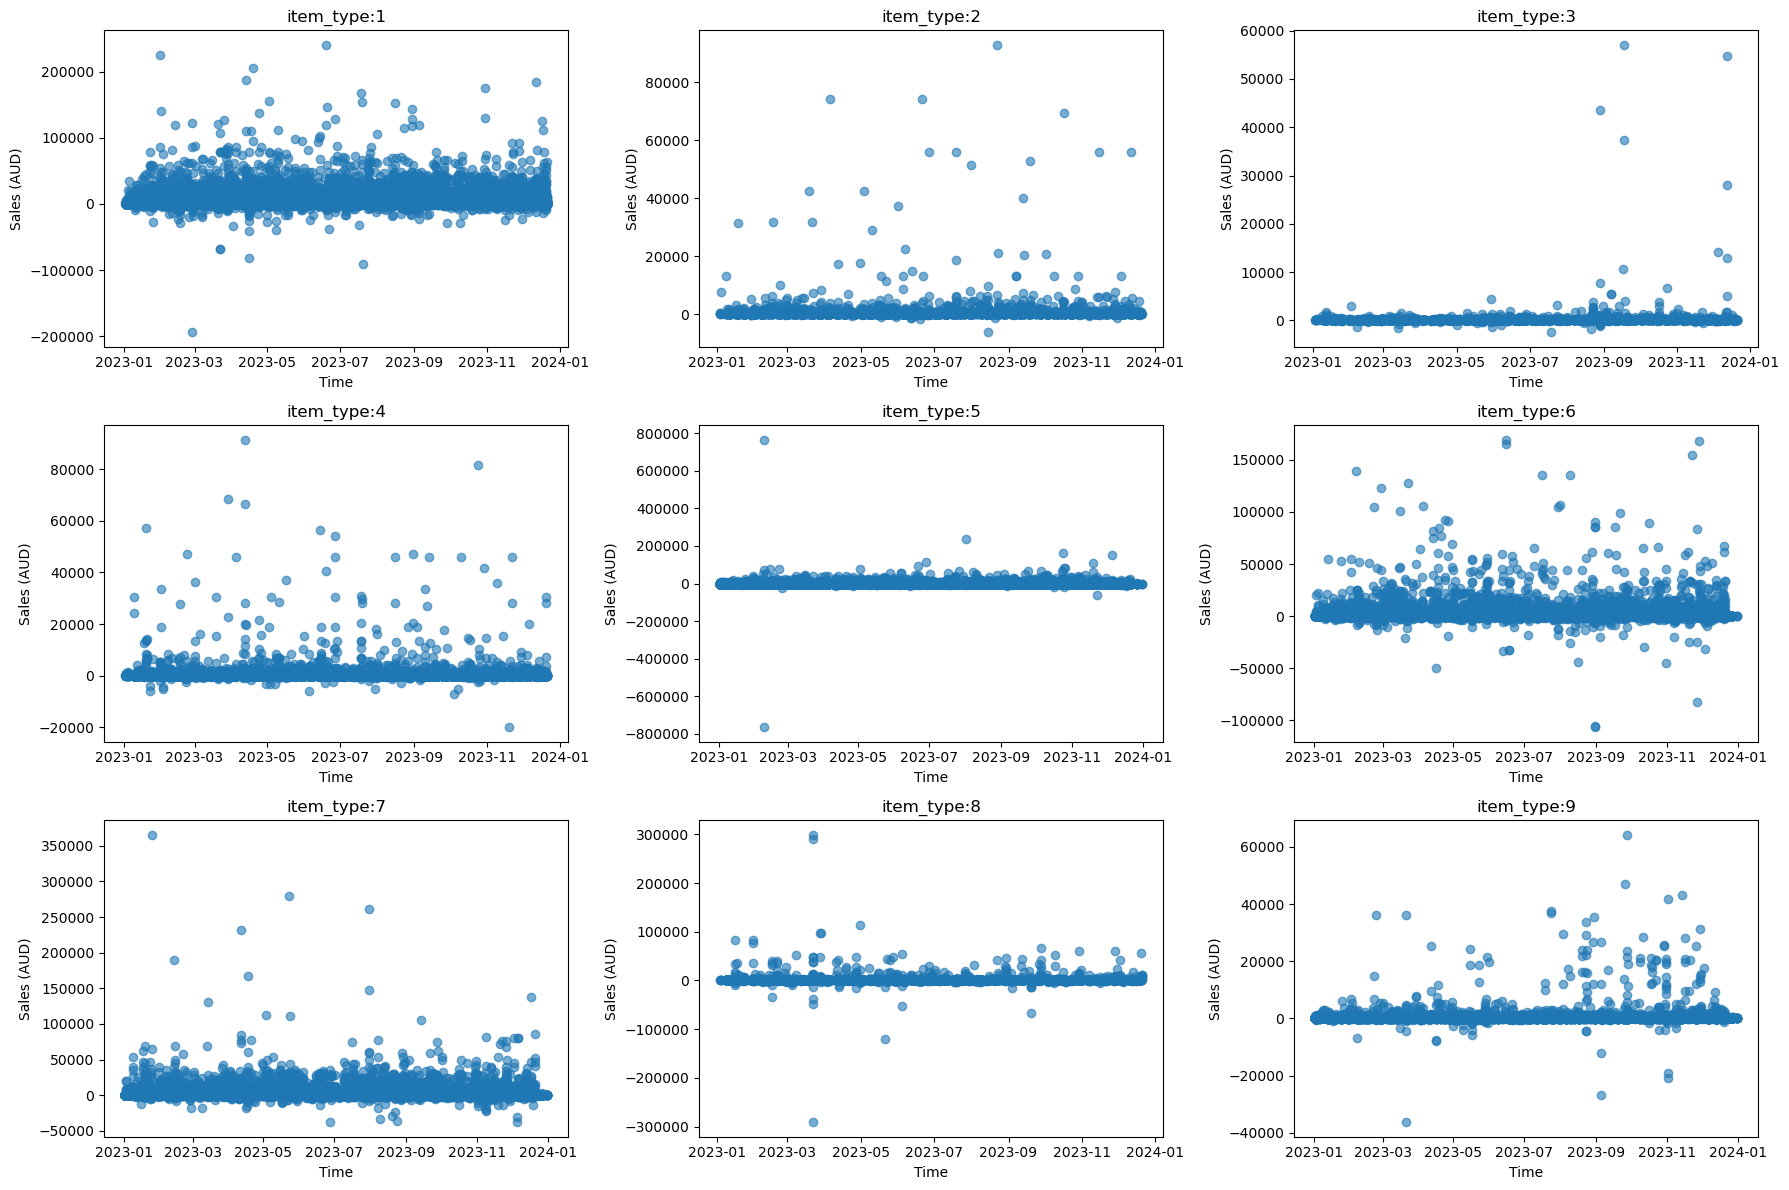

In [225]:
# to see the sales over time

cat, x, y = 'item_type','accounting_date','value_sales_aud'
cats = sorted(df_2023[cat].unique())
n = len(cats)

ncols = 3
nrows = -(-n // ncols)

plt.figure(figsize = (6 * ncols, 4 * nrows))

for i, c in enumerate(cats,1):
    subset = df_2023[df_2023[cat] == c]
    plt.subplot(nrows, ncols, i)
    plt.scatter(subset[x],subset[y],alpha = 0.6)
    plt.title(f"{cat}:{c}")
    plt.xlabel("Time")
    plt.ylabel("Sales (AUD)")
    
plt.tight_layout()
plt.show()

##### Boxplot

/var/folders/c6/xxws1v553296lnd2hthddtqh0000gn/T/ipykernel_26791/3984949111.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data ,labels = cats, showfliers=True, whis=1.5)


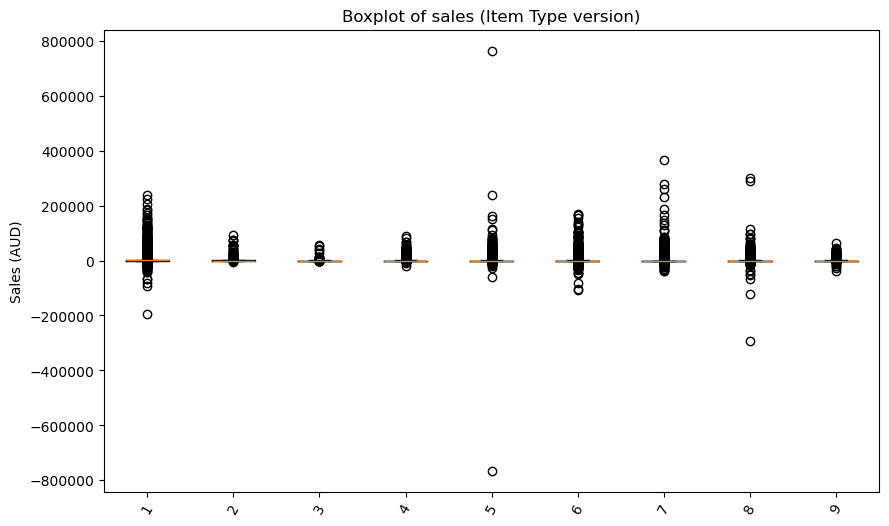

In [227]:
cat, val = 'item_type','value_sales_aud'
cats = sorted(df_2023[cat].unique())

data = [df_2023.loc[df_2023[cat].eq(c),val].values for c in cats]

plt.figure(figsize=(10,6))

plt.boxplot(data ,labels = cats, showfliers=True, whis=1.5)
plt.xticks(rotation=60)
plt.title('Boxplot of sales (Item Type version)')
plt.ylabel('Sales (AUD)')

plt.show()

#### Outlier Removal - IQR method

In [229]:
#calcuclate 25th percentile of transformed sales
percentile25 = df_2023.groupby("item_type")['value_sales_aud'].quantile(0.25)
print('percentile25:')
print(percentile25)
print()
#calcuclate 75th percentile of transformed sales
percentile75 = df_2023.groupby("item_type")['value_sales_aud'].quantile(0.75)
print('percentile75:')
print(percentile75)
print()
#calculate the IQR
iqr = percentile75 - percentile25
print('IQR:')
print(iqr)
print()
#locate the limitation range 
upper_limit = percentile75 + 1.5 * iqr
lower_limit = percentile25 - 1.5 * iqr

print('upper limit:')
print(upper_limit)
print()
print('lower limit:')
print(lower_limit)

# save these values in new columns for further adjustments
df_2023["percentile25"] = df_2023['item_type'].map(percentile25)
df_2023["percentile75"] = df_2023['item_type'].map(percentile75)
df_2023["lower end"] = df_2023['item_type'].map(lower_limit)
df_2023["upper end"] = df_2023['item_type'].map(upper_limit)
df_2023.head()

percentile25:
item_type
1    155.00
2     46.05
3     16.24
4     20.00
5     22.40
6     34.00
7     18.00
8     13.80
9     61.40
Name: value_sales_aud, dtype: float64

percentile75:
item_type
1    1531.5000
2     473.1000
3     147.4475
4     184.4300
5     168.0000
6     240.4300
7     120.0000
8     290.8400
9     202.5000
Name: value_sales_aud, dtype: float64

IQR:
item_type
1    1376.5000
2     427.0500
3     131.2075
4     164.4300
5     145.6000
6     206.4300
7     102.0000
8     277.0400
9     141.1000
Name: value_sales_aud, dtype: float64

upper limit:
item_type
1    3596.25000
2    1113.67500
3     344.25875
4     431.07500
5     386.40000
6     550.07500
7     273.00000
8     706.40000
9     414.15000
Name: value_sales_aud, dtype: float64

lower limit:
item_type
1   -1909.75000
2    -594.52500
3    -180.57125
4    -226.64500
5    -196.00000
6    -275.64500
7    -135.00000
8    -401.76000
9    -150.25000
Name: value_sales_aud, dtype: float64


,accounting_date,fiscal_year,fiscal_month,company_code,customer_district_code,item_code,business_area_code,item_group_code,item_class_code,item_type,...,line_number,invoice_date,customer_order_number,order_date,value_sales_aud,value_cost_aud,percentile25,percentile75,lower end,upper end
9,2023-02-02,2023,8,101,200,GENIE14WCDLES,LMP,LMP01008,LMP01,5,...,1,2023-02-02,12242270,2023-02-02,-6.38,-4.2428,22.4,168.0,-196.0,386.4
10,2023-03-01,2023,9,101,200,GENIE14WCDLES,LMP,LMP01008,LMP01,5,...,1,2023-03-01,5678554,2023-03-01,19.14,12.7284,22.4,168.0,-196.0,386.4
11,2023-05-03,2023,11,101,300,GENIE11WWWES,LMP,LMP01008,LMP01,5,...,3,2023-05-03,5721060,2023-04-27,439.18,292.7532,22.4,168.0,-196.0,386.4
13,2023-01-18,2023,7,101,400,GENIE18WCDLES,LMP,LMP01008,LMP01,5,...,1,2023-01-18,5641554,2023-01-11,229.68,152.7408,22.4,168.0,-196.0,386.4
14,2023-06-05,2023,12,101,300,GENIE11WWWES,LMP,LMP01008,LMP01,5,...,1,2023-06-05,5753970,2023-06-05,20.10,12.7284,22.4,168.0,-196.0,386.4


In [230]:
#isolate outliers on low end by group
sales_lower = df_2023[df_2023['value_sales_aud'] < df_2023['item_type'].map(lower_limit)]
sales_lower[["item_type",'value_sales_aud','lower end']]

,item_type,value_sales_aud,lower end
788,7,-541.50,-135.0
824,7,-361.00,-135.0
825,7,-1732.80,-135.0
949,5,-1008.42,-196.0
1116,7,-1014.61,-135.0
...,...,...,...
1036727,7,-399.00,-135.0
1036796,7,-447.50,-135.0
1036806,7,-154.38,-135.0
1036827,7,-868.50,-135.0


In [231]:
#isolate outliers on upper end by group
sales_upper = df_2023[df_2023['value_sales_aud'] > df_2023['item_type'].map(upper_limit)]
sales_upper[["item_type",'value_sales_aud','upper end']]

,item_type,value_sales_aud,upper end
11,5,439.18,386.40
15,1,3840.00,3596.25
184,5,502.50,386.40
218,1,36865.00,3596.25
256,5,402.00,386.40
...,...,...,...
1037150,7,436.00,273.00
1037152,7,1050.00,273.00
1037166,1,3992.00,3596.25
1037170,5,1222.08,386.40


In [232]:
#locate the medium sales for each type
median_sales = df_2023.groupby('item_type')['value_sales_aud'].median()
median_sales

item_type
1    470.390000
2    150.750000
3     49.500000
4     66.200000
5     62.100000
6     90.277778
7     45.600000
8     69.600000
9    123.600000
Name: value_sales_aud, dtype: float64

In [233]:
# create a new column to save the median value for each categories
df_2023["median_sales"] = df_2023.groupby("item_type")["value_sales_aud"].transform("median")
df_2023[['item_type','value_sales_aud','median_sales']]

,item_type,value_sales_aud,median_sales
9,5,-6.38,62.1
10,5,19.14,62.1
11,5,439.18,62.1
13,5,229.68,62.1
14,5,20.10,62.1
...,...,...,...
1037200,5,19.14,62.1
1037201,5,38.28,62.1
1037202,5,18.90,62.1
1037203,5,60.30,62.1


In [234]:
# create other columns to save the transformed replaced value 
df_2023['is outlier'] = ~df_2023["value_sales_aud"].between(df_2023['lower end'], df_2023['upper end'], inclusive='both')
df_2023['value_sales_fixed'] = df_2023['value_sales_aud'].mask(df_2023['is outlier'],df_2023['median_sales'])
df_2023[['item_type','value_sales_aud','median_sales','is outlier', 'value_sales_fixed']]

,item_type,value_sales_aud,median_sales,is outlier,value_sales_fixed
9,5,-6.38,62.1,False,-6.38
10,5,19.14,62.1,False,19.14
11,5,439.18,62.1,True,62.10
13,5,229.68,62.1,False,229.68
14,5,20.10,62.1,False,20.10
...,...,...,...,...,...
1037200,5,19.14,62.1,False,19.14
1037201,5,38.28,62.1,False,38.28
1037202,5,18.90,62.1,False,18.90
1037203,5,60.30,62.1,False,60.30


/var/folders/c6/xxws1v553296lnd2hthddtqh0000gn/T/ipykernel_26791/4206998530.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_bf ,labels = order, vert=False, showfliers=True, whis=1.5)
/var/folders/c6/xxws1v553296lnd2hthddtqh0000gn/T/ipykernel_26791/4206998530.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_af ,labels = order, vert=False, showfliers=True, whis=1.5)


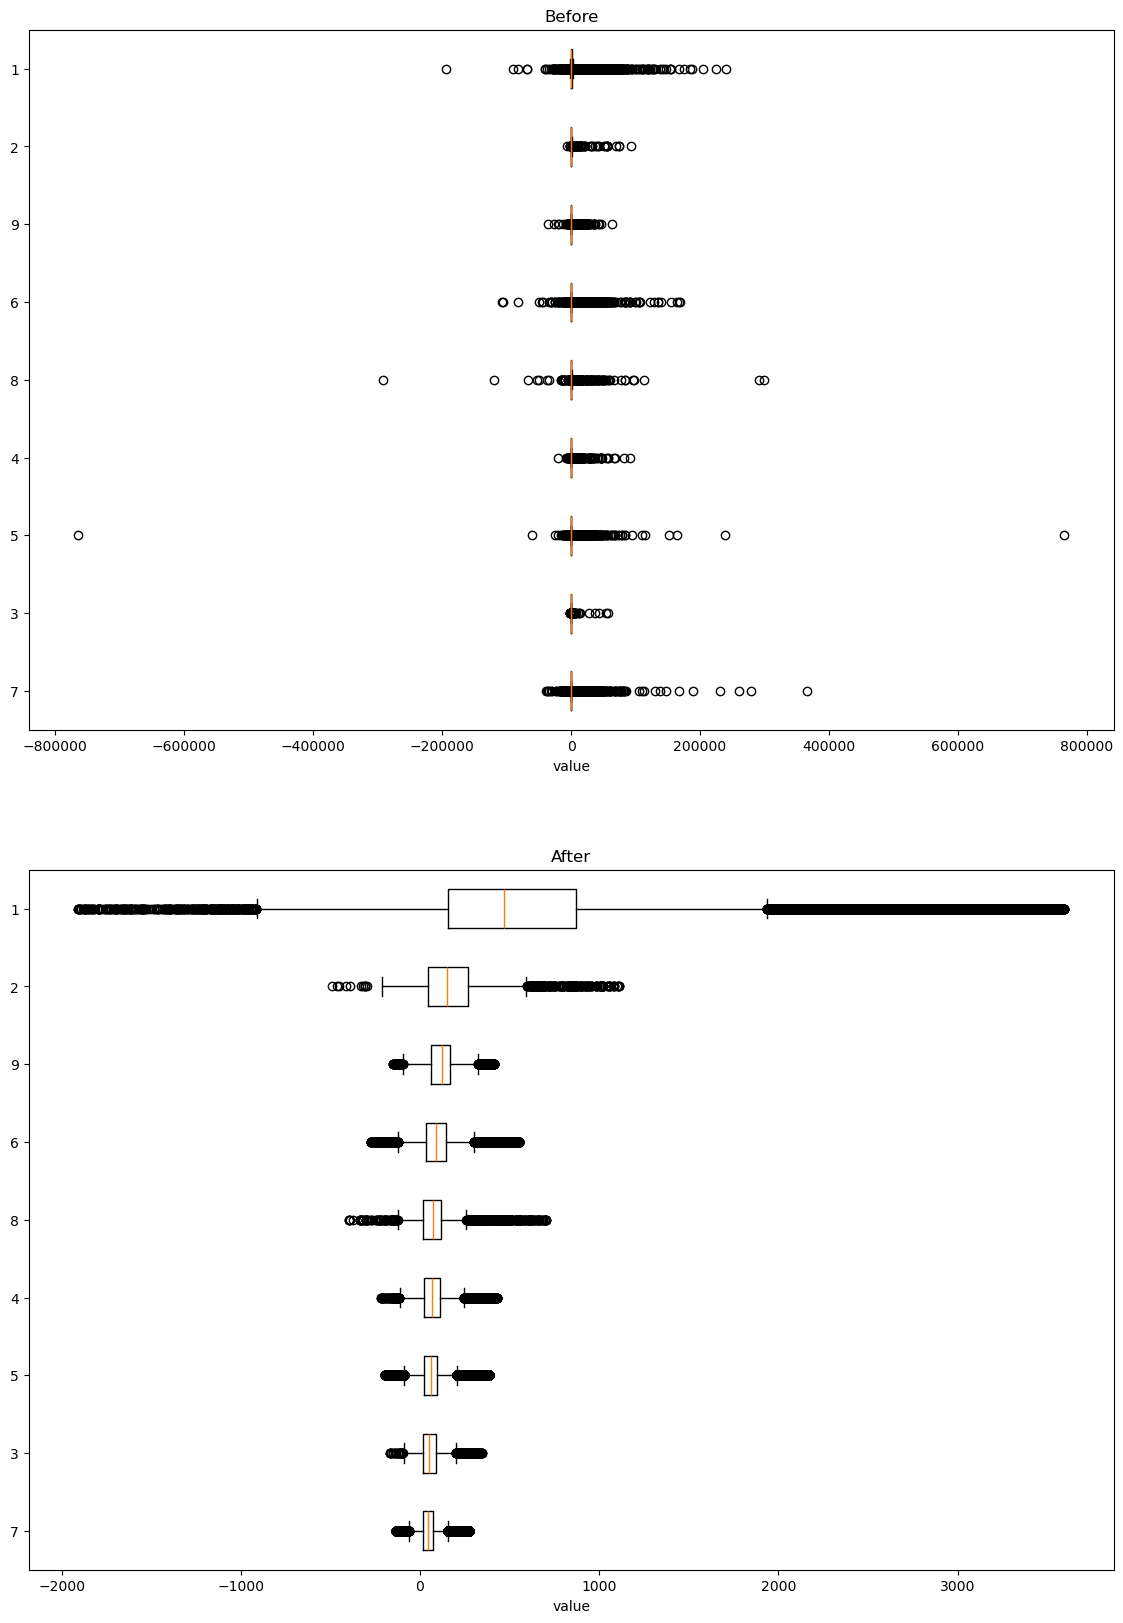

In [235]:
# review the result of outlier fixing  

#boxplot
cat, before, after = 'item_type', 'value_sales_aud', 'value_sales_fixed'

order = (df_2023.groupby(cat)[before].median().sort_values().index)

data_bf = [df_2023.loc[df_2023[cat].eq(c),before].values for c in order]
data_af = [df_2023.loc[df_2023[cat].eq(c),after].values for c in order]

plt.figure(figsize=(14, 20))

plt.subplot(2,1,1)
plt.boxplot(data_bf ,labels = order, vert=False, showfliers=True, whis=1.5)
plt.title ('Before')
plt.xlabel('value')

plt.subplot(2,1,2)
plt.boxplot(data_af ,labels = order, vert=False, showfliers=True, whis=1.5)
plt.title ('After')
plt.xlabel('value')


plt.show()

#### Transformation

##### Histogram

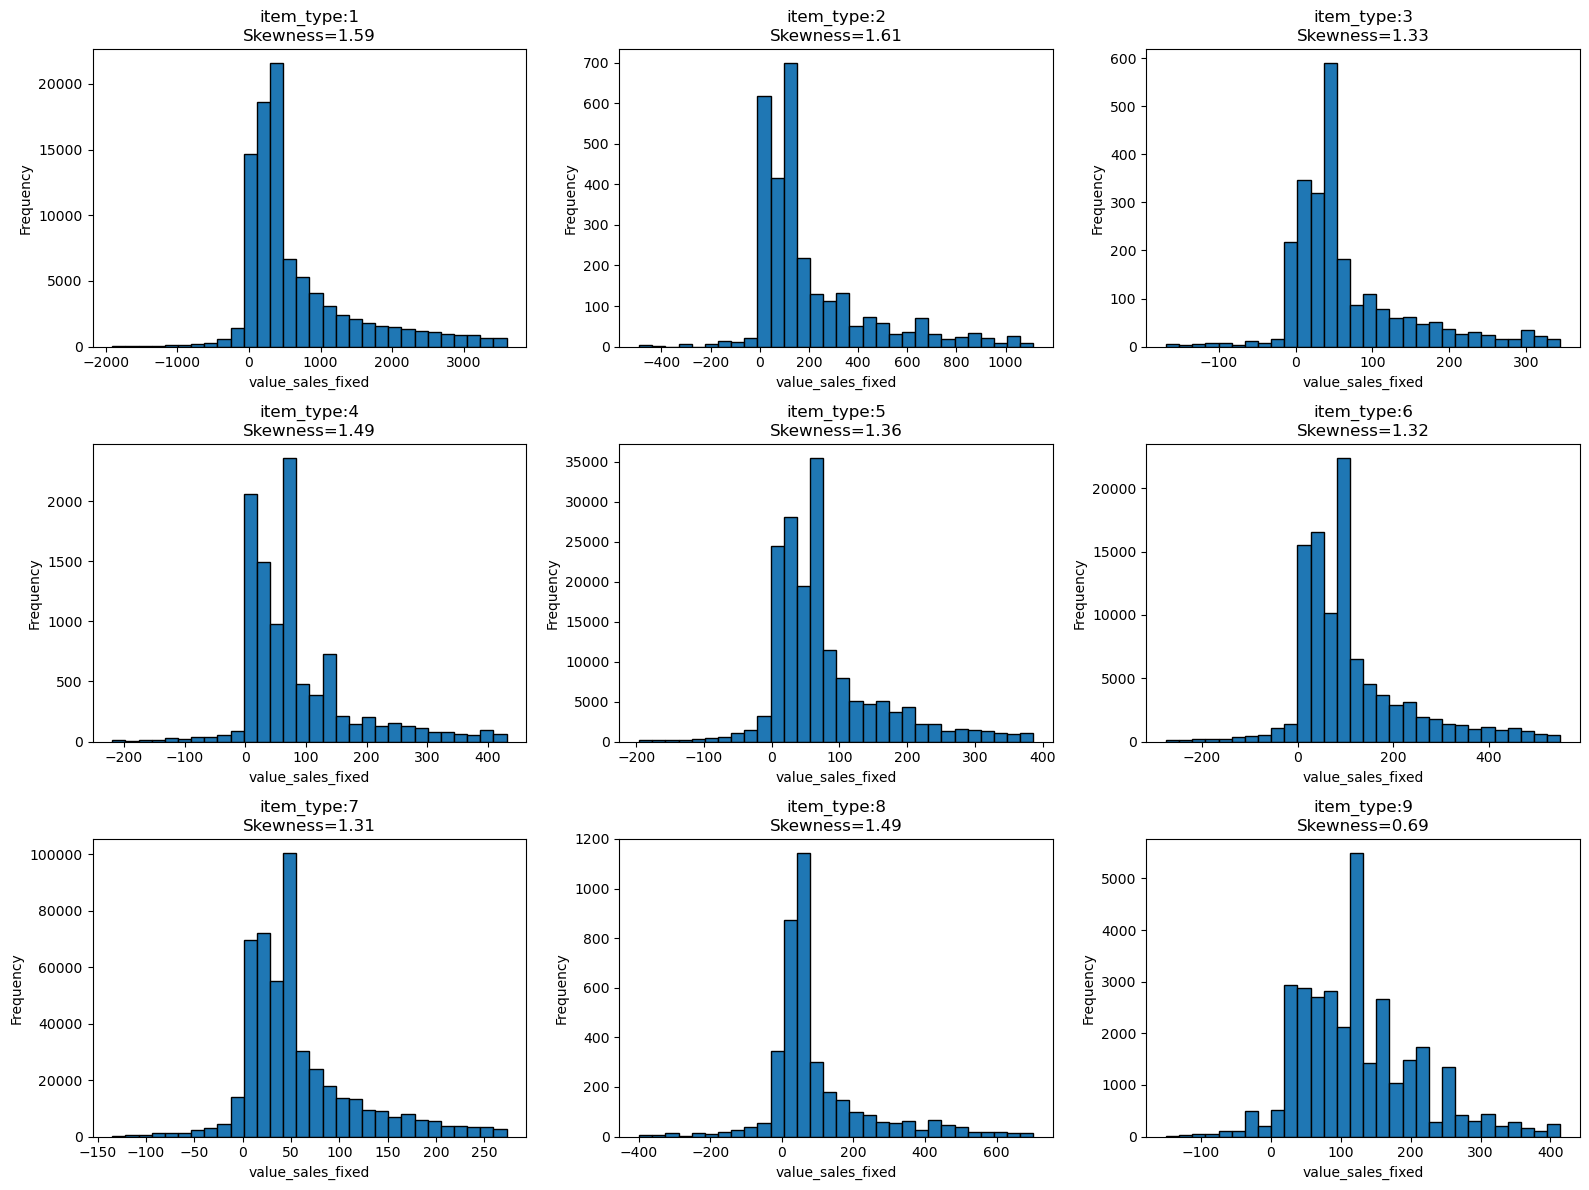

In [238]:
# visualization on skewness
cat, col = 'item_type','value_sales_fixed'
cats = sorted(df_2023[cat].unique())

nrows, ncols = 3,3
plt.figure(figsize=(16, 12))

for i,c in enumerate(cats[:nrows * ncols], 1):
    plt.subplot(nrows,ncols,i)
    data = df_2023.loc[df_2023[cat] == c, 'value_sales_fixed']
    skew_val = data.skew()
    plt.hist(data,bins=30,edgecolor='black')
    plt.title(f'{cat}:{c}\nSkewness={skew_val:.2f}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [239]:
skew_by_cat = df_2023.groupby(cat)[col].skew()
print(skew_by_cat)

item_type
1    1.587912
2    1.608515
3    1.331317
4    1.486684
5    1.364880
6    1.318013
7    1.314193
8    1.492505
9    0.694779
Name: value_sales_fixed, dtype: float64


##### Sign Log Transformation

In [241]:
def signed_log(x):
    x = pd.to_numeric(x, errors='coerce')
    return np.sign(x) * np.log(np.abs(x))
    
df_2023['value_sales_log'] = signed_log(df_2023['value_sales_fixed'])

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


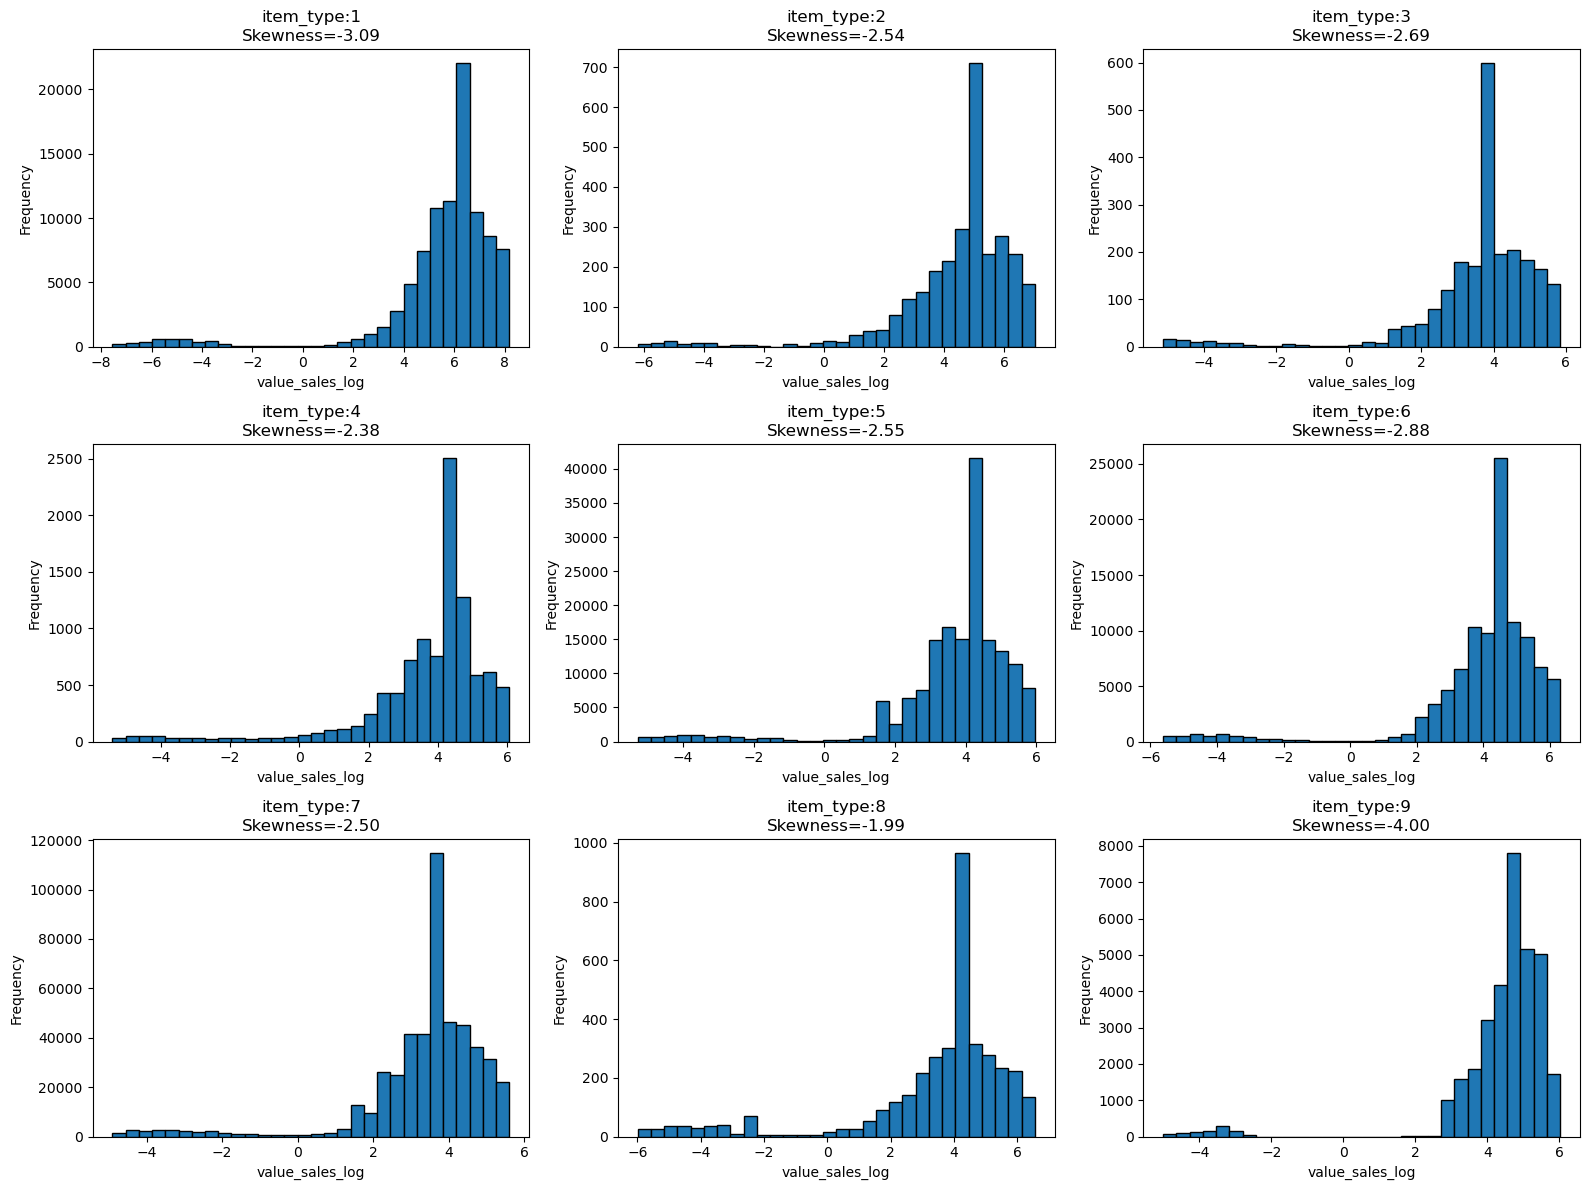

In [242]:
# visualization on skewness
cat1, col1 = 'item_type','value_sales_log'
cats1 = sorted(df_2023[cat1].unique())

nrows, ncols = 3,3
plt.figure(figsize=(16, 12))

for i,c in enumerate(cats1[:nrows * ncols], 1):
    plt.subplot(nrows,ncols,i)
    data = df_2023.loc[df_2023[cat1] == c, 'value_sales_log']
    skew_val = data.skew()
    plt.hist(data,bins=30,edgecolor='black')
    plt.title(f'{cat1}:{c}\nSkewness={skew_val:.2f}')
    plt.xlabel(col1)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [243]:
skew_by_cat = df_2023.groupby(cat1)[col1].skew()
print(skew_by_cat)

item_type
1   -3.086740
2   -2.540237
3   -2.687007
4   -2.383665
5   -2.552364
6   -2.878734
7   -2.496968
8   -1.991023
9   -3.995827
Name: value_sales_log, dtype: float64


##### Square Root

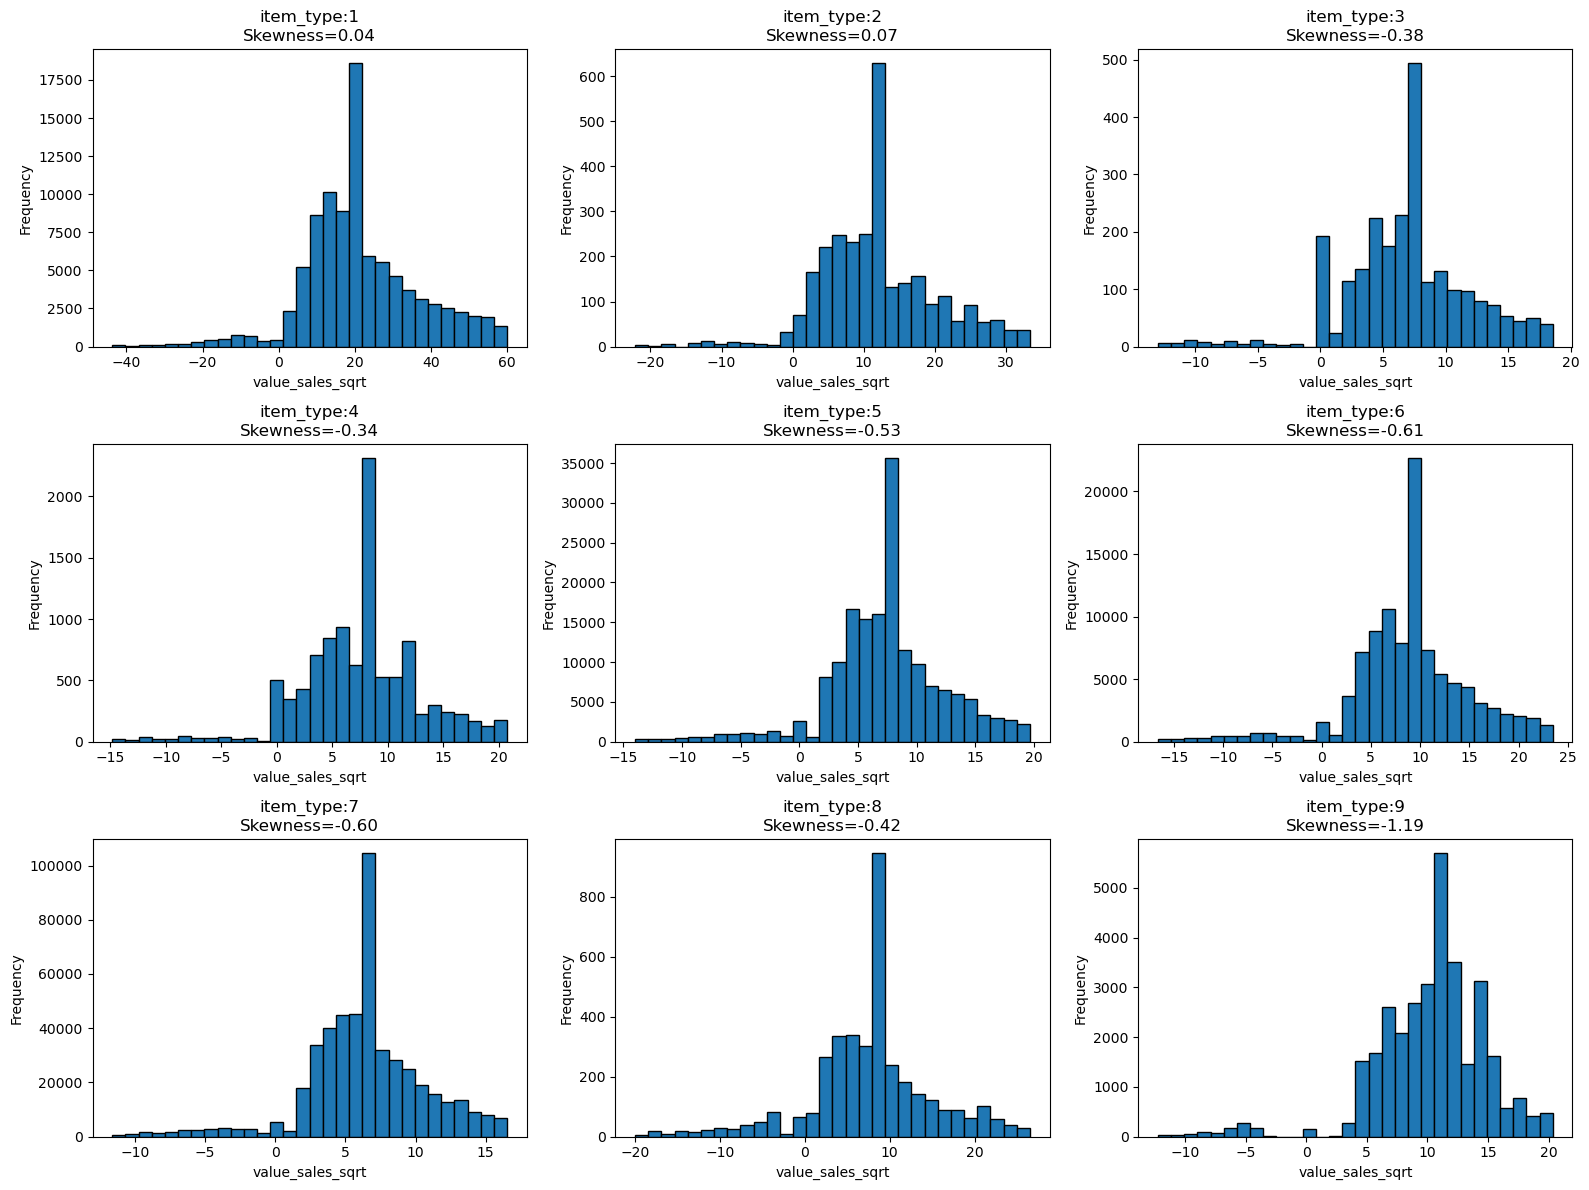

item_type
1    0.040611
2    0.072942
3   -0.384912
4   -0.339853
5   -0.530581
6   -0.607792
7   -0.599351
8   -0.423036
9   -1.192216
Name: value_sales_sqrt, dtype: float64


In [245]:
def signed_sqrt(x):
    x = pd.to_numeric(x, errors = 'coerce')
    return np.sign(x) * np.sqrt(np.abs(x))

df_2023['value_sales_sqrt'] = signed_sqrt(df_2023['value_sales_fixed'])
# visualization on skewness
cat2, col2 = 'item_type','value_sales_sqrt'
cats2 = sorted(df_2023[cat2].unique())

nrows, ncols = 3,3
plt.figure(figsize=(16, 12))

for i,c in enumerate(cats2[:nrows * ncols], 1):
    plt.subplot(nrows,ncols,i)
    data = df_2023.loc[df_2023[cat2] == c, 'value_sales_sqrt']
    skew_val = data.skew()
    plt.hist(data,bins=30,edgecolor='black')
    plt.title(f'{cat2}:{c}\nSkewness={skew_val:.2f}')
    plt.xlabel(col2)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# list out skewness
skew_by_cat = df_2023.groupby(cat2)[col2].skew()
print(skew_by_cat)

##### Yeo-Johnson as BoxCox only works on postive value

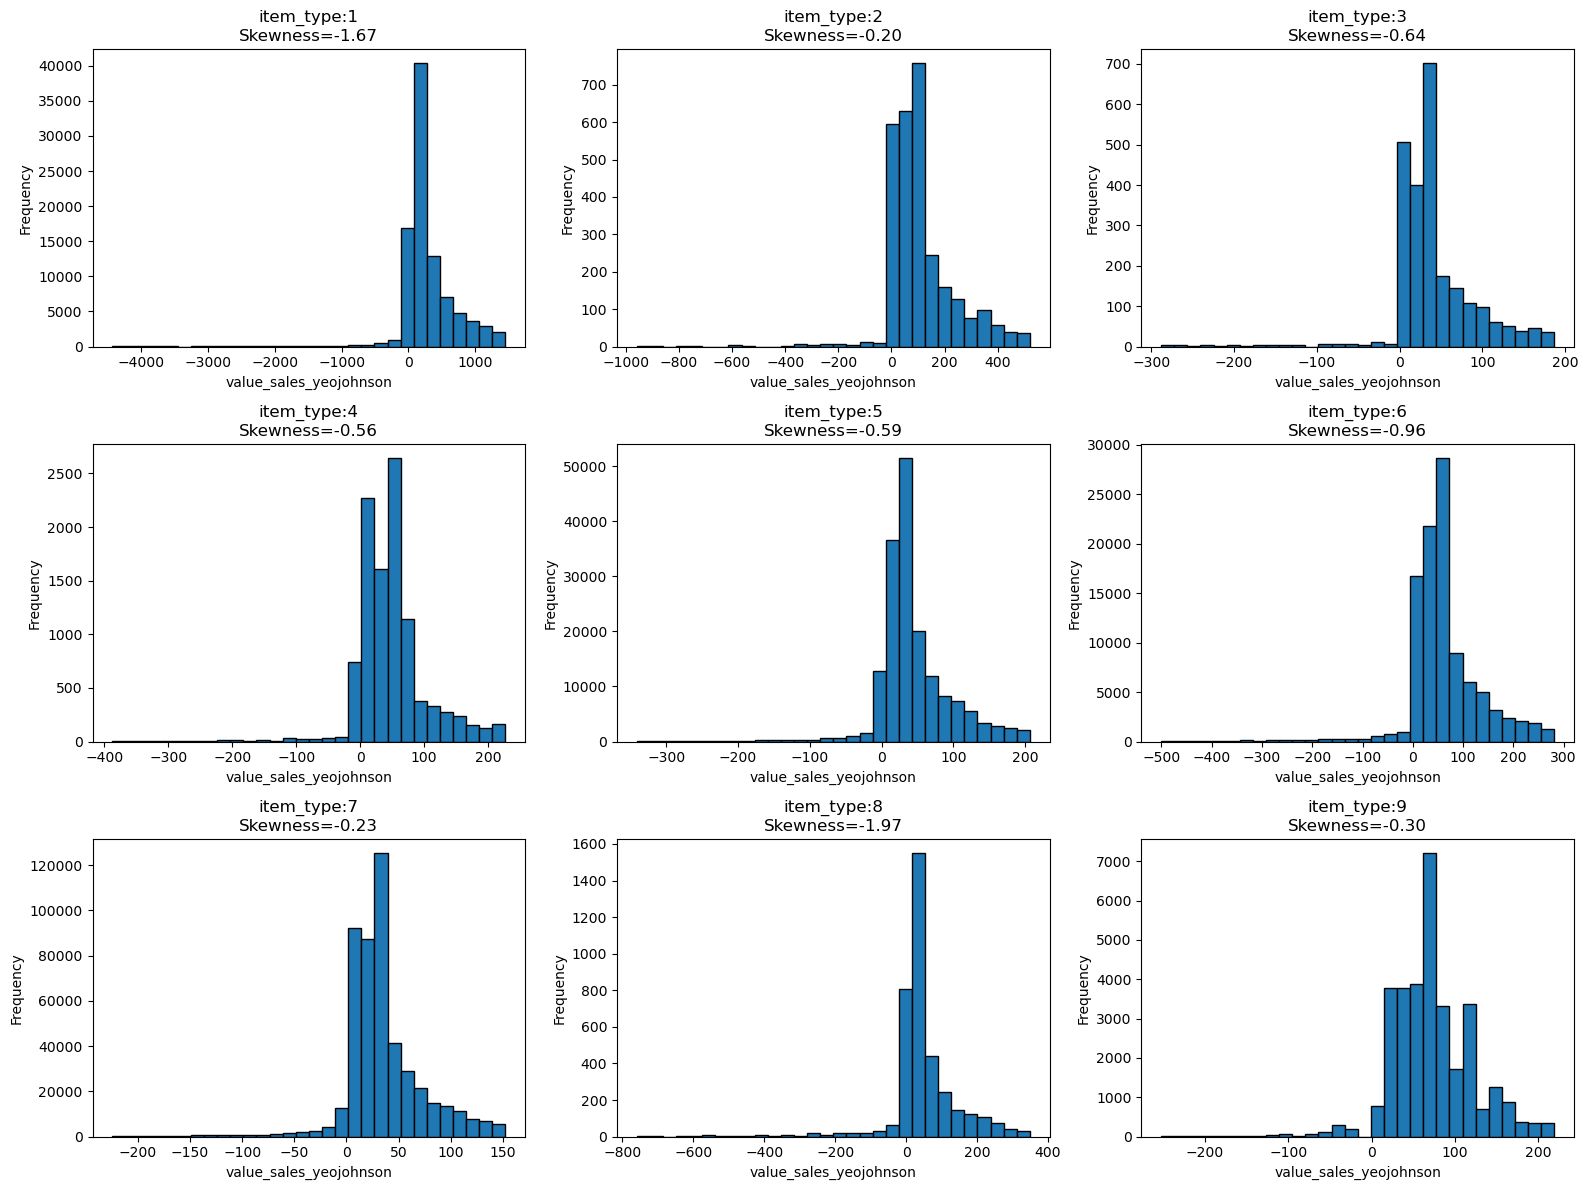

item_type
1   -1.674645
2   -0.195903
3   -0.637647
4   -0.562250
5   -0.585752
6   -0.959741
7   -0.229301
8   -1.966763
9   -0.303762
Name: value_sales_yeojohnson, dtype: float64


In [247]:
pt = PowerTransformer(method = 'yeo-johnson', standardize = False)
df_2023['value_sales_yeojohnson'] = pt.fit_transform(df_2023[['value_sales_fixed']]) 

# visualization on skewness
cat3, col3 = 'item_type','value_sales_yeojohnson'
cats3 = sorted(df_2023[cat3].unique())

nrows, ncols = 3,3
plt.figure(figsize=(16, 12))

for i,c in enumerate(cats3[:nrows * ncols], 1):
    plt.subplot(nrows,ncols,i)
    data = df_2023.loc[df_2023[cat3] == c, 'value_sales_yeojohnson']
    skew_val = data.skew()
    plt.hist(data,bins=30,edgecolor='black')
    plt.title(f'{cat3}:{c}\nSkewness={skew_val:.2f}')
    plt.xlabel(col3)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

skew_by_cat = df_2023.groupby(cat3)[col3].skew()
print(skew_by_cat)

### Value_Sales (AUD) 2024

#### Visualization - outliers

##### Scatter Plot

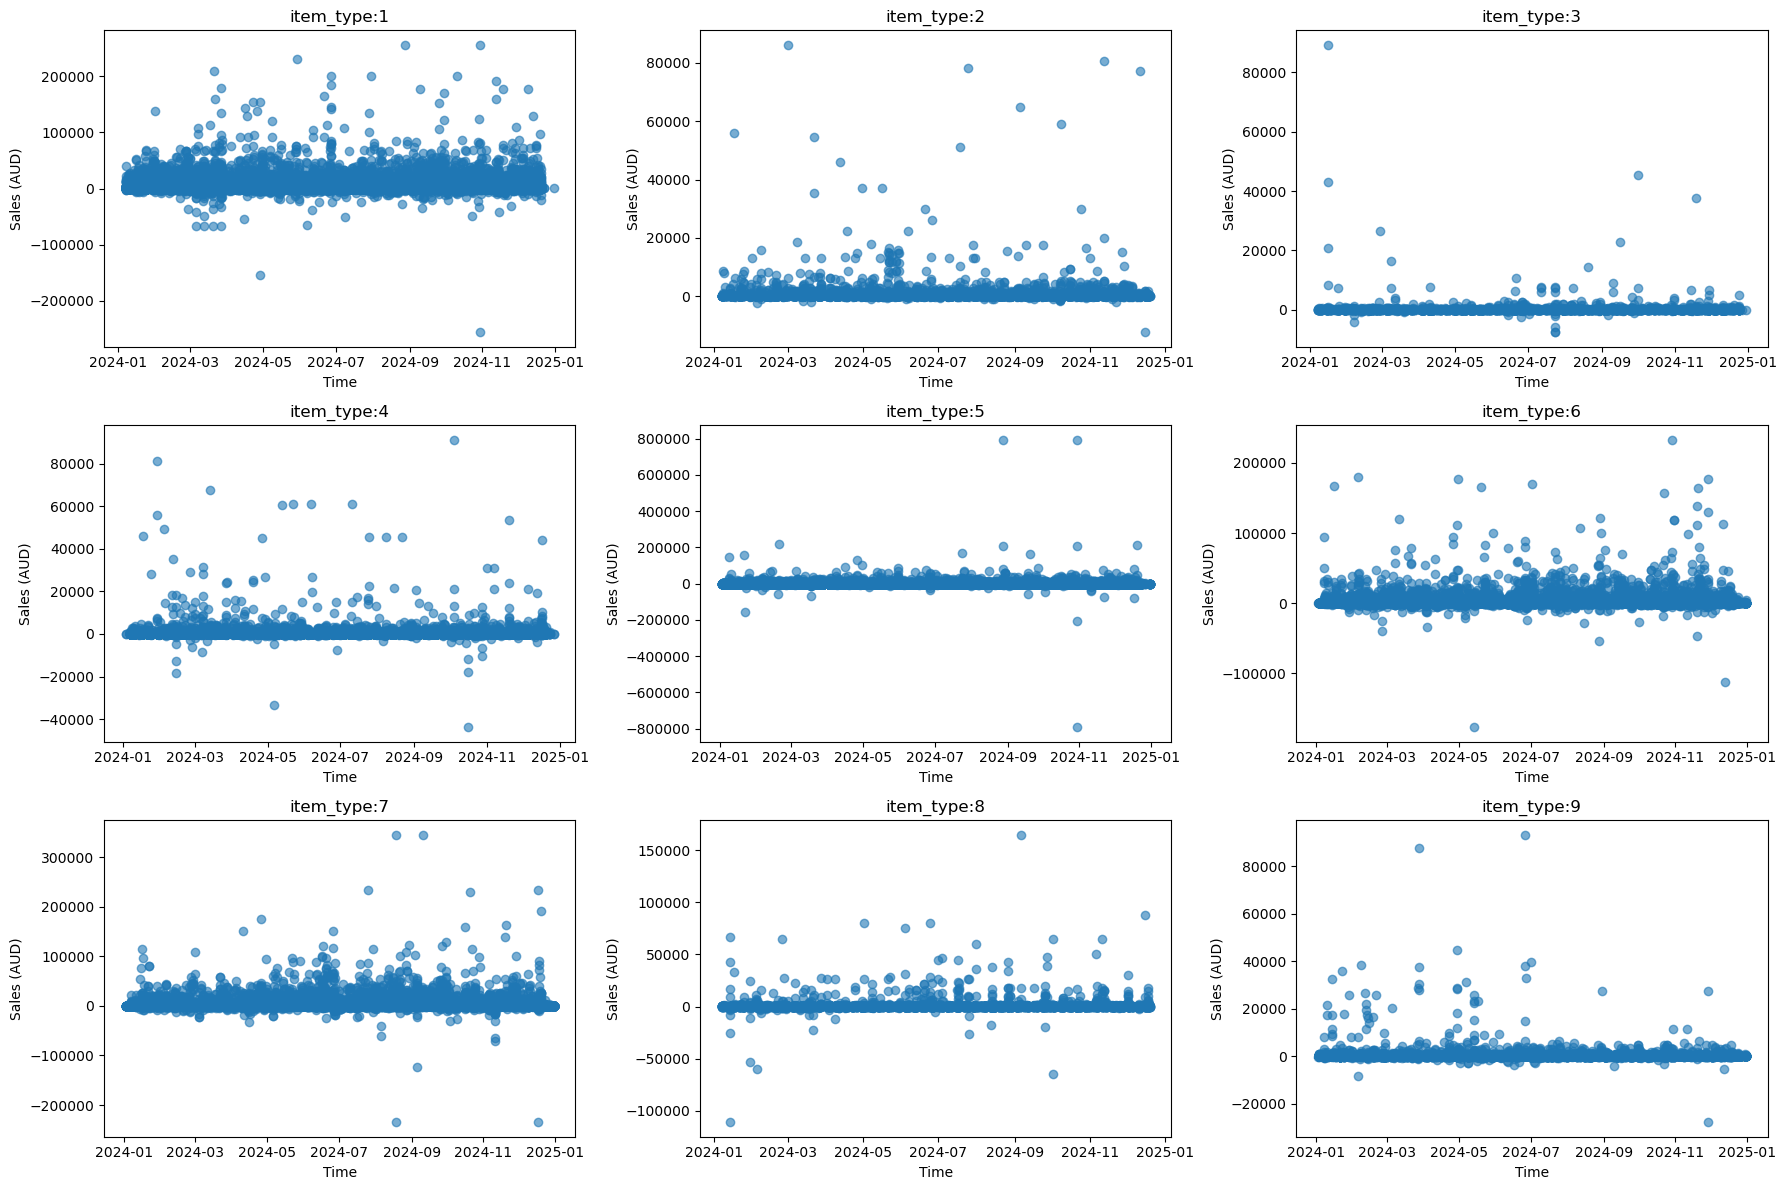

In [251]:
# to see the sales over time

cat, x, y = 'item_type','accounting_date','value_sales_aud'
cats = sorted(df_2024[cat].unique())
n = len(cats)

ncols = 3
nrows = -(-n // ncols)

plt.figure(figsize = (6 * ncols, 4 * nrows))

for i, c in enumerate(cats,1):
    subset = df_2024[df_2024[cat] == c]
    plt.subplot(nrows, ncols, i)
    plt.scatter(subset[x],subset[y],alpha = 0.6)
    plt.title(f"{cat}:{c}")
    plt.xlabel("Time")
    plt.ylabel("Sales (AUD)")
    
plt.tight_layout()
plt.show()

##### Boxplot

/var/folders/c6/xxws1v553296lnd2hthddtqh0000gn/T/ipykernel_26791/1558148181.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data ,labels = cats, showfliers=True, whis=1.5)


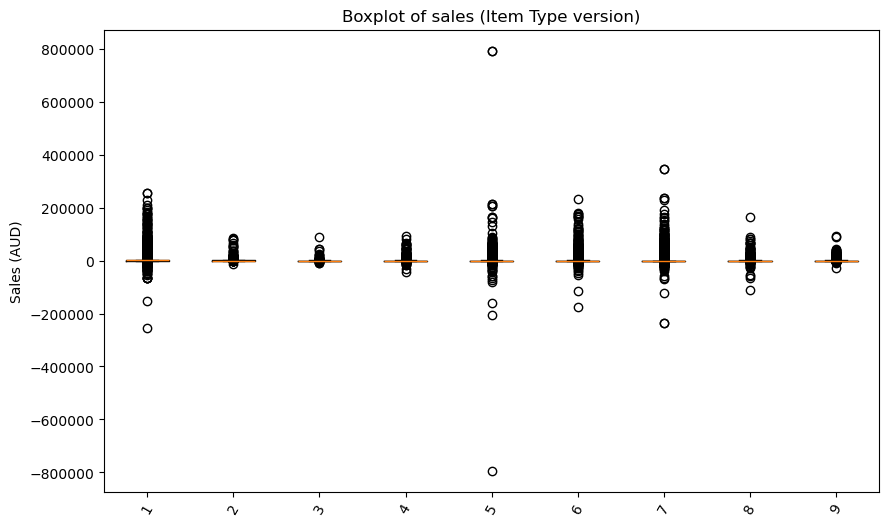

In [253]:
cat, val = 'item_type','value_sales_aud'
cats = sorted(df_2024[cat].unique())

data = [df_2024.loc[df_2024[cat].eq(c),val].values for c in cats]

plt.figure(figsize=(10,6))

plt.boxplot(data ,labels = cats, showfliers=True, whis=1.5)
plt.xticks(rotation=60)
plt.title('Boxplot of sales (Item Type version)')
plt.ylabel('Sales (AUD)')

plt.show()

#### Outlier Removal - IQR method

In [255]:
#calcuclate 25th percentile of transformed sales
percentile25 = df_2024.groupby("item_type")['value_sales_aud'].quantile(0.25)
print('percentile25:')
print(percentile25)
print()
#calcuclate 75th percentile of transformed sales
percentile75 = df_2024.groupby("item_type")['value_sales_aud'].quantile(0.75)
print('percentile75:')
print(percentile75)
print()
#calculate the IQR
iqr = percentile75 - percentile25
print('IQR:')
print(iqr)
print()
#locate the limitation range 
upper_limit = percentile75 + 1.5 * iqr
lower_limit = percentile25 - 1.5 * iqr

print('upper limit:')
print(upper_limit)
print()
print('lower limit:')
print(lower_limit)

# save these values in new columns for further adjustments
df_2024["percentile25"] = df_2024['item_type'].map(percentile25)
df_2024["percentile75"] = df_2024['item_type'].map(percentile75)
df_2024["lower end"] = df_2024['item_type'].map(lower_limit)
df_2024["upper end"] = df_2024['item_type'].map(upper_limit)
df_2024.head()

percentile25:
item_type
1    162.000000
2     52.240000
3     15.352500
4     20.700000
5     24.000000
6     28.073394
7     18.000000
8     18.490000
9     57.120000
Name: value_sales_aud, dtype: float64

percentile75:
item_type
1    1667.8575
2     684.0000
3     180.0600
4     230.0000
5     165.3000
6     220.0000
7     135.0000
8     263.5200
9     185.4000
Name: value_sales_aud, dtype: float64

IQR:
item_type
1    1505.857500
2     631.760000
3     164.707500
4     209.300000
5     141.300000
6     191.926606
7     117.000000
8     245.030000
9     128.280000
Name: value_sales_aud, dtype: float64

upper limit:
item_type
1    3926.643750
2    1631.640000
3     427.121250
4     543.950000
5     377.250000
6     507.889908
7     310.500000
8     631.065000
9     377.820000
Name: value_sales_aud, dtype: float64

lower limit:
item_type
1   -2096.786250
2    -895.400000
3    -231.708750
4    -293.250000
5    -187.950000
6    -259.816514
7    -157.500000
8    -349.055000
9    -135.3000

,accounting_date,fiscal_year,fiscal_month,company_code,customer_district_code,item_code,business_area_code,item_group_code,item_class_code,item_type,...,line_number,invoice_date,customer_order_number,order_date,value_sales_aud,value_cost_aud,percentile25,percentile75,lower end,upper end
5,2024-03-28,2024,9,205,400,10364,COM,COM03002,COM03,5,...,0.0,2024-03-28,1699676,2024-03-27,22.5,14.0700,24.0,165.3,-187.95,377.25
6,2024-03-06,2024,9,205,200,10364,COM,COM03002,COM03,5,...,0.0,2024-03-06,1681992,2024-03-05,7.5,4.6900,24.0,165.3,-187.95,377.25
28,2024-03-15,2024,9,205,500,11154,LMP,LMP04002,LMP04,5,...,0.0,2024-03-15,1689880,2024-03-15,122.4,44.7015,24.0,165.3,-187.95,377.25
29,2024-05-27,2024,11,205,500,11154,LMP,LMP04002,LMP04,5,...,0.0,2024-05-27,1748484,2024-05-27,24.0,7.8190,24.0,165.3,-187.95,377.25
30,2024-05-06,2024,11,205,500,11154,LMP,LMP04002,LMP04,5,...,0.0,2024-05-06,1729118,2024-05-06,24.0,7.8190,24.0,165.3,-187.95,377.25


In [256]:
#isolate outliers on lower end by group
sales_lower = df_2024[df_2024['value_sales_aud'] < df_2024['item_type'].map(lower_limit)]
#isolate outliers on upper end by group
sales_upper = df_2024[df_2024['value_sales_aud'] > df_2024['item_type'].map(upper_limit)]
#locate the medium sales for each type
median_sales = df_2024.groupby('item_type')['value_sales_aud'].median()
# create a new column to save the median value for each categories
df_2024["median_sales"] = df_2024.groupby("item_type")["value_sales_aud"].transform("median")
# create other columns to save the transformed replaced value 
df_2024['is outlier'] = ~df_2024["value_sales_aud"].between(df_2024['lower end'], df_2024['upper end'], inclusive='both')
df_2024['value_sales_fixed'] = df_2024['value_sales_aud'].mask(df_2024['is outlier'],df_2024['median_sales'])
df_2024[['item_type','value_sales_aud','median_sales','is outlier', 'value_sales_fixed']]

,item_type,value_sales_aud,median_sales,is outlier,value_sales_fixed
5,5,22.50,66.535229,False,22.50
6,5,7.50,66.535229,False,7.50
28,5,122.40,66.535229,False,122.40
29,5,24.00,66.535229,False,24.00
30,5,24.00,66.535229,False,24.00
...,...,...,...,...,...
951172,5,244.00,66.535229,False,244.00
951173,1,1185.00,498.000000,False,1185.00
951174,6,232.19,73.500000,False,232.19
951175,5,31.00,66.535229,False,31.00


/var/folders/c6/xxws1v553296lnd2hthddtqh0000gn/T/ipykernel_26791/3070431451.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_bf ,labels = order, vert=False, showfliers=True, whis=1.5)
/var/folders/c6/xxws1v553296lnd2hthddtqh0000gn/T/ipykernel_26791/3070431451.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_af ,labels = order, vert=False, showfliers=True, whis=1.5)


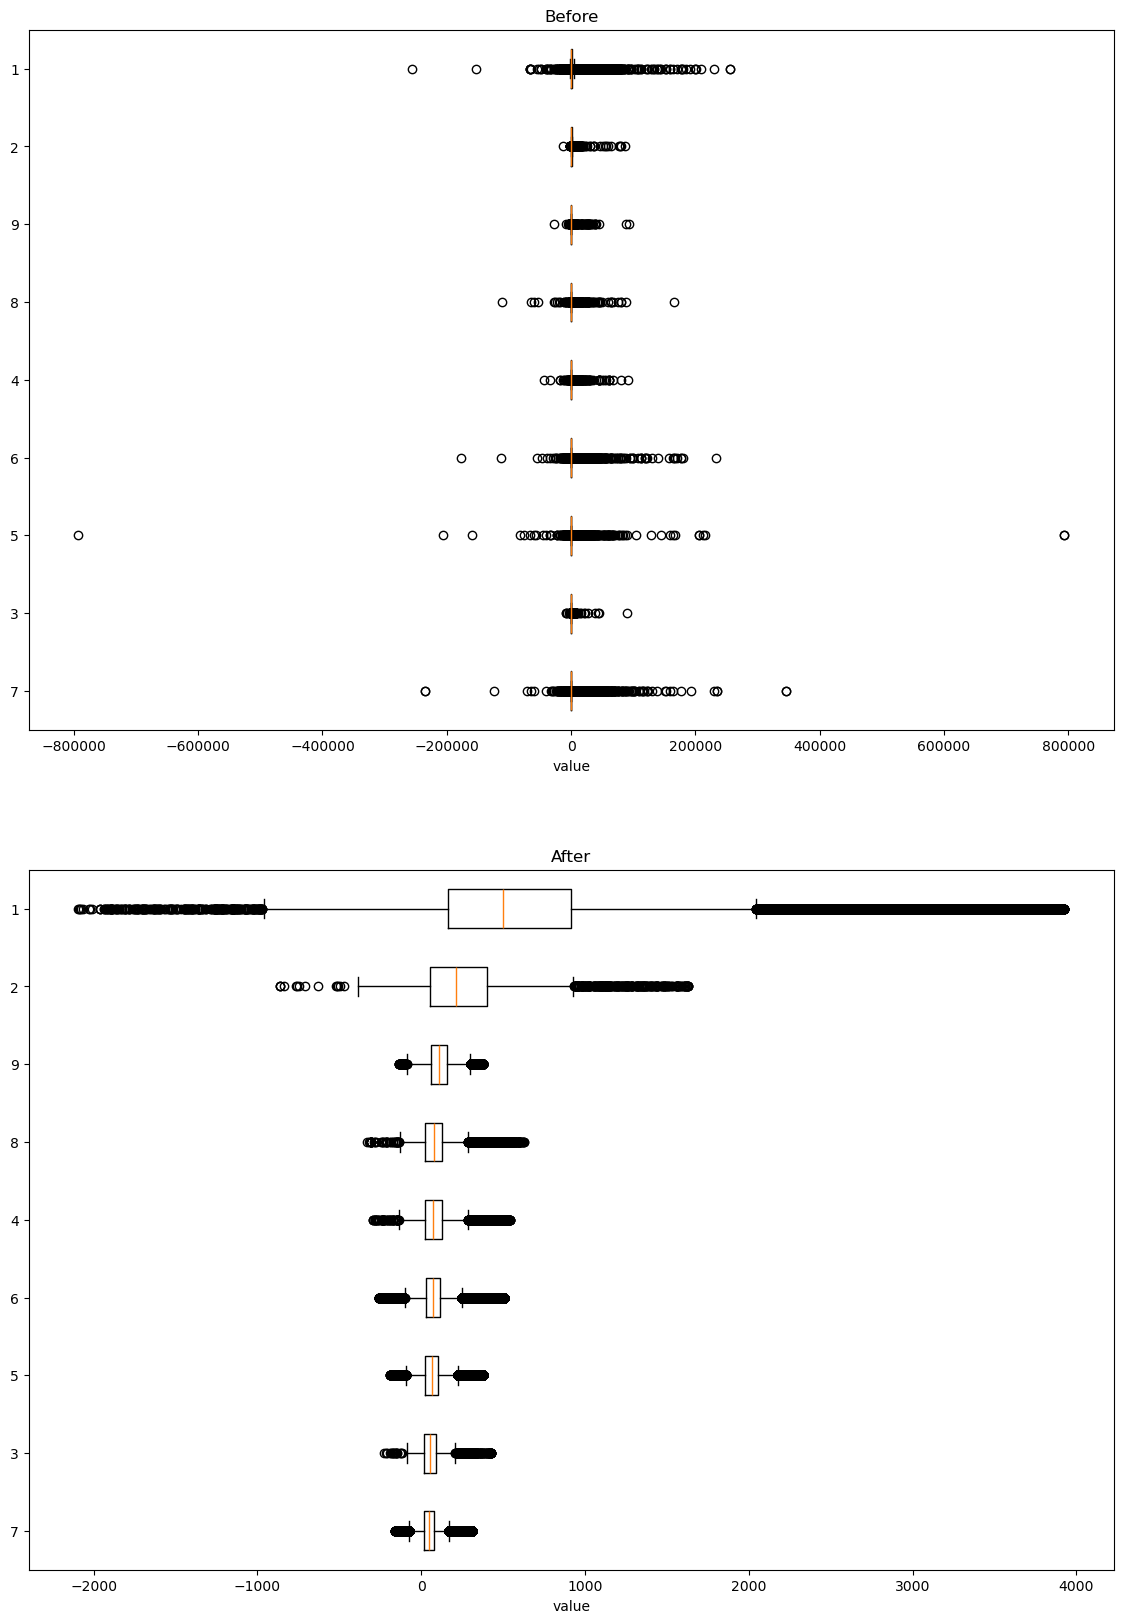

In [257]:
# review the result of outlier fixing  

#boxplot
cat, before, after = 'item_type', 'value_sales_aud', 'value_sales_fixed'

order = (df_2024.groupby(cat)[before].median().sort_values().index)

data_bf = [df_2024.loc[df_2024[cat].eq(c),before].values for c in order]
data_af = [df_2024.loc[df_2024[cat].eq(c),after].values for c in order]

plt.figure(figsize=(14, 20))

plt.subplot(2,1,1)
plt.boxplot(data_bf ,labels = order, vert=False, showfliers=True, whis=1.5)
plt.title ('Before')
plt.xlabel('value')

plt.subplot(2,1,2)
plt.boxplot(data_af ,labels = order, vert=False, showfliers=True, whis=1.5)
plt.title ('After')
plt.xlabel('value')


plt.show()

#### Transformation

##### Histogram

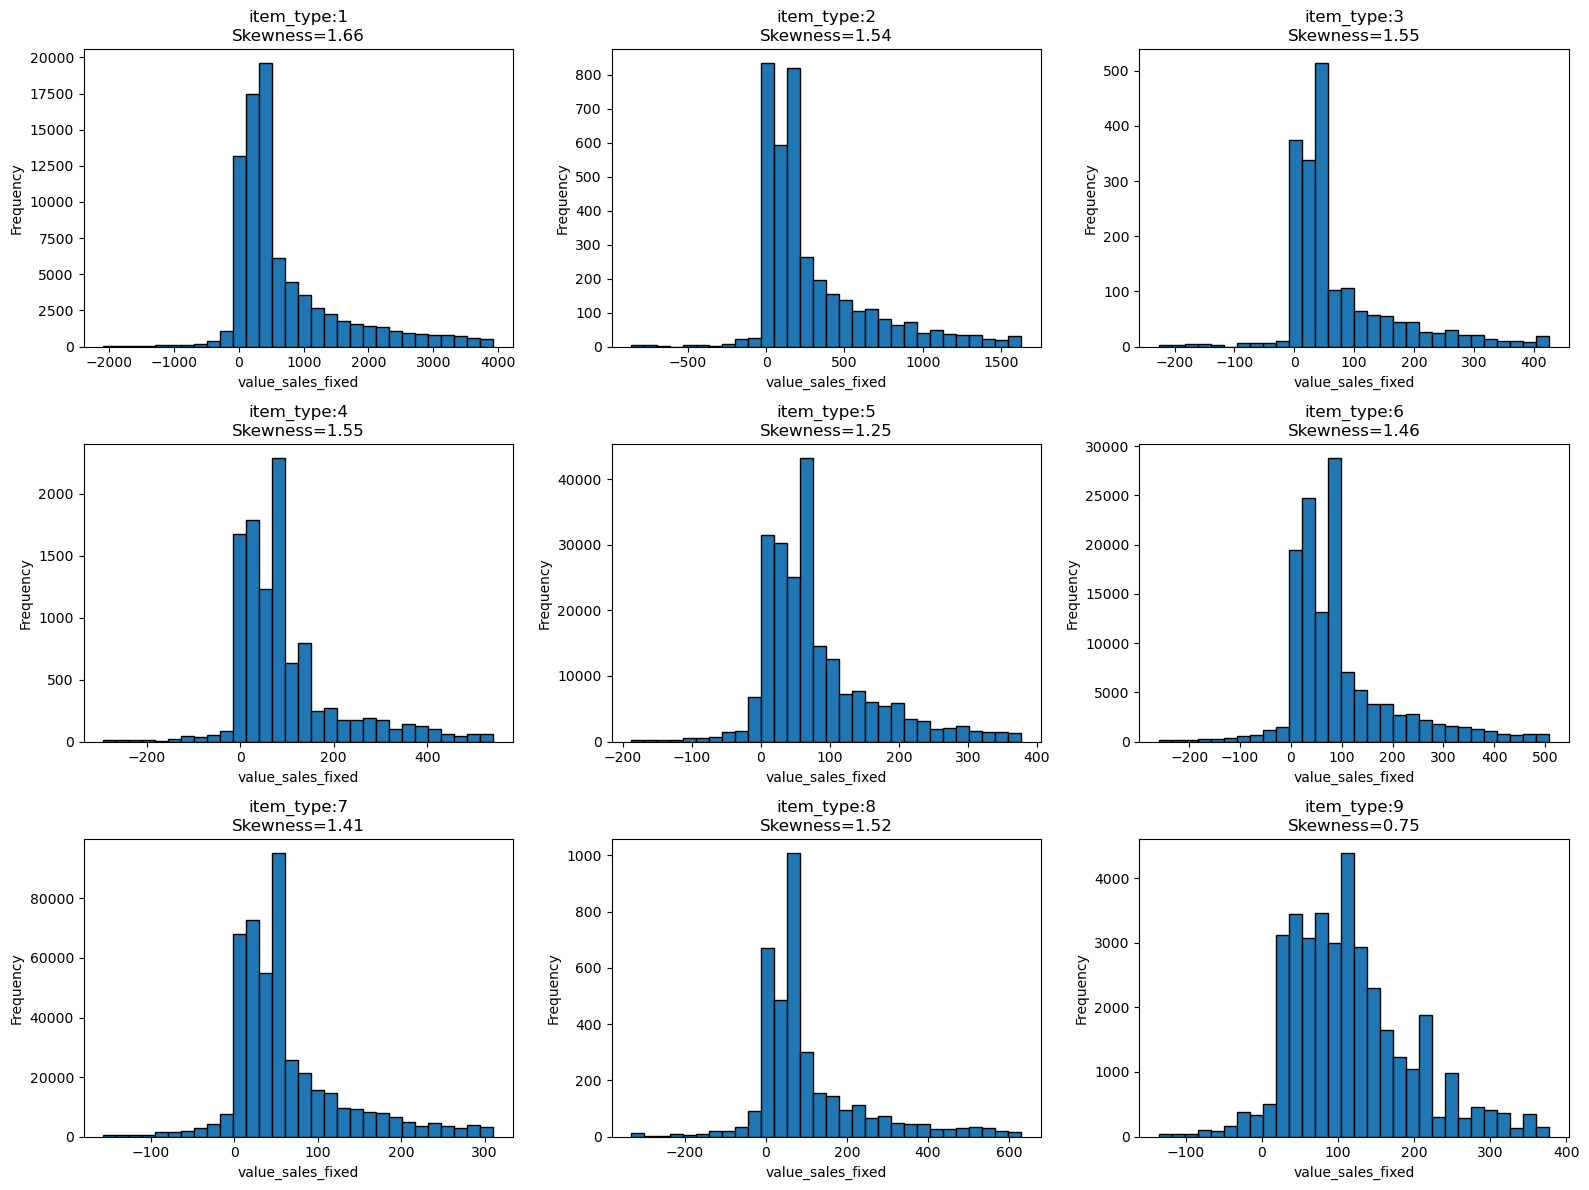

item_type
1    1.657195
2    1.539412
3    1.554306
4    1.551549
5    1.246041
6    1.464074
7    1.405848
8    1.522484
9    0.750221
Name: value_sales_fixed, dtype: float64


In [260]:
# visualization on skewness
cat, col = 'item_type','value_sales_fixed'
cats = sorted(df_2024[cat].unique())

nrows, ncols = 3,3
plt.figure(figsize=(16, 12))

for i,c in enumerate(cats[:nrows * ncols], 1):
    plt.subplot(nrows,ncols,i)
    data = df_2024.loc[df_2024[cat] == c, 'value_sales_fixed']
    skew_val = data.skew()
    plt.hist(data,bins=30,edgecolor='black')
    plt.title(f'{cat}:{c}\nSkewness={skew_val:.2f}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

# list out the skewness
skew_by_cat = df_2024.groupby(cat)[col].skew()
print(skew_by_cat)

##### Sign Log Transformation

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


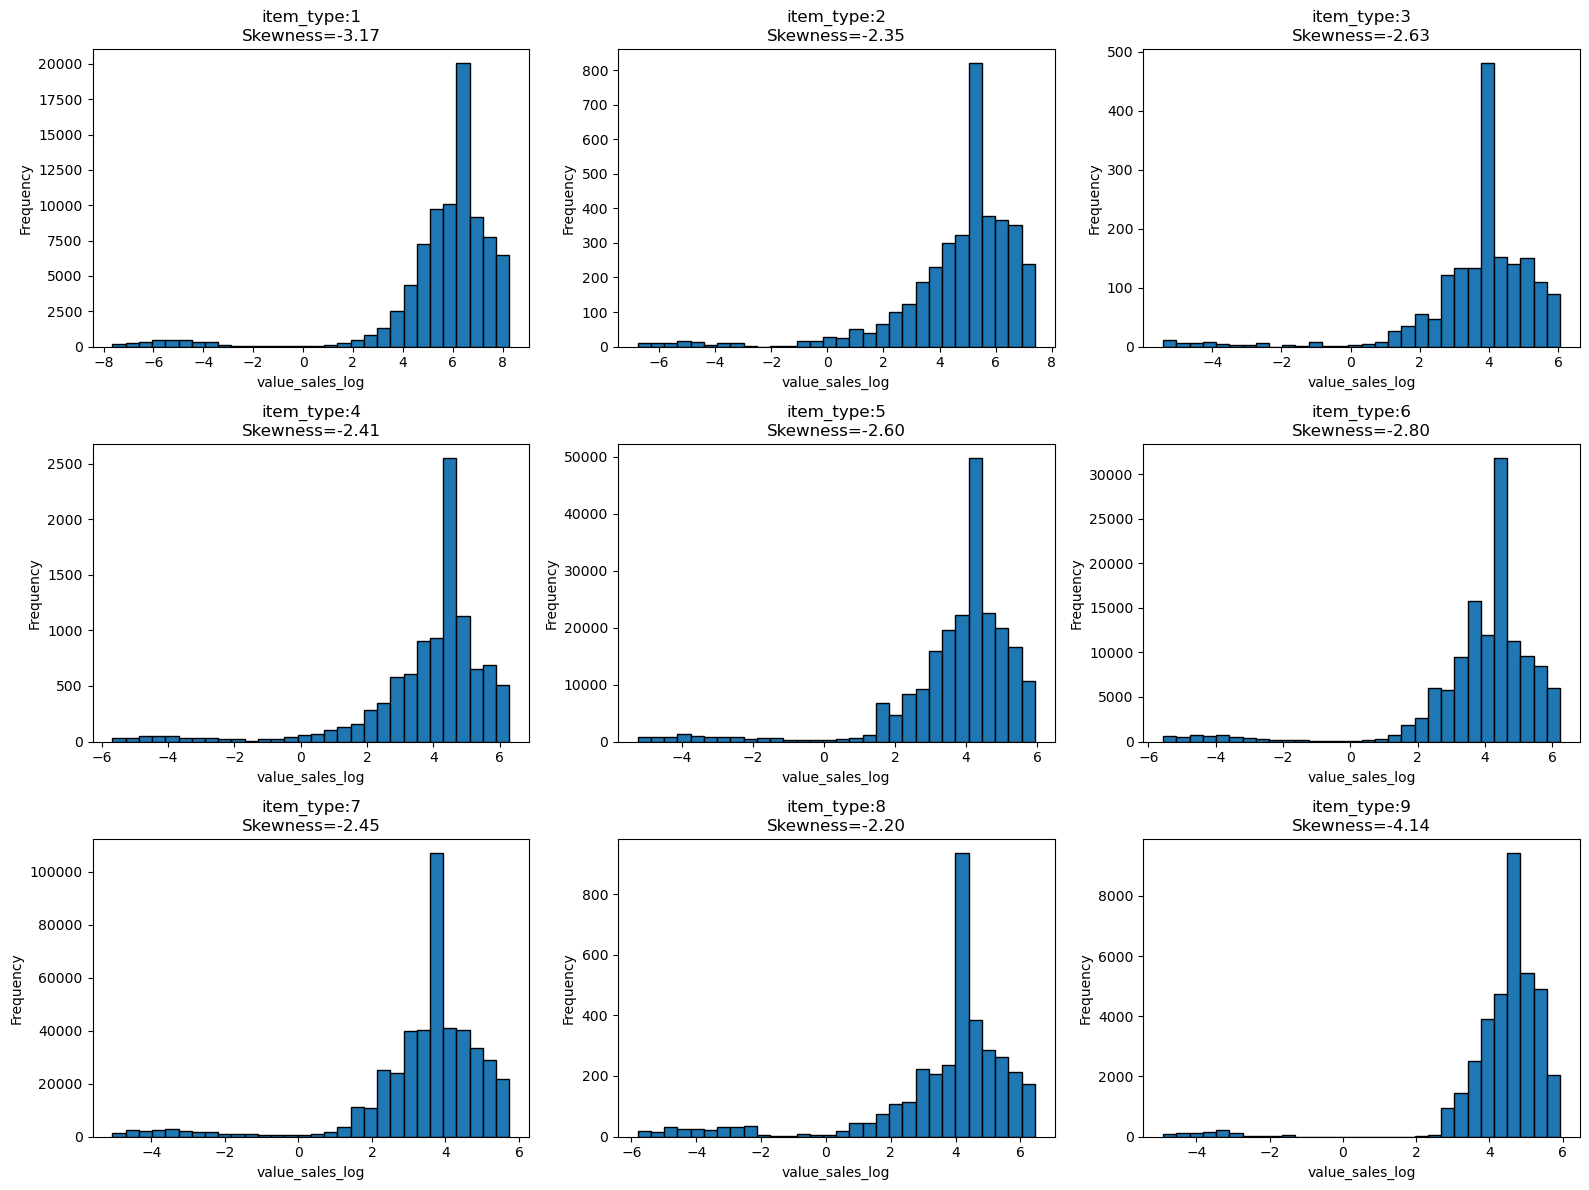

item_type
1   -3.168937
2   -2.350892
3   -2.631598
4   -2.406501
5   -2.598632
6   -2.801087
7   -2.447658
8   -2.198100
9   -4.143984
Name: value_sales_log, dtype: float64


In [262]:
# transform the value_sales_fixed
df_2024['value_sales_log'] = signed_log(df_2024['value_sales_fixed'])

# visualization on skewness
cat1, col1 = 'item_type','value_sales_log'
cats1 = sorted(df_2024[cat1].unique())

nrows, ncols = 3,3
plt.figure(figsize=(16, 12))

for i,c in enumerate(cats1[:nrows * ncols], 1):
    plt.subplot(nrows,ncols,i)
    data = df_2024.loc[df_2024[cat1] == c, 'value_sales_log']
    skew_val = data.skew()
    plt.hist(data,bins=30,edgecolor='black')
    plt.title(f'{cat1}:{c}\nSkewness={skew_val:.2f}')
    plt.xlabel(col1)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

# list out the skewness
skew_by_cat = df_2024.groupby(cat1)[col1].skew()
print(skew_by_cat)

##### Square Root

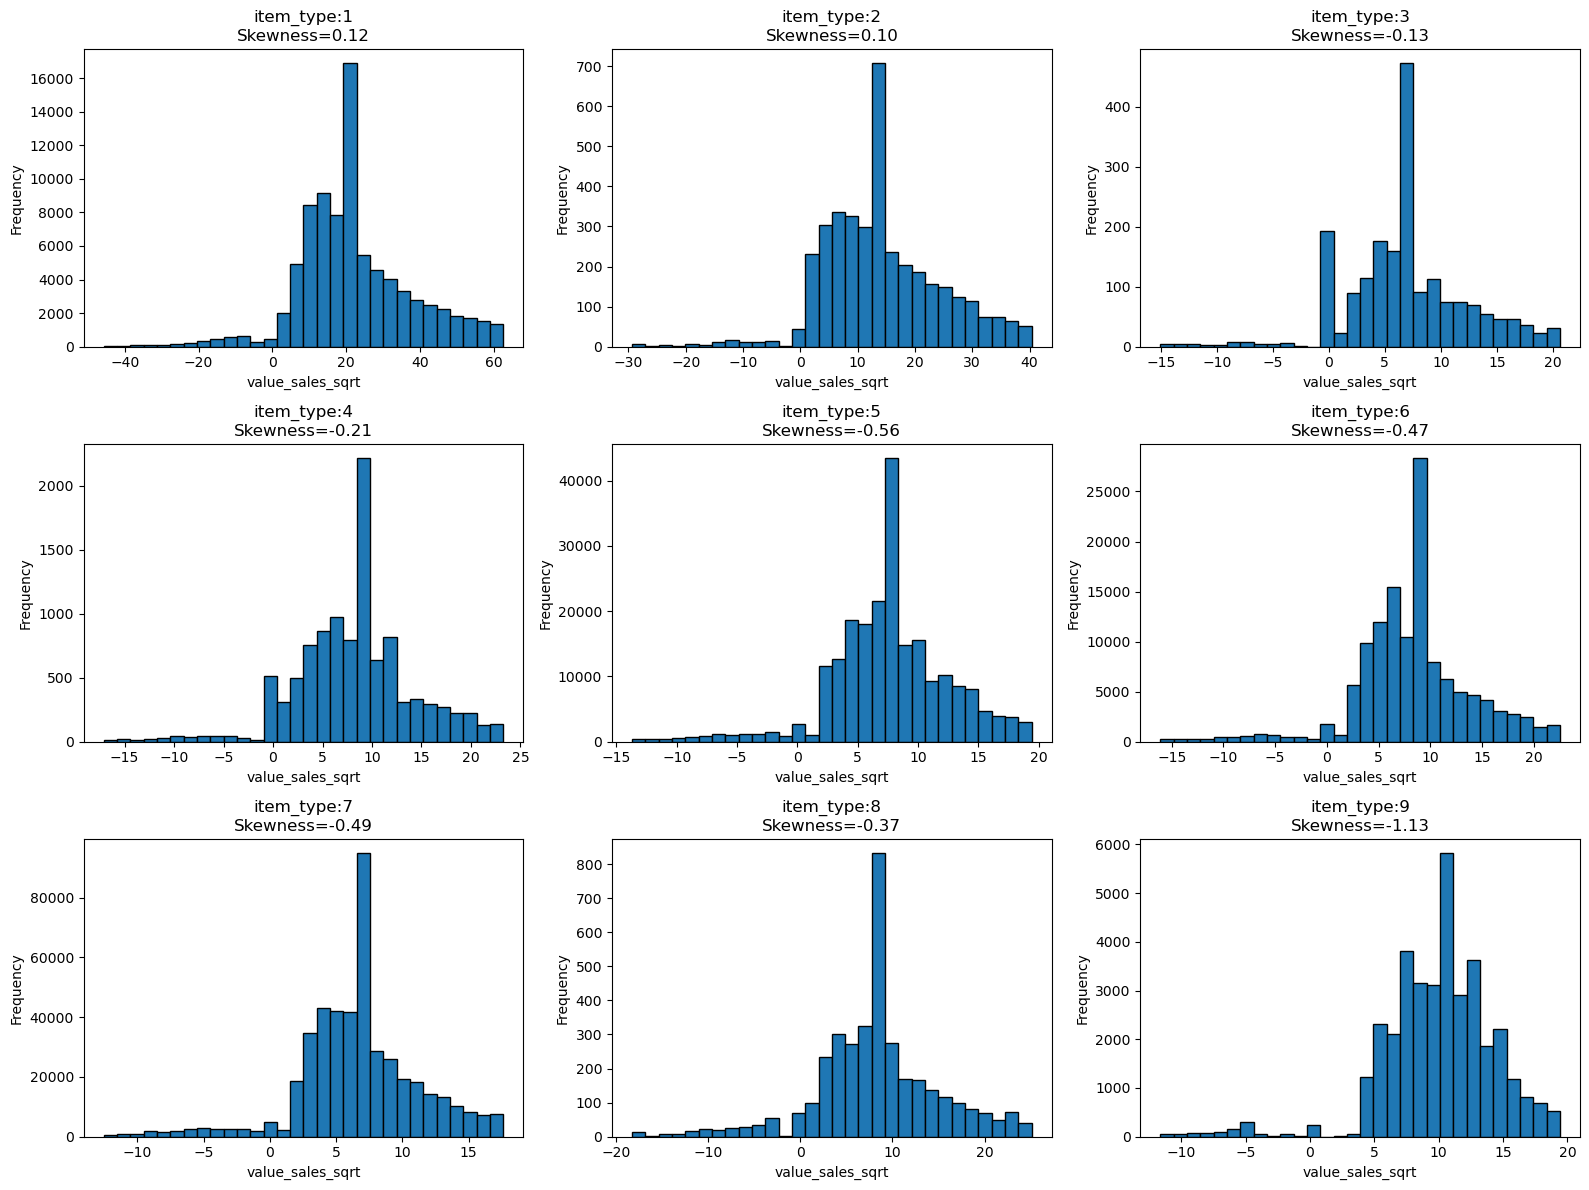

item_type
1    0.120345
2    0.098535
3   -0.125466
4   -0.209300
5   -0.562642
6   -0.471440
7   -0.490326
8   -0.371007
9   -1.132892
Name: value_sales_sqrt, dtype: float64


In [264]:
# transform the value_sales_fixed
df_2024['value_sales_sqrt'] = signed_sqrt(df_2024['value_sales_fixed'])

# visualization on skewness
cat2, col2 = 'item_type','value_sales_sqrt'
cats2 = sorted(df_2024[cat2].unique())

nrows, ncols = 3,3
plt.figure(figsize=(16, 12))

for i,c in enumerate(cats2[:nrows * ncols], 1):
    plt.subplot(nrows,ncols,i)
    data = df_2024.loc[df_2024[cat2] == c, 'value_sales_sqrt']
    skew_val = data.skew()
    plt.hist(data,bins=30,edgecolor='black')
    plt.title(f'{cat2}:{c}\nSkewness={skew_val:.2f}')
    plt.xlabel(col2)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# list out the skewness
skew_by_cat = df_2024.groupby(cat2)[col2].skew()
print(skew_by_cat)

##### Yeo-Johnson

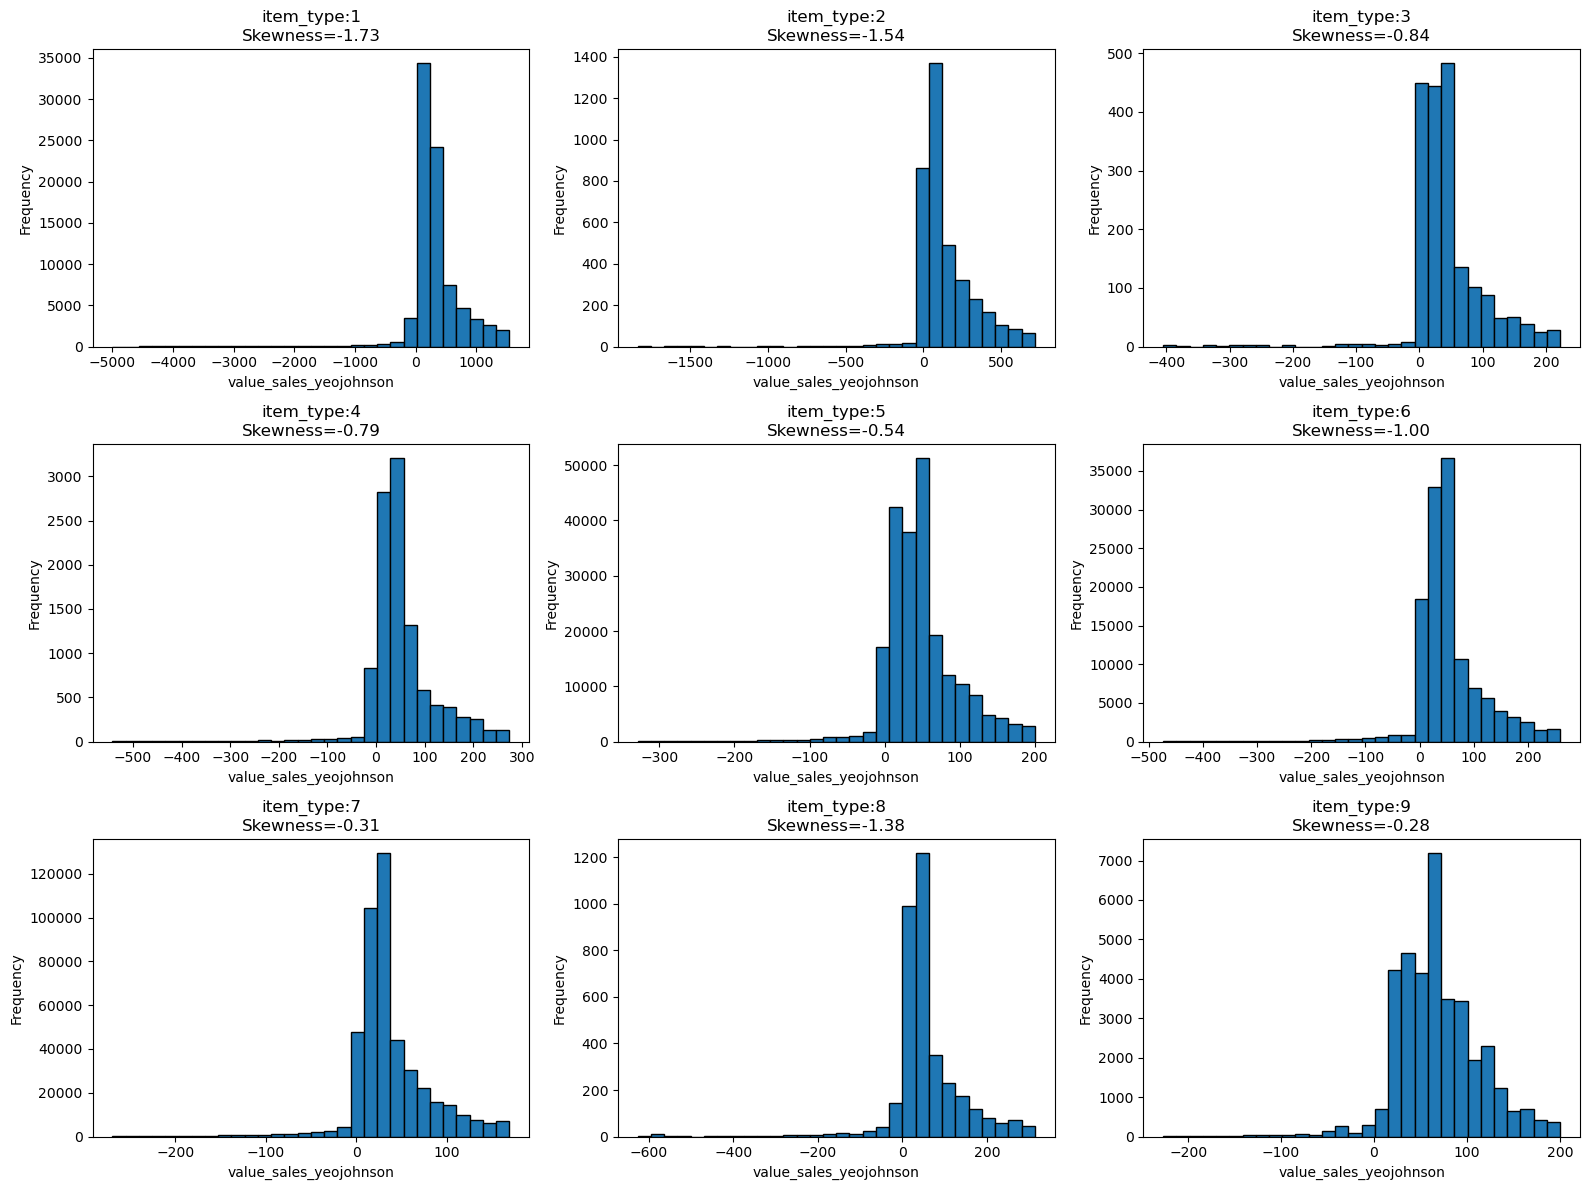

item_type
1   -1.729087
2   -1.540854
3   -0.844136
4   -0.788997
5   -0.542833
6   -0.999104
7   -0.312464
8   -1.376435
9   -0.278514
Name: value_sales_yeojohnson, dtype: float64


In [266]:
# transform the value_sales_fixed
df_2024['value_sales_yeojohnson'] = pt.fit_transform(df_2024[['value_sales_fixed']])

# visualization on skewness
cat3, col3 = 'item_type','value_sales_yeojohnson'
cats3 = sorted(df_2024[cat3].unique())

nrows, ncols = 3,3
plt.figure(figsize=(16, 12))

for i,c in enumerate(cats3[:nrows * ncols], 1):
    plt.subplot(nrows,ncols,i)
    data = df_2024.loc[df_2024[cat3] == c, 'value_sales_yeojohnson']
    skew_val = data.skew()
    plt.hist(data,bins=30,edgecolor='black')
    plt.title(f'{cat3}:{c}\nSkewness={skew_val:.2f}')
    plt.xlabel(col3)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

# list out the skewness
skew_by_cat = df_2024.groupby(cat3)[col3].skew()
print(skew_by_cat)

### Value_Cost (AUD) 2023

#### Visualization - outliers

##### Scatter Plot

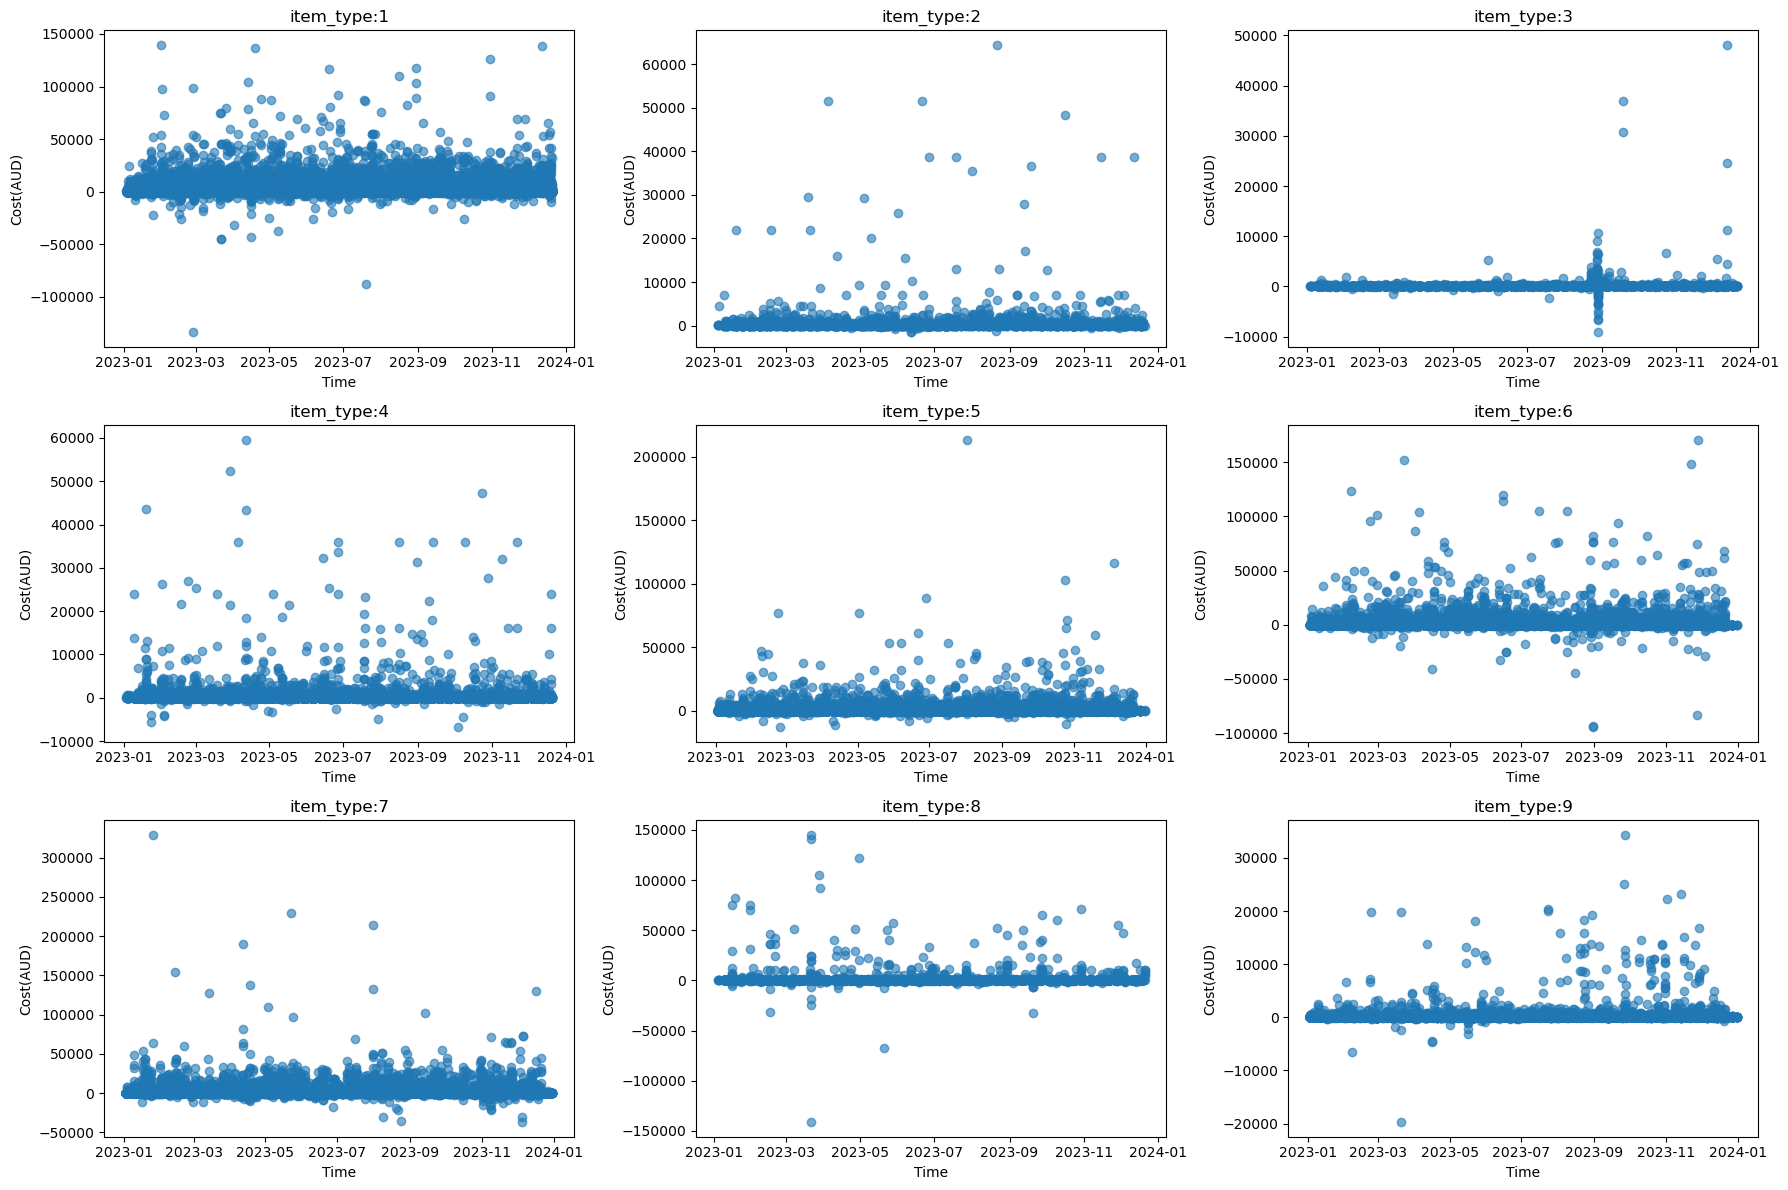

In [270]:
# to see the cost over time

cat, x, y = 'item_type','accounting_date','value_cost_aud'
cats = sorted(df_2023[cat].unique())
n = len(cats)

ncols = 3
nrows = -(-n // ncols)

plt.figure(figsize = (6 * ncols, 4 * nrows))

for i, c in enumerate(cats,1):
    subset = df_2023[df_2023[cat] == c]
    plt.subplot(nrows, ncols, i)
    plt.scatter(subset[x],subset[y],alpha = 0.6)
    plt.title(f"{cat}:{c}")
    plt.xlabel("Time")
    plt.ylabel("Cost(AUD)")
    
plt.tight_layout()
plt.show()

##### Boxplot

/var/folders/c6/xxws1v553296lnd2hthddtqh0000gn/T/ipykernel_26791/1591301435.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data ,labels = cats, showfliers=True, whis=1.5)


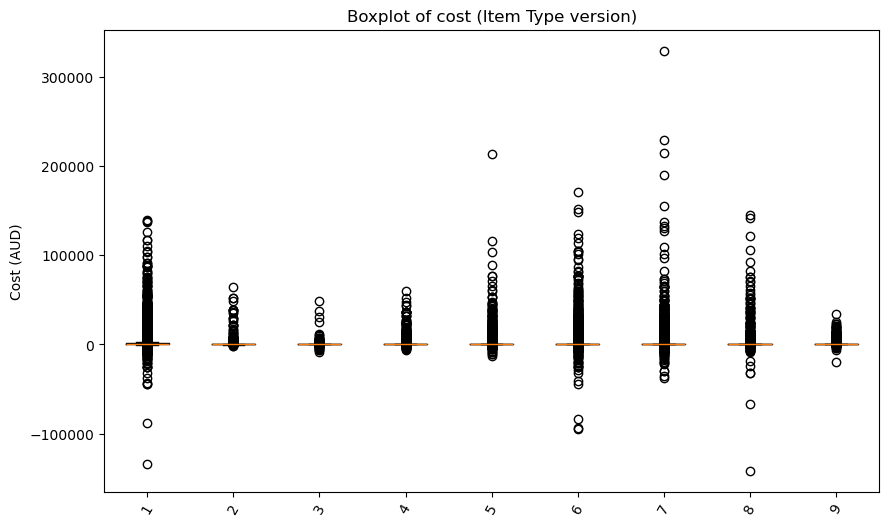

In [272]:
cat, val = 'item_type','value_cost_aud'
cats = sorted(df_2023[cat].unique())

data = [df_2023.loc[df_2023[cat].eq(c),val].values for c in cats]

plt.figure(figsize=(10,6))

plt.boxplot(data ,labels = cats, showfliers=True, whis=1.5)
plt.xticks(rotation=60)
plt.title('Boxplot of cost (Item Type version)')
plt.ylabel('Cost (AUD)')

plt.show()

#### Outlier Removal - IQR method

In [274]:
#caluclate 25th percentile of transformed sales
percentile25 = df_2023.groupby("item_type")['value_cost_aud'].quantile(0.25)
print('percentile25:')
print(percentile25)
print()
#caluclate 75th percentile of transformed sales
percentile75 = df_2023.groupby("item_type")['value_cost_aud'].quantile(0.75)
print('percentile75:')
print(percentile75)
print()
#calculate the IQR
iqr = percentile75 - percentile25
print('IQR:')
print(iqr)
print()
#locate the limitation range 
upper_limit = percentile75 + 1.5 * iqr
lower_limit = percentile25 - 1.5 * iqr

print('upper limit:')
print(upper_limit)
print()
print('lower limit:')
print(lower_limit)

# save these values in new columns for further adjustemnts
df_2023["percentile25"] = df_2023['item_type'].map(percentile25)
df_2023["percentile75"] = df_2023['item_type'].map(percentile75)
df_2023["lower end"] = df_2023['item_type'].map(lower_limit)
df_2023["upper end"] = df_2023['item_type'].map(upper_limit)

percentile25:
item_type
1    89.08000
2    27.35150
3    12.57645
4    12.18000
5    11.85320
6    15.00000
7     6.43400
8     6.38000
9    31.46360
Name: value_cost_aud, dtype: float64

percentile75:
item_type
1    982.3476
2    325.2960
3     93.6000
4    107.7090
5     89.3400
6    127.0983
7     54.7384
8    135.0000
9    102.6006
Name: value_cost_aud, dtype: float64

IQR:
item_type
1    893.26760
2    297.94450
3     81.02355
4     95.52900
5     77.48680
6    112.09830
7     48.30440
8    128.62000
9     71.13700
Name: value_cost_aud, dtype: float64

upper limit:
item_type
1    2322.249000
2     772.212750
3     215.135325
4     251.002500
5     205.570200
6     295.245750
7     127.195000
8     327.930000
9     209.306100
Name: value_cost_aud, dtype: float64

lower limit:
item_type
1   -1250.821400
2    -419.565250
3    -108.958875
4    -131.113500
5    -104.377000
6    -153.147450
7     -66.022600
8    -186.550000
9     -75.241900
Name: value_cost_aud, dtype: float64


In [275]:
#isolate outliers on low end by group
sales_lower = df_2023[df_2023['value_cost_aud'] < df_2023['item_type'].map(lower_limit)]
#isolate outliers on upper end by group
sales_upper = df_2023[df_2023['value_cost_aud'] > df_2023['item_type'].map(upper_limit)]
#locate the medium sales for each type
median_sales = df_2023.groupby('item_type')['value_cost_aud'].median()
# create a new column to save the median value for each categories
df_2023["median_cost"] = df_2023.groupby("item_type")["value_cost_aud"].transform("median")
# create other columns to save the transformed replaced value 
df_2023['cost outlier'] = ~df_2023["value_cost_aud"].between(df_2023['lower end'], df_2023['upper end'], inclusive='both')
df_2023['value_cost_fixed'] = df_2023['value_cost_aud'].mask(df_2023['cost outlier'],df_2023['median_cost'])
df_2023[['item_type','value_cost_aud','median_cost','cost outlier', 'value_cost_fixed']]

,item_type,value_cost_aud,median_cost,cost outlier,value_cost_fixed
9,5,-4.2428,31.8002,False,-4.2428
10,5,12.7284,31.8002,False,12.7284
11,5,292.7532,31.8002,True,31.8002
13,5,152.7408,31.8002,False,152.7408
14,5,12.7284,31.8002,False,12.7284
...,...,...,...,...,...
1037200,5,12.7284,31.8002,False,12.7284
1037201,5,25.4568,31.8002,False,25.4568
1037202,5,12.7284,31.8002,False,12.7284
1037203,5,38.1852,31.8002,False,38.1852


/var/folders/c6/xxws1v553296lnd2hthddtqh0000gn/T/ipykernel_26791/1429035301.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_bf ,labels = order, vert=False, showfliers=True, whis=1.5)
/var/folders/c6/xxws1v553296lnd2hthddtqh0000gn/T/ipykernel_26791/1429035301.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_af ,labels = order, vert=False, showfliers=True, whis=1.5)


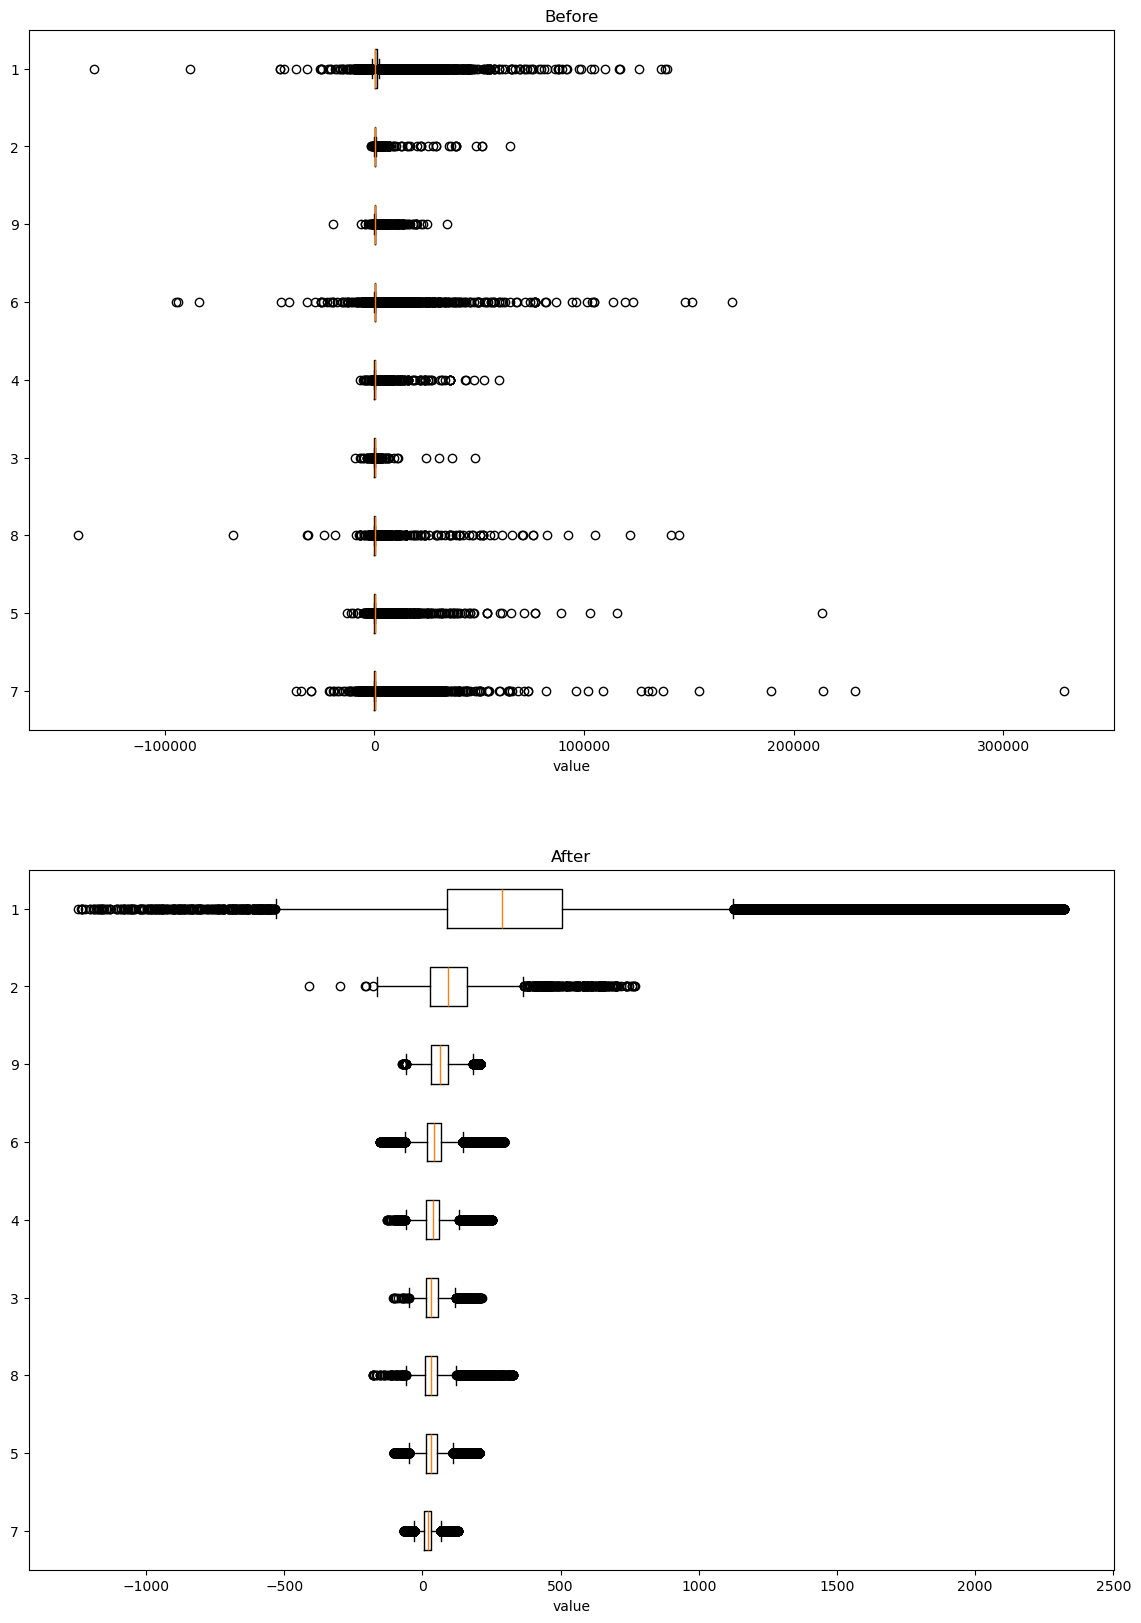

In [276]:
# review the result of outlier fixing  

#boxplot
cat, before, after = 'item_type', 'value_cost_aud', 'value_cost_fixed'

order = (df_2023.groupby(cat)[before].median().sort_values().index)

data_bf = [df_2023.loc[df_2023[cat].eq(c),before].values for c in order]
data_af = [df_2023.loc[df_2023[cat].eq(c),after].values for c in order]

plt.figure(figsize=(14, 20))

plt.subplot(2,1,1)
plt.boxplot(data_bf ,labels = order, vert=False, showfliers=True, whis=1.5)
plt.title ('Before')
plt.xlabel('value')

plt.subplot(2,1,2)
plt.boxplot(data_af ,labels = order, vert=False, showfliers=True, whis=1.5)
plt.title ('After')
plt.xlabel('value')


plt.show()

#### Transformation

##### Histogram

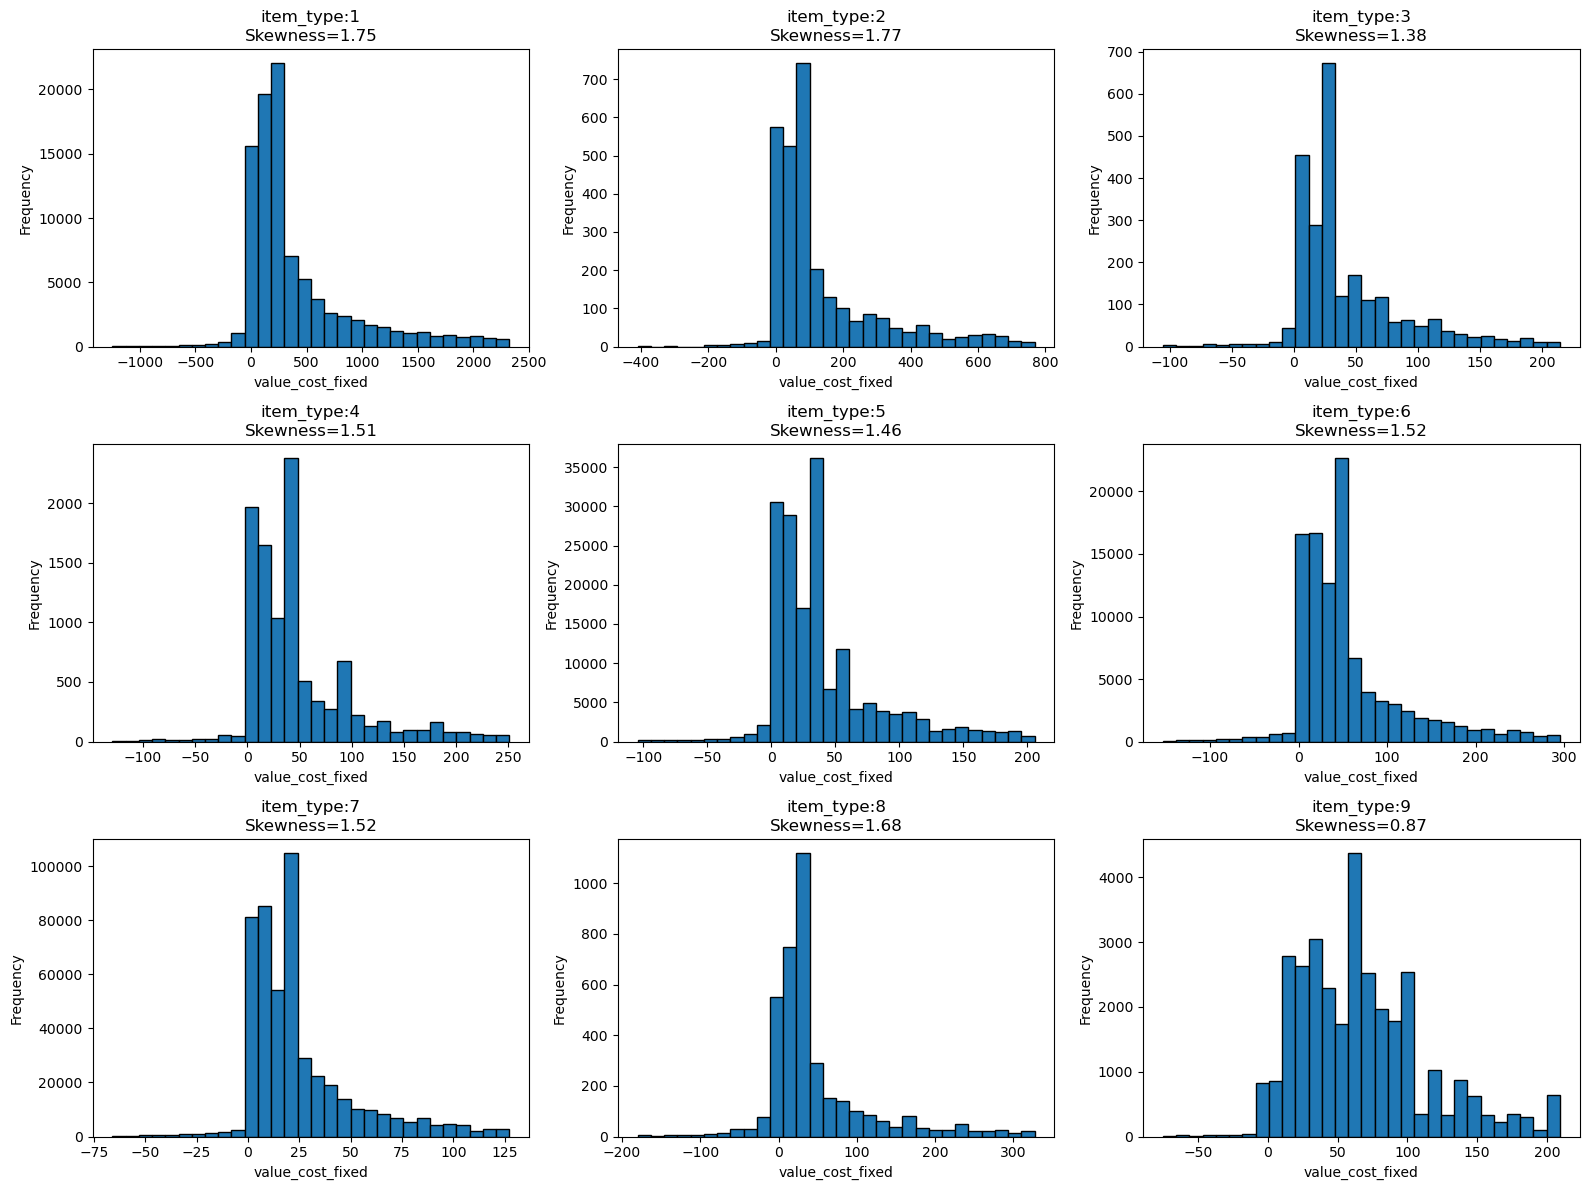

item_type
1    1.752515
2    1.773021
3    1.378761
4    1.507239
5    1.463956
6    1.516469
7    1.521155
8    1.679846
9    0.872561
Name: value_cost_fixed, dtype: float64


In [279]:
# visualization on skewness
cat, col = 'item_type','value_cost_fixed'
cats = sorted(df_2023[cat].unique())

nrows, ncols = 3,3
plt.figure(figsize=(16, 12))

for i,c in enumerate(cats[:nrows * ncols], 1):
    plt.subplot(nrows,ncols,i)
    data = df_2023.loc[df_2023[cat] == c, 'value_cost_fixed']
    skew_val = data.skew()
    plt.hist(data,bins=30,edgecolor='black')
    plt.title(f'{cat}:{c}\nSkewness={skew_val:.2f}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

# list out the skewness
skew_by_cat = df_2023.groupby(cat)[col].skew()
print(skew_by_cat)

##### Signed Log Transformation

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


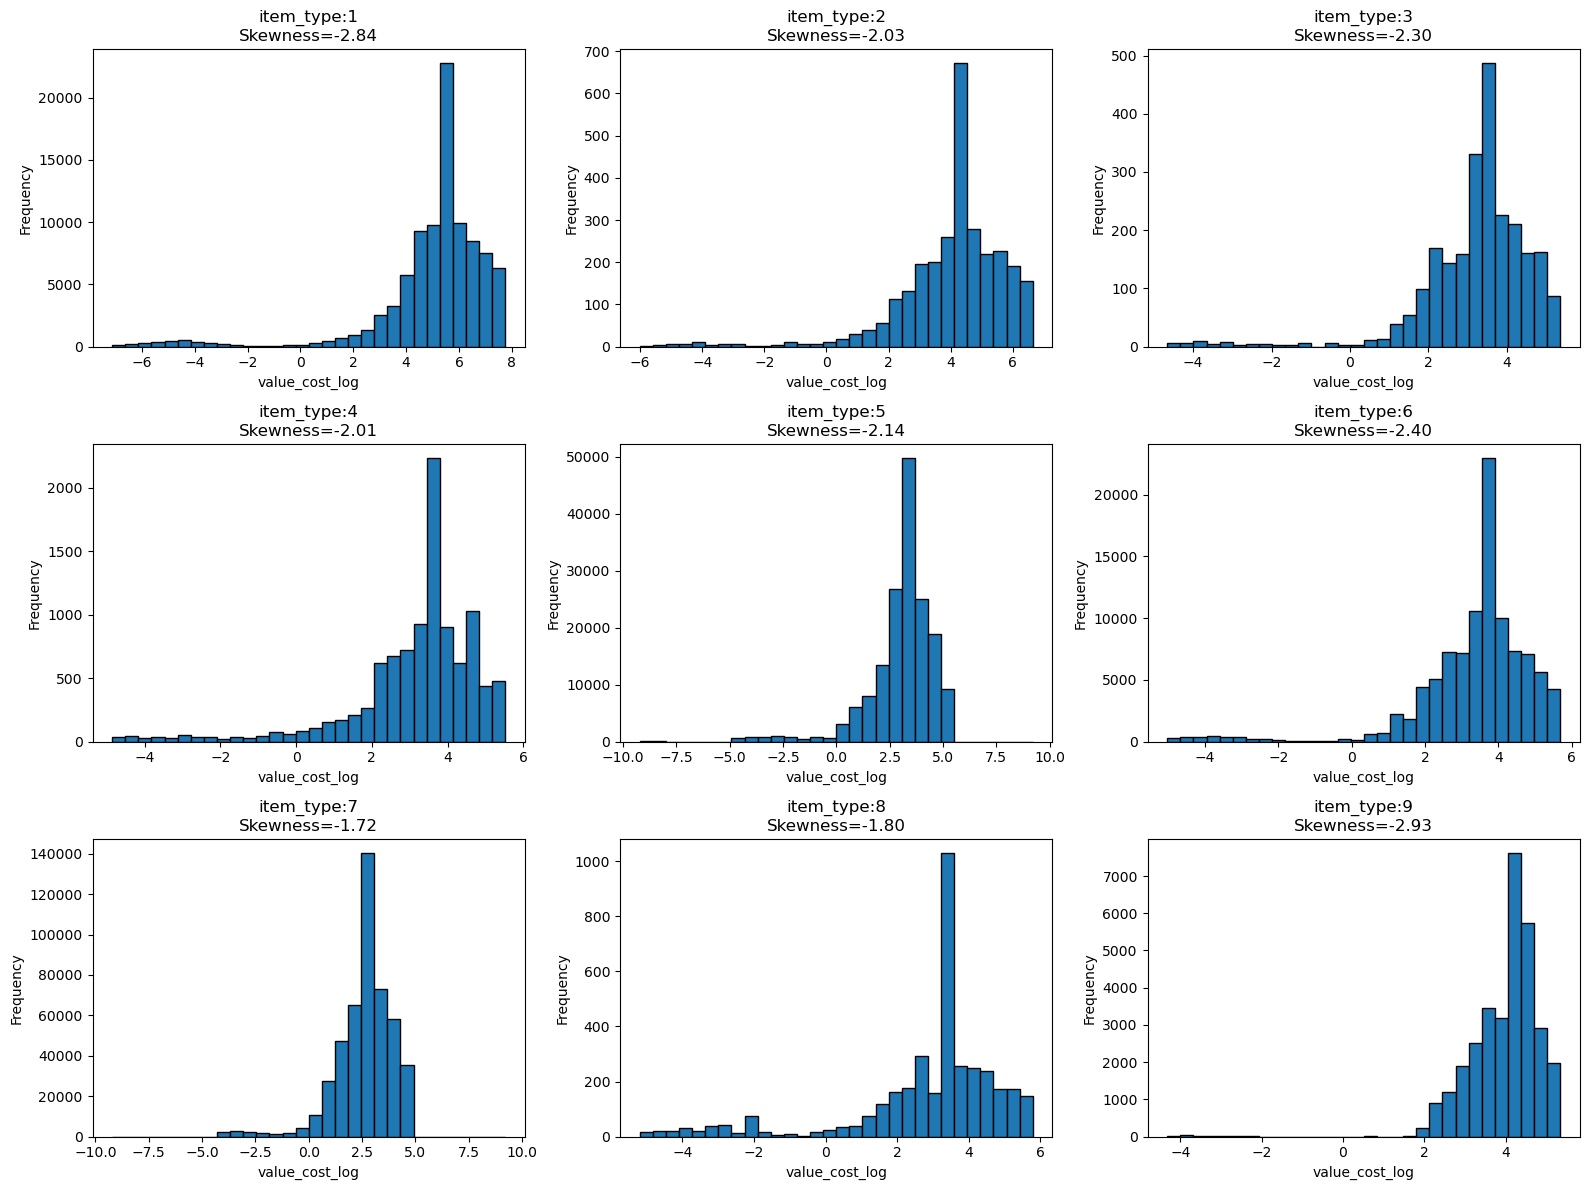

item_type
1   -2.839774
2   -2.028289
3   -2.304418
4   -2.011349
5   -2.141536
6   -2.399065
7   -1.719177
8   -1.801783
9   -2.932240
Name: value_cost_log, dtype: float64


In [281]:
# signed log transforming
df_2023['value_cost_log'] = signed_log(df_2023['value_cost_fixed'])

# visualization on skewness
cat1, col1 = 'item_type','value_cost_log'
cats1 = sorted(df_2023[cat1].unique())

nrows, ncols = 3,3
plt.figure(figsize=(16, 12))

for i,c in enumerate(cats1[:nrows * ncols], 1):
    plt.subplot(nrows,ncols,i)
    data = df_2023.loc[df_2023[cat1] == c, 'value_cost_log']
    skew_val = data.skew()
    plt.hist(data,bins=30,edgecolor='black')
    plt.title(f'{cat1}:{c}\nSkewness={skew_val:.2f}')
    plt.xlabel(col1)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

# list the skewness
skew_by_cat = df_2023.groupby(cat1)[col1].skew()
print(skew_by_cat)

##### Square Root

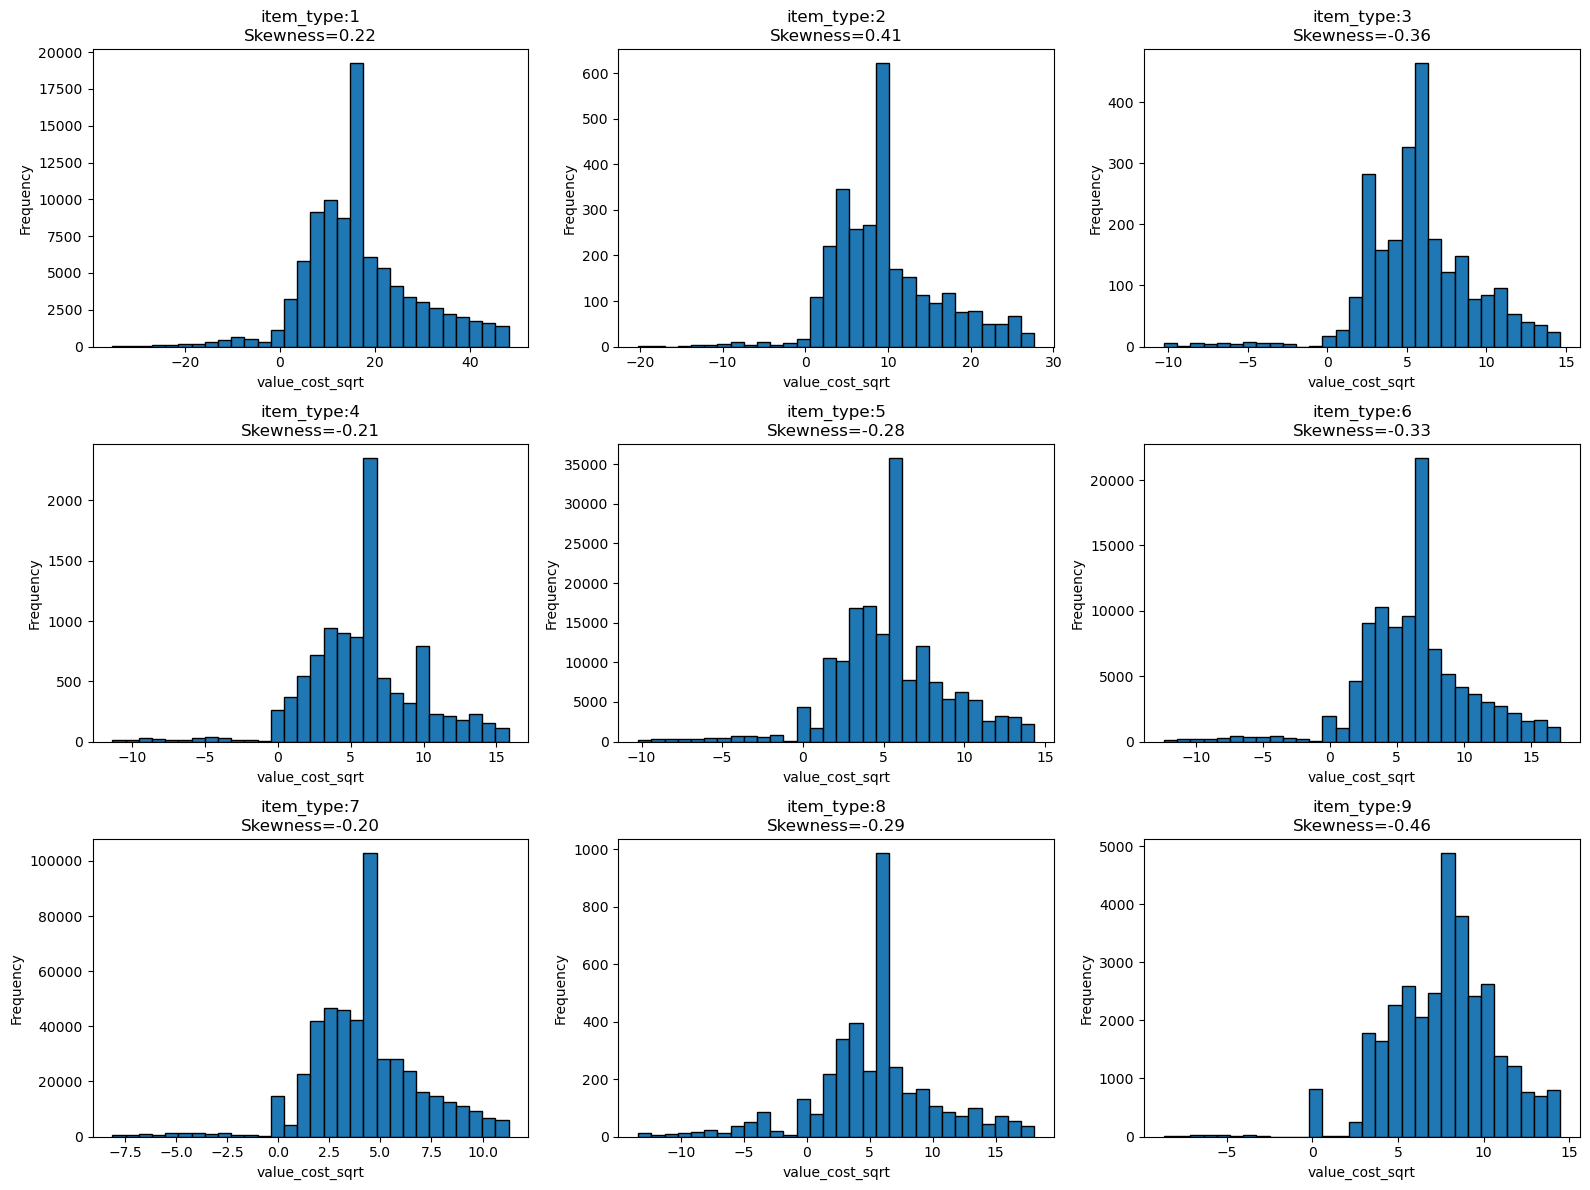

item_type
1    0.219665
2    0.411020
3   -0.359707
4   -0.213665
5   -0.279048
6   -0.327544
7   -0.198407
8   -0.290000
9   -0.456919
Name: value_cost_sqrt, dtype: float64


In [283]:
# transforming by square root
df_2023['value_cost_sqrt'] = signed_sqrt(df_2023['value_cost_fixed'])

# visualization on skewness
cat2, col2 = 'item_type','value_cost_sqrt'
cats2 = sorted(df_2023[cat2].unique())

nrows, ncols = 3,3
plt.figure(figsize=(16, 12))

for i,c in enumerate(cats2[:nrows * ncols], 1):
    plt.subplot(nrows,ncols,i)
    data = df_2023.loc[df_2023[cat2] == c, 'value_cost_sqrt']
    skew_val = data.skew()
    plt.hist(data,bins=30,edgecolor='black')
    plt.title(f'{cat2}:{c}\nSkewness={skew_val:.2f}')
    plt.xlabel(col2)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

# list the skewness
skew_by_cat = df_2023.groupby(cat2)[col2].skew()
print(skew_by_cat)

##### Yeo-Johnson 

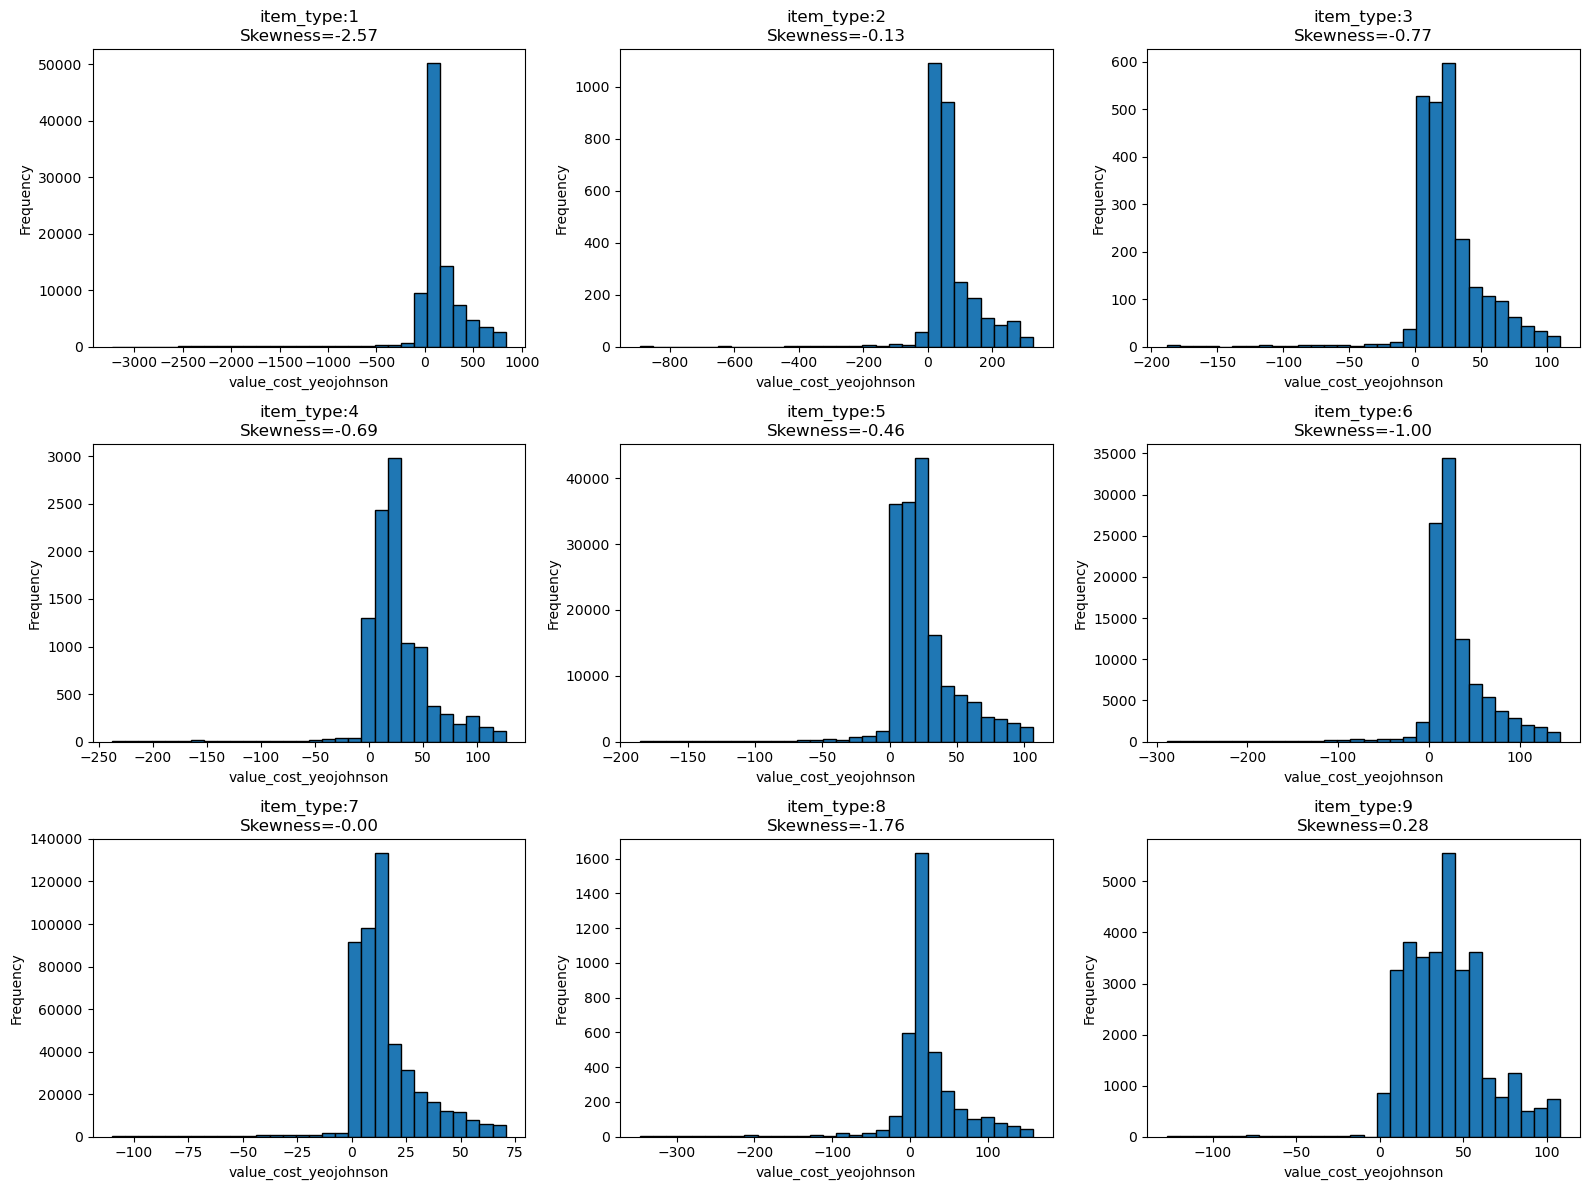

item_type
1   -2.569592
2   -0.126752
3   -0.771097
4   -0.685829
5   -0.460617
6   -0.996743
7   -0.001629
8   -1.759120
9    0.282090
Name: value_cost_yeojohnson, dtype: float64


In [285]:
df_2023['value_cost_yeojohnson'] = pt.fit_transform(df_2023[['value_cost_fixed']])

# visualization on skewness
cat3, col3 = 'item_type','value_cost_yeojohnson'
cats3 = sorted(df_2023[cat3].unique())

nrows, ncols = 3,3
plt.figure(figsize=(16, 12))

for i,c in enumerate(cats3[:nrows * ncols], 1):
    plt.subplot(nrows,ncols,i)
    data = df_2023.loc[df_2023[cat3] == c, 'value_cost_yeojohnson']
    skew_val = data.skew()
    plt.hist(data,bins=30,edgecolor='black')
    plt.title(f'{cat3}:{c}\nSkewness={skew_val:.2f}')
    plt.xlabel(col3)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

# list skewness
skew_by_cat = df_2023.groupby(cat3)[col3].skew()
print(skew_by_cat)

### Value_Cost (AUD) 2024

#### Visualization - outliers

##### Scatter Plot

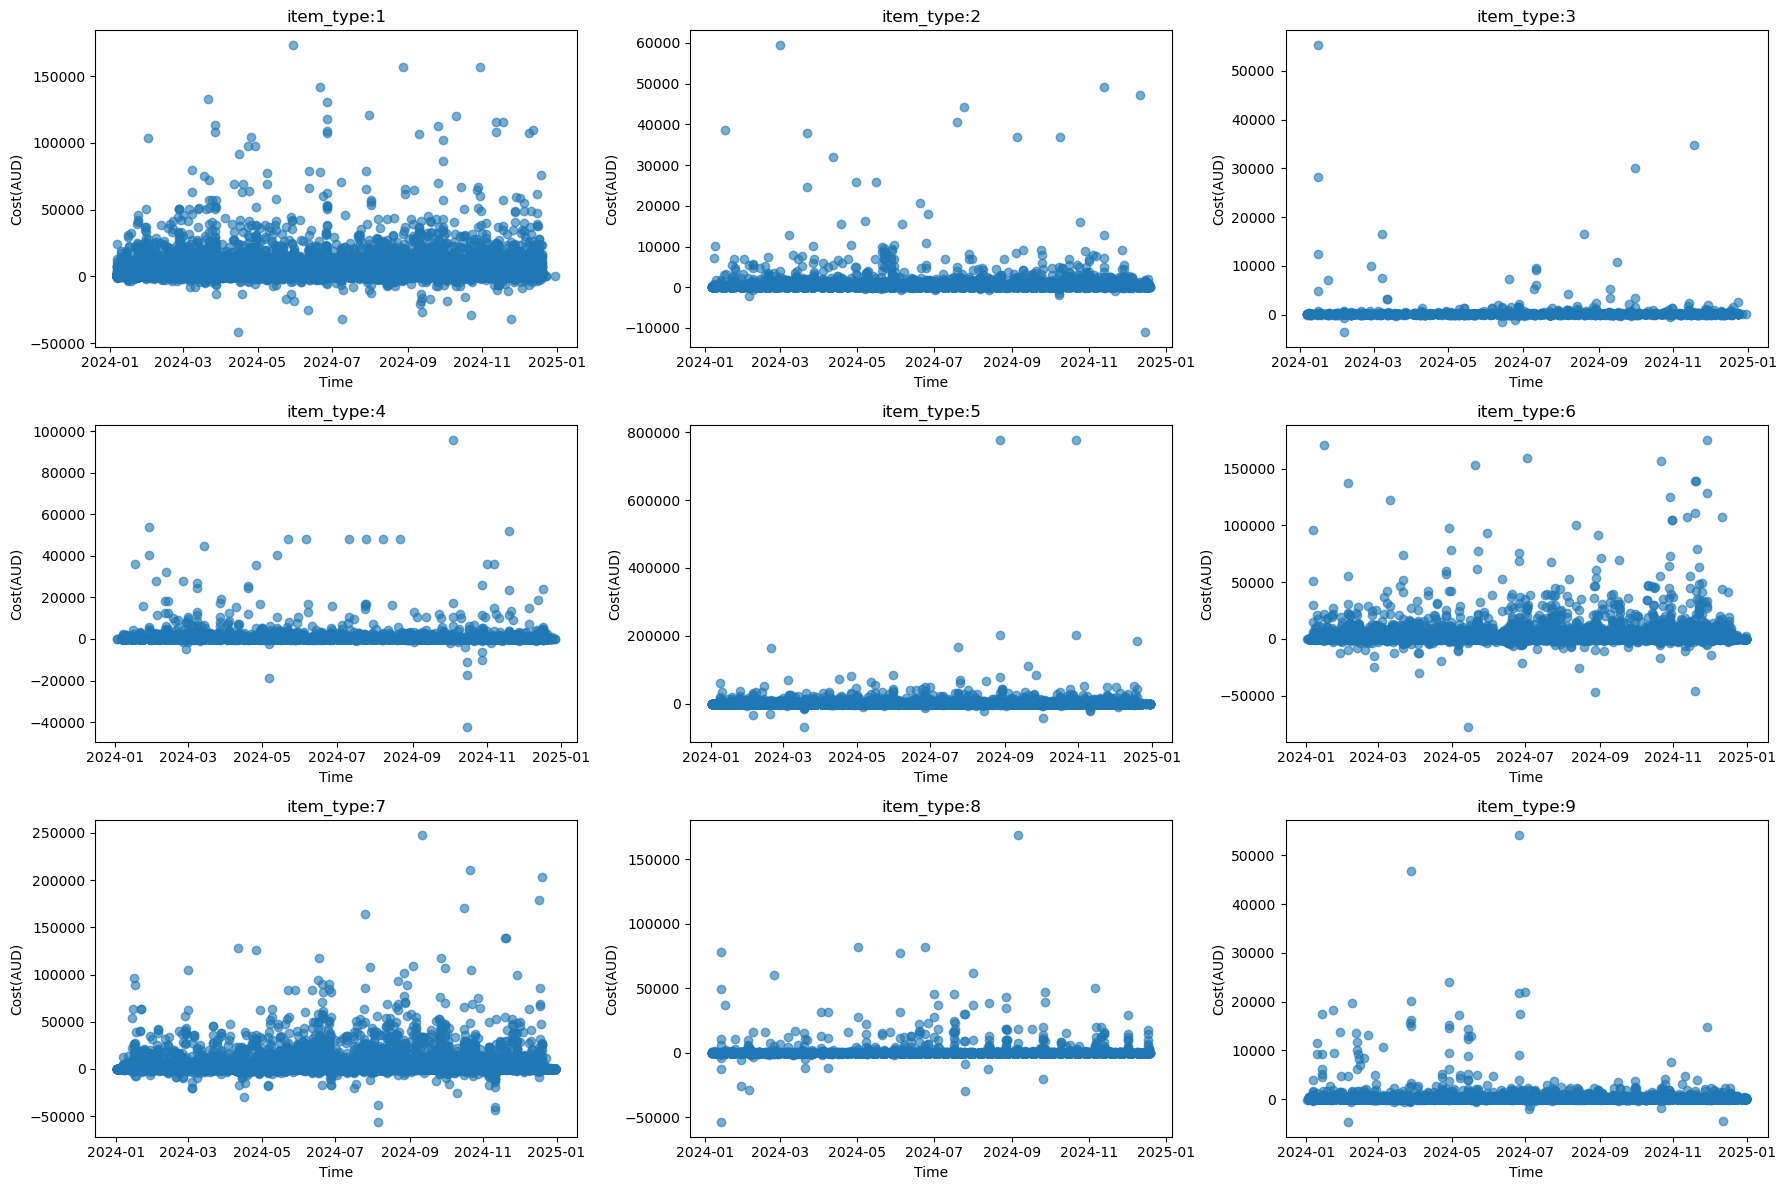

In [289]:
# to see the cost over time

cat, x, y = 'item_type','accounting_date','value_cost_aud'
cats = sorted(df_2024[cat].unique())
n = len(cats)

ncols = 3
nrows = -(-n // ncols)

plt.figure(figsize = (6 * ncols, 4 * nrows))

for i, c in enumerate(cats,1):
    subset = df_2024[df_2024[cat] == c]
    plt.subplot(nrows, ncols, i)
    plt.scatter(subset[x],subset[y],alpha = 0.6)
    plt.title(f"{cat}:{c}")
    plt.xlabel("Time")
    plt.ylabel("Cost(AUD)")
    
plt.tight_layout()
plt.show()

##### Boxplot

/var/folders/c6/xxws1v553296lnd2hthddtqh0000gn/T/ipykernel_26791/2655388171.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data ,labels = cats, showfliers=True, whis=1.5)


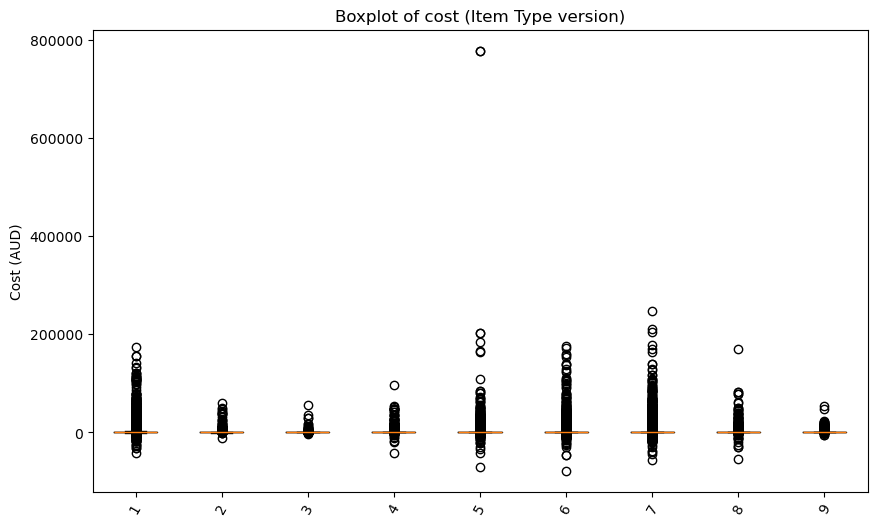

In [291]:
cat, val = 'item_type','value_cost_aud'
cats = sorted(df_2024[cat].unique())

data = [df_2024.loc[df_2024[cat].eq(c),val].values for c in cats]

plt.figure(figsize=(10,6))

plt.boxplot(data ,labels = cats, showfliers=True, whis=1.5)
plt.xticks(rotation=60)
plt.title('Boxplot of cost (Item Type version)')
plt.ylabel('Cost (AUD)')

plt.show()

#### Outlier Removal - IQR method

In [293]:
#caluclate 25th percentile of transformed sales
percentile25 = df_2024.groupby("item_type")['value_cost_aud'].quantile(0.25)
print('percentile25:')
print(percentile25)
print()
#caluclate 75th percentile of transformed sales
percentile75 = df_2024.groupby("item_type")['value_cost_aud'].quantile(0.75)
print('percentile75:')
print(percentile75)
print()
#calculate the IQR
iqr = percentile75 - percentile25
print('IQR:')
print(iqr)
print()
#locate the limitation range 
upper_limit = percentile75 + 1.5 * iqr
lower_limit = percentile25 - 1.5 * iqr

print('upper limit:')
print(upper_limit)
print()
print('lower limit:')
print(lower_limit)

# save these values in new columns for further adjustemnts
df_2024["percentile25"] = df_2024['item_type'].map(percentile25)
df_2024["percentile75"] = df_2024['item_type'].map(percentile75)
df_2024["lower end"] = df_2024['item_type'].map(lower_limit)
df_2024["upper end"] = df_2024['item_type'].map(upper_limit)

percentile25:
item_type
1    93.160000
2    32.687000
3    12.300000
4    12.300000
5    12.180000
6    13.232354
7     5.906000
8     9.120000
9    29.527500
Name: value_cost_aud, dtype: float64

percentile75:
item_type
1    1068.02295
2     607.30000
3     112.95000
4     129.30000
5      88.77000
6     114.85600
7      61.08650
8     132.22800
9      94.94640
Name: value_cost_aud, dtype: float64

IQR:
item_type
1    974.862950
2    574.613000
3    100.650000
4    117.000000
5     76.590000
6    101.623646
7     55.180500
8    123.108000
9     65.418900
Name: value_cost_aud, dtype: float64

upper limit:
item_type
1    2530.317375
2    1469.219500
3     263.925000
4     304.800000
5     203.655000
6     267.291469
7     143.857250
8     316.890000
9     193.074750
Name: value_cost_aud, dtype: float64

lower limit:
item_type
1   -1369.134425
2    -829.232500
3    -138.675000
4    -163.200000
5    -102.705000
6    -139.203115
7     -76.864750
8    -175.542000
9     -68.600850
Name: valu

In [294]:
#isolate outliers on low end by group
sales_lower = df_2024[df_2024['value_cost_aud'] < df_2024['item_type'].map(lower_limit)]
#isolate outliers on upper end by group
sales_upper = df_2024[df_2024['value_cost_aud'] > df_2024['item_type'].map(upper_limit)]
#locate the medium sales for each type
median_sales = df_2024.groupby('item_type')['value_cost_aud'].median()
# create a new column to save the median value for each categories
df_2024["median_cost"] = df_2024.groupby("item_type")["value_cost_aud"].transform("median")
# create other columns to save the transformed replaced value 
df_2024['cost outlier'] = ~df_2024["value_cost_aud"].between(df_2024['lower end'], df_2024['upper end'], inclusive='both')
df_2024['value_cost_fixed'] = df_2024['value_cost_aud'].mask(df_2024['cost outlier'],df_2024['median_cost'])
df_2024[['item_type','value_cost_aud','median_cost','cost outlier', 'value_cost_fixed']]

,item_type,value_cost_aud,median_cost,cost outlier,value_cost_fixed
5,5,14.0700,35.335600,False,14.0700
6,5,4.6900,35.335600,False,4.6900
28,5,44.7015,35.335600,False,44.7015
29,5,7.8190,35.335600,False,7.8190
30,5,7.8190,35.335600,False,7.8190
...,...,...,...,...,...
951172,5,105.5600,35.335600,False,105.5600
951173,1,681.4500,303.680000,False,681.4500
951174,6,58.7915,33.701284,False,58.7915
951175,5,13.1950,35.335600,False,13.1950


/var/folders/c6/xxws1v553296lnd2hthddtqh0000gn/T/ipykernel_26791/3050659237.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_bf ,labels = order, vert=False, showfliers=True, whis=1.5)
/var/folders/c6/xxws1v553296lnd2hthddtqh0000gn/T/ipykernel_26791/3050659237.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_af ,labels = order, vert=False, showfliers=True, whis=1.5)


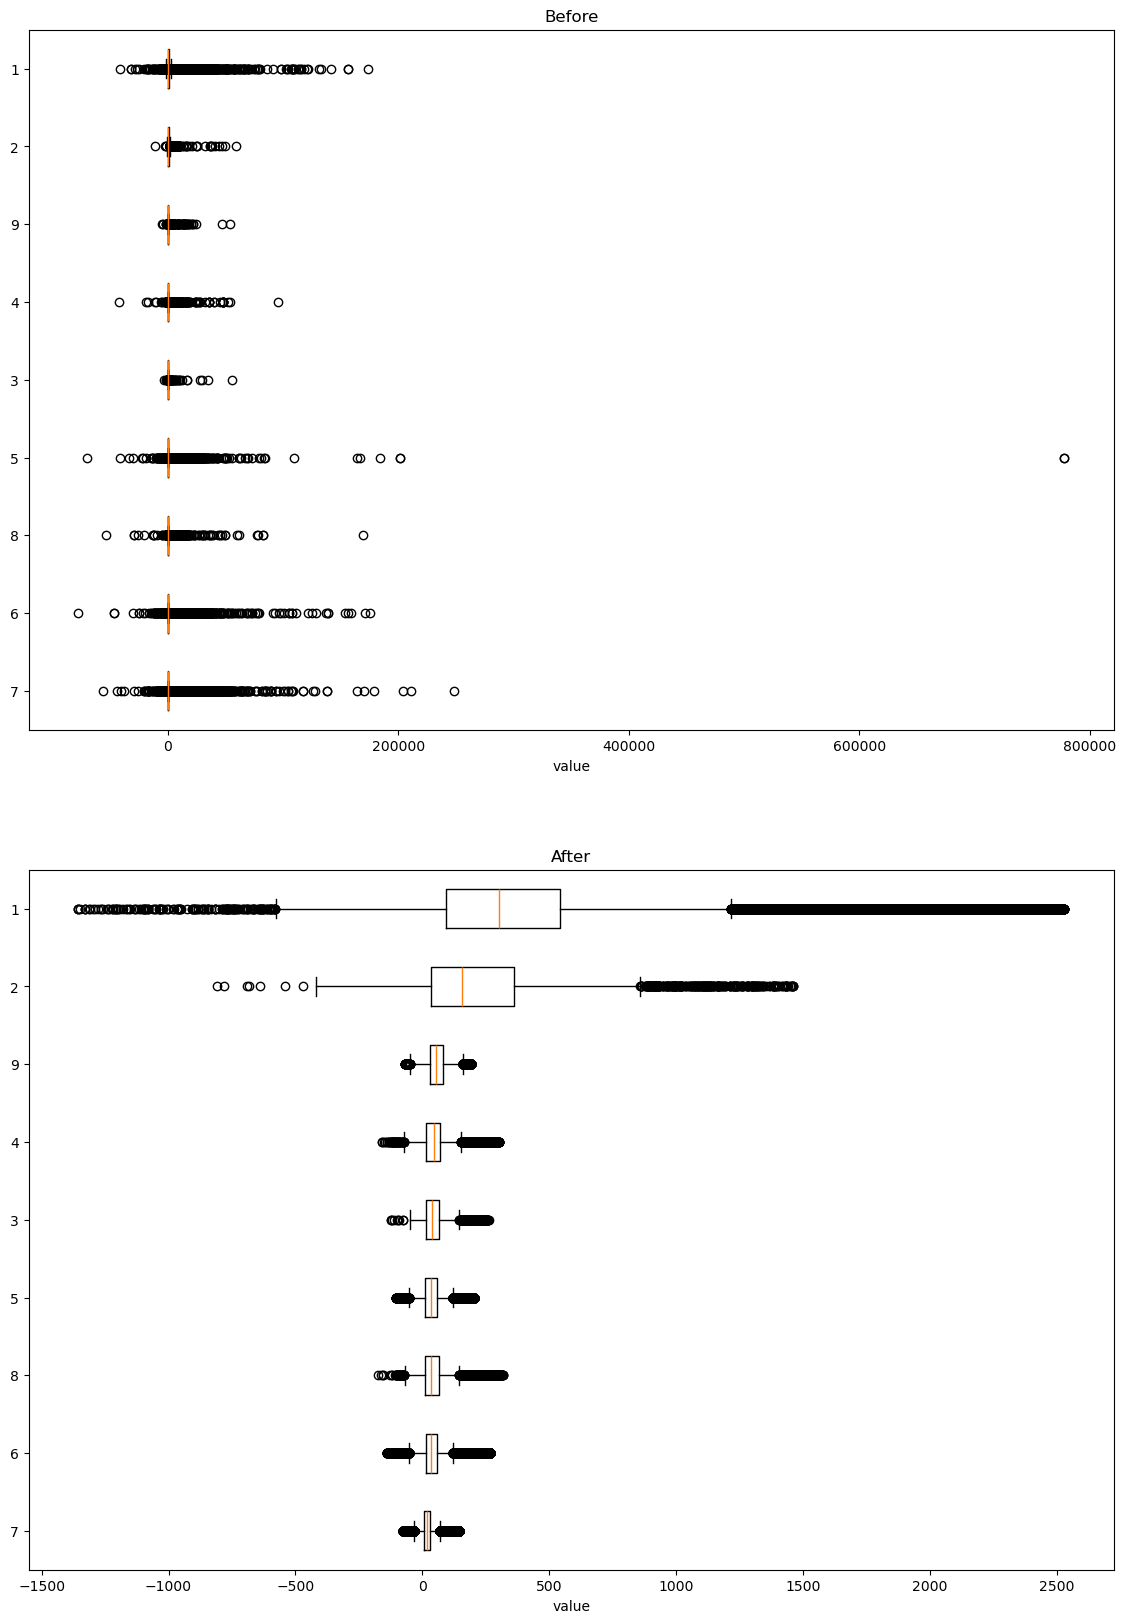

In [295]:
# review the result of outlier fixing  

#boxplot
cat, before, after = 'item_type', 'value_cost_aud', 'value_cost_fixed'

order = (df_2024.groupby(cat)[before].median().sort_values().index)

data_bf = [df_2024.loc[df_2024[cat].eq(c),before].values for c in order]
data_af = [df_2024.loc[df_2024[cat].eq(c),after].values for c in order]

plt.figure(figsize=(14, 20))

plt.subplot(2,1,1)
plt.boxplot(data_bf ,labels = order, vert=False, showfliers=True, whis=1.5)
plt.title ('Before')
plt.xlabel('value')

plt.subplot(2,1,2)
plt.boxplot(data_af ,labels = order, vert=False, showfliers=True, whis=1.5)
plt.title ('After')
plt.xlabel('value')


plt.show()

#### Transformation

##### Histogram

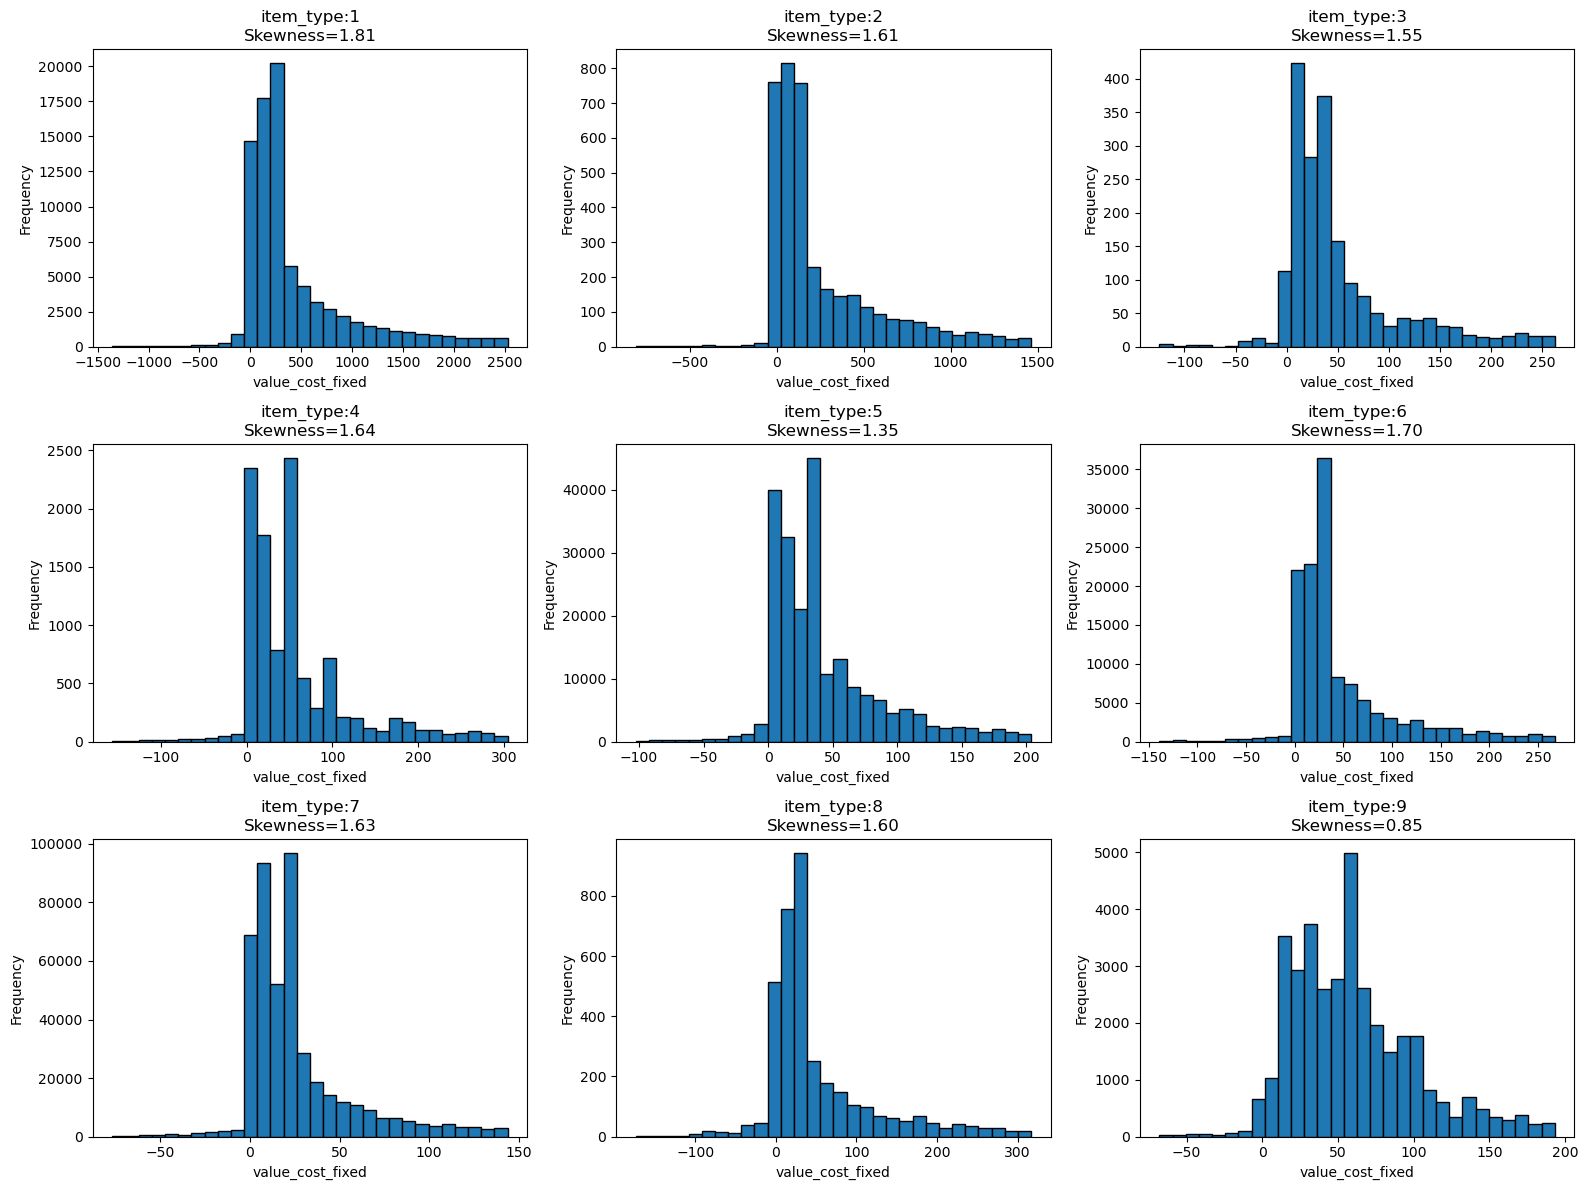

item_type
1    1.808709
2    1.612173
3    1.553428
4    1.639819
5    1.347910
6    1.698905
7    1.634922
8    1.598851
9    0.846795
Name: value_cost_fixed, dtype: float64


In [298]:
# visualization on skewness
cat, col = 'item_type','value_cost_fixed'
cats = sorted(df_2024[cat].unique())

nrows, ncols = 3,3
plt.figure(figsize=(16, 12))

for i,c in enumerate(cats[:nrows * ncols], 1):
    plt.subplot(nrows,ncols,i)
    data = df_2024.loc[df_2024[cat] == c, 'value_cost_fixed']
    skew_val = data.skew()
    plt.hist(data,bins=30,edgecolor='black')
    plt.title(f'{cat}:{c}\nSkewness={skew_val:.2f}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

# list out the skewness
skew_by_cat = df_2024.groupby(cat)[col].skew()
print(skew_by_cat)

##### Signed Log Transformation

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


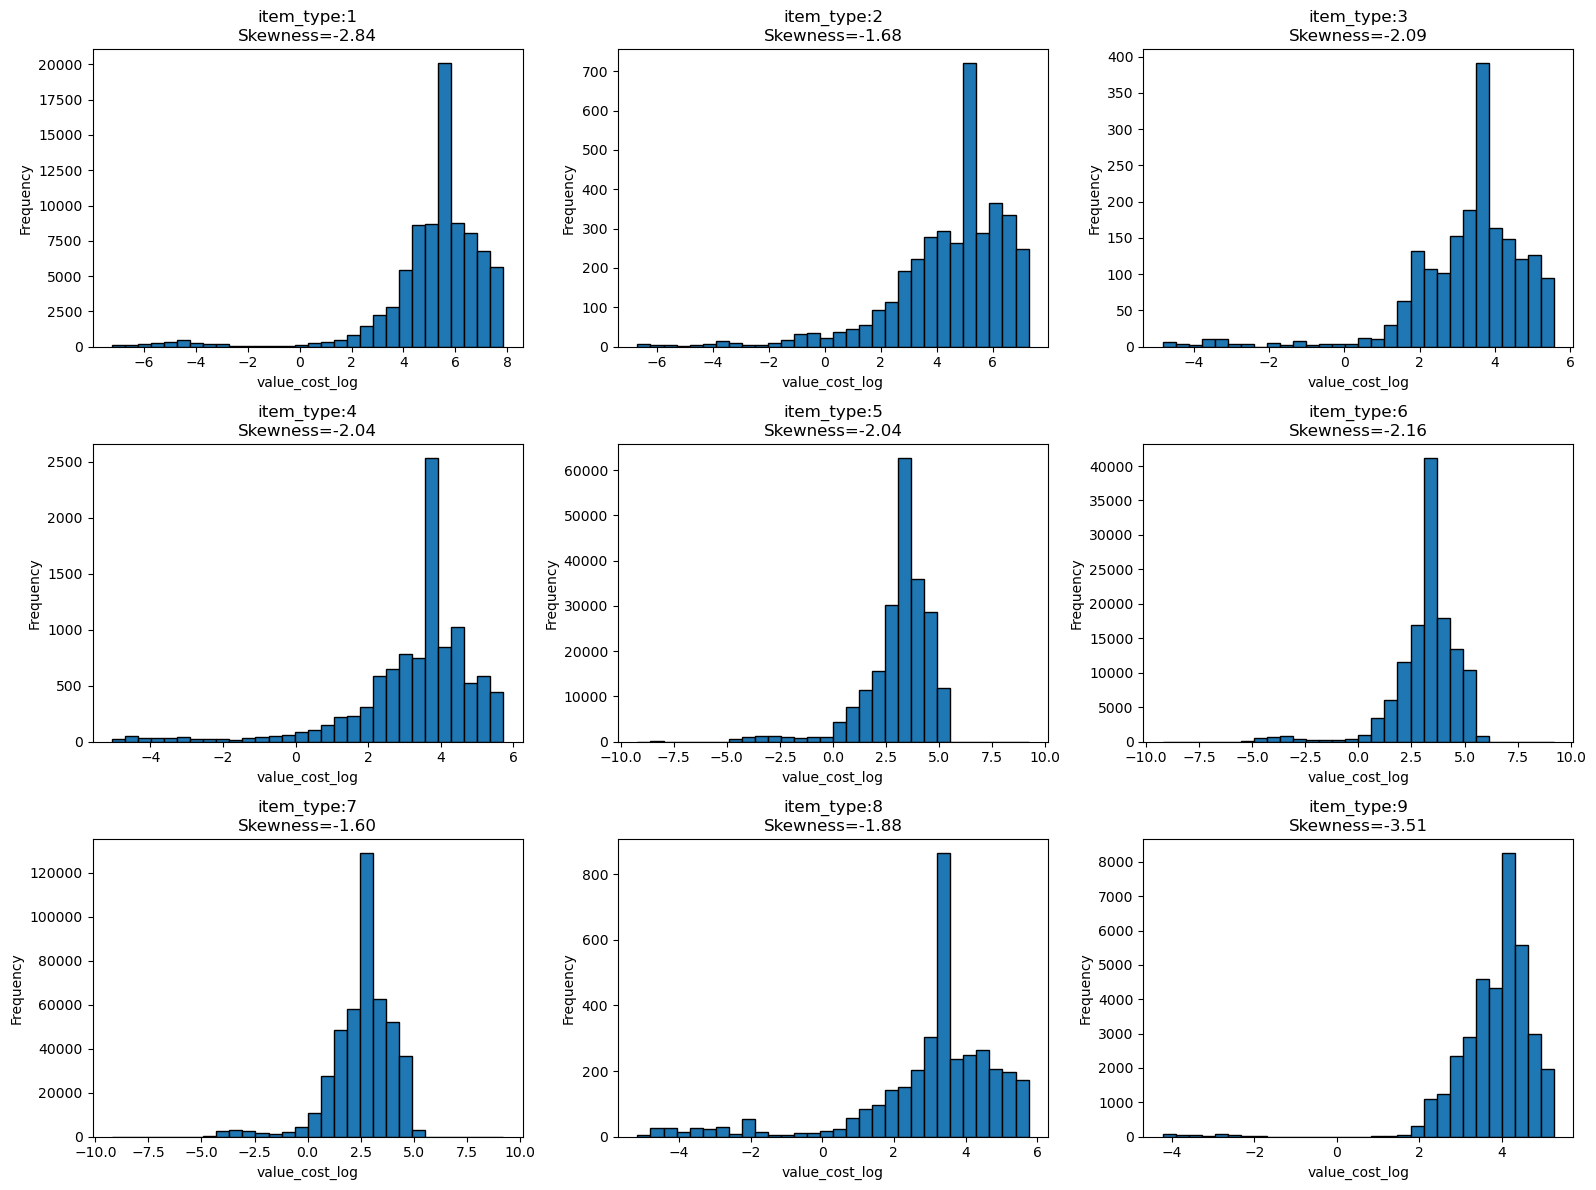

item_type
1   -2.839617
2   -1.681874
3   -2.085567
4   -2.037649
5   -2.037511
6   -2.162763
7   -1.596120
8   -1.878274
9   -3.508008
Name: value_cost_log, dtype: float64


In [300]:
# signed log transforming
df_2024['value_cost_log'] = signed_log(df_2024['value_cost_fixed'])

# visualization on skewness
cat1, col1 = 'item_type','value_cost_log'
cats1 = sorted(df_2024[cat1].unique())

nrows, ncols = 3,3
plt.figure(figsize=(16, 12))

for i,c in enumerate(cats1[:nrows * ncols], 1):
    plt.subplot(nrows,ncols,i)
    data = df_2024.loc[df_2024[cat1] == c, 'value_cost_log']
    skew_val = data.skew()
    plt.hist(data,bins=30,edgecolor='black')
    plt.title(f'{cat1}:{c}\nSkewness={skew_val:.2f}')
    plt.xlabel(col1)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

# list the skewness
skew_by_cat = df_2024.groupby(cat1)[col1].skew()
print(skew_by_cat)

##### Square Root

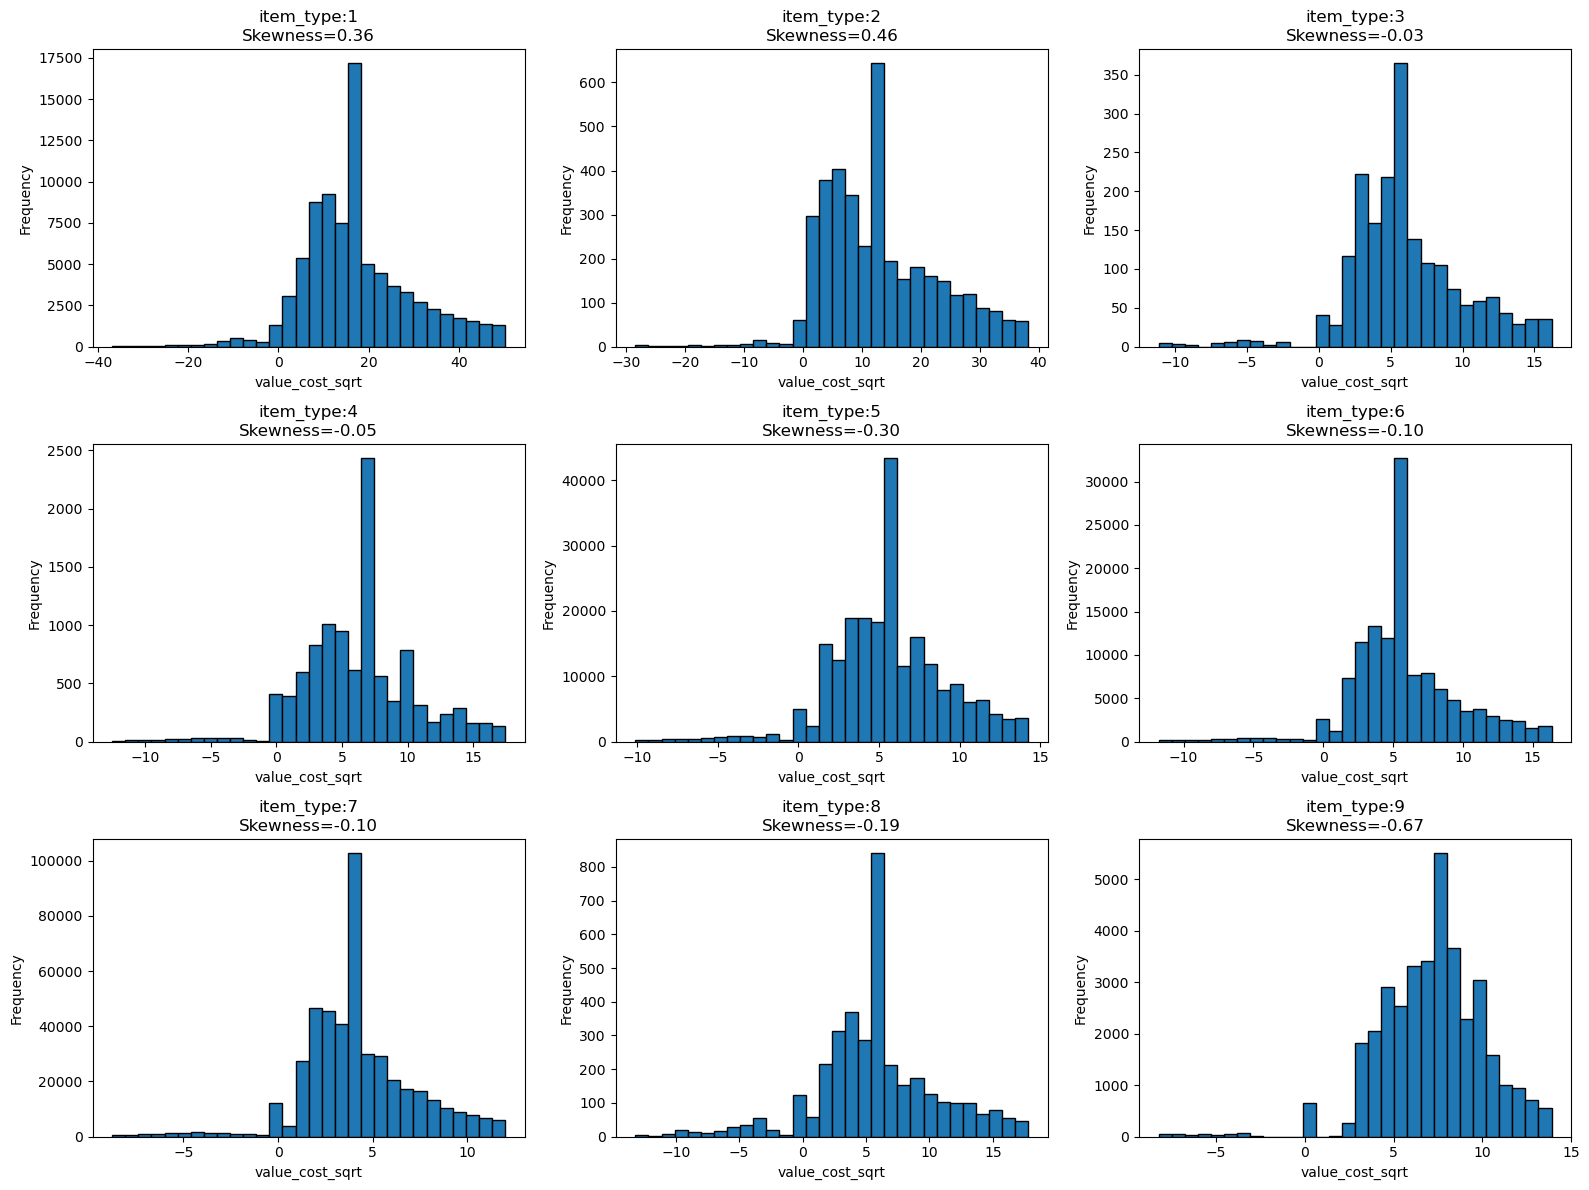

item_type
1    0.362439
2    0.460901
3   -0.026190
4   -0.053281
5   -0.300439
6   -0.097654
7   -0.103960
8   -0.185720
9   -0.673412
Name: value_cost_sqrt, dtype: float64


In [302]:
# transforming by square root
df_2024['value_cost_sqrt'] = signed_sqrt(df_2024['value_cost_fixed'])

# visualization on skewness
cat2, col2 = 'item_type','value_cost_sqrt'
cats2 = sorted(df_2024[cat2].unique())

nrows, ncols = 3,3
plt.figure(figsize=(16, 12))

for i,c in enumerate(cats2[:nrows * ncols], 1):
    plt.subplot(nrows,ncols,i)
    data = df_2024.loc[df_2024[cat2] == c, 'value_cost_sqrt']
    skew_val = data.skew()
    plt.hist(data,bins=30,edgecolor='black')
    plt.title(f'{cat2}:{c}\nSkewness={skew_val:.2f}')
    plt.xlabel(col2)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

# list the skewness
skew_by_cat = df_2024.groupby(cat2)[col2].skew()
print(skew_by_cat)

##### Yeo-Johnson 

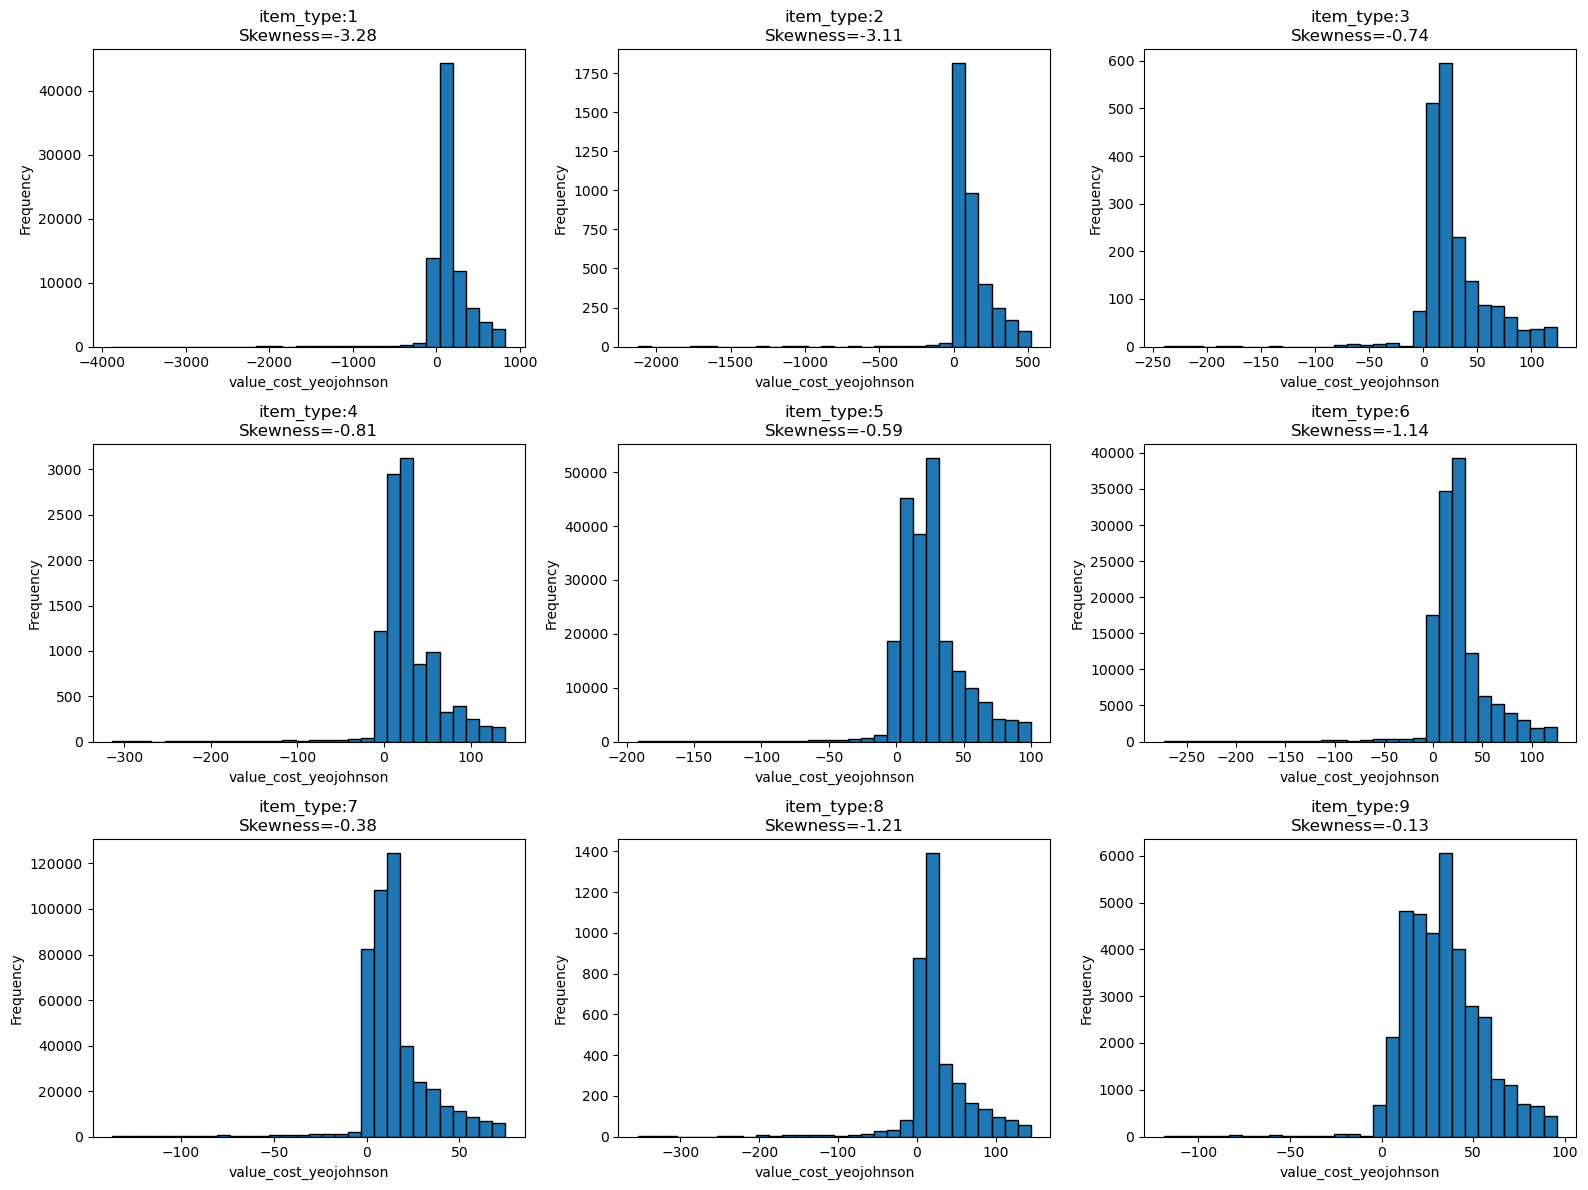

item_type
1   -3.275070
2   -3.105611
3   -0.740317
4   -0.814277
5   -0.590481
6   -1.142285
7   -0.379365
8   -1.212983
9   -0.127153
Name: value_cost_yeojohnson, dtype: float64


In [304]:
df_2024['value_cost_yeojohnson'] = pt.fit_transform(df_2024[['value_cost_fixed']])

# visualization on skewness
cat3, col3 = 'item_type','value_cost_yeojohnson'
cats3 = sorted(df_2024[cat3].unique())

nrows, ncols = 3,3
plt.figure(figsize=(16, 12))

for i,c in enumerate(cats3[:nrows * ncols], 1):
    plt.subplot(nrows,ncols,i)
    data = df_2024.loc[df_2024[cat3] == c, 'value_cost_yeojohnson']
    skew_val = data.skew()
    plt.hist(data,bins=30,edgecolor='black')
    plt.title(f'{cat3}:{c}\nSkewness={skew_val:.2f}')
    plt.xlabel(col3)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

# list skewness
skew_by_cat = df_2024.groupby(cat3)[col3].skew()
print(skew_by_cat)

### Value_Quantity (AUD) 2023

#### Visualization - outliers

##### scatterplot

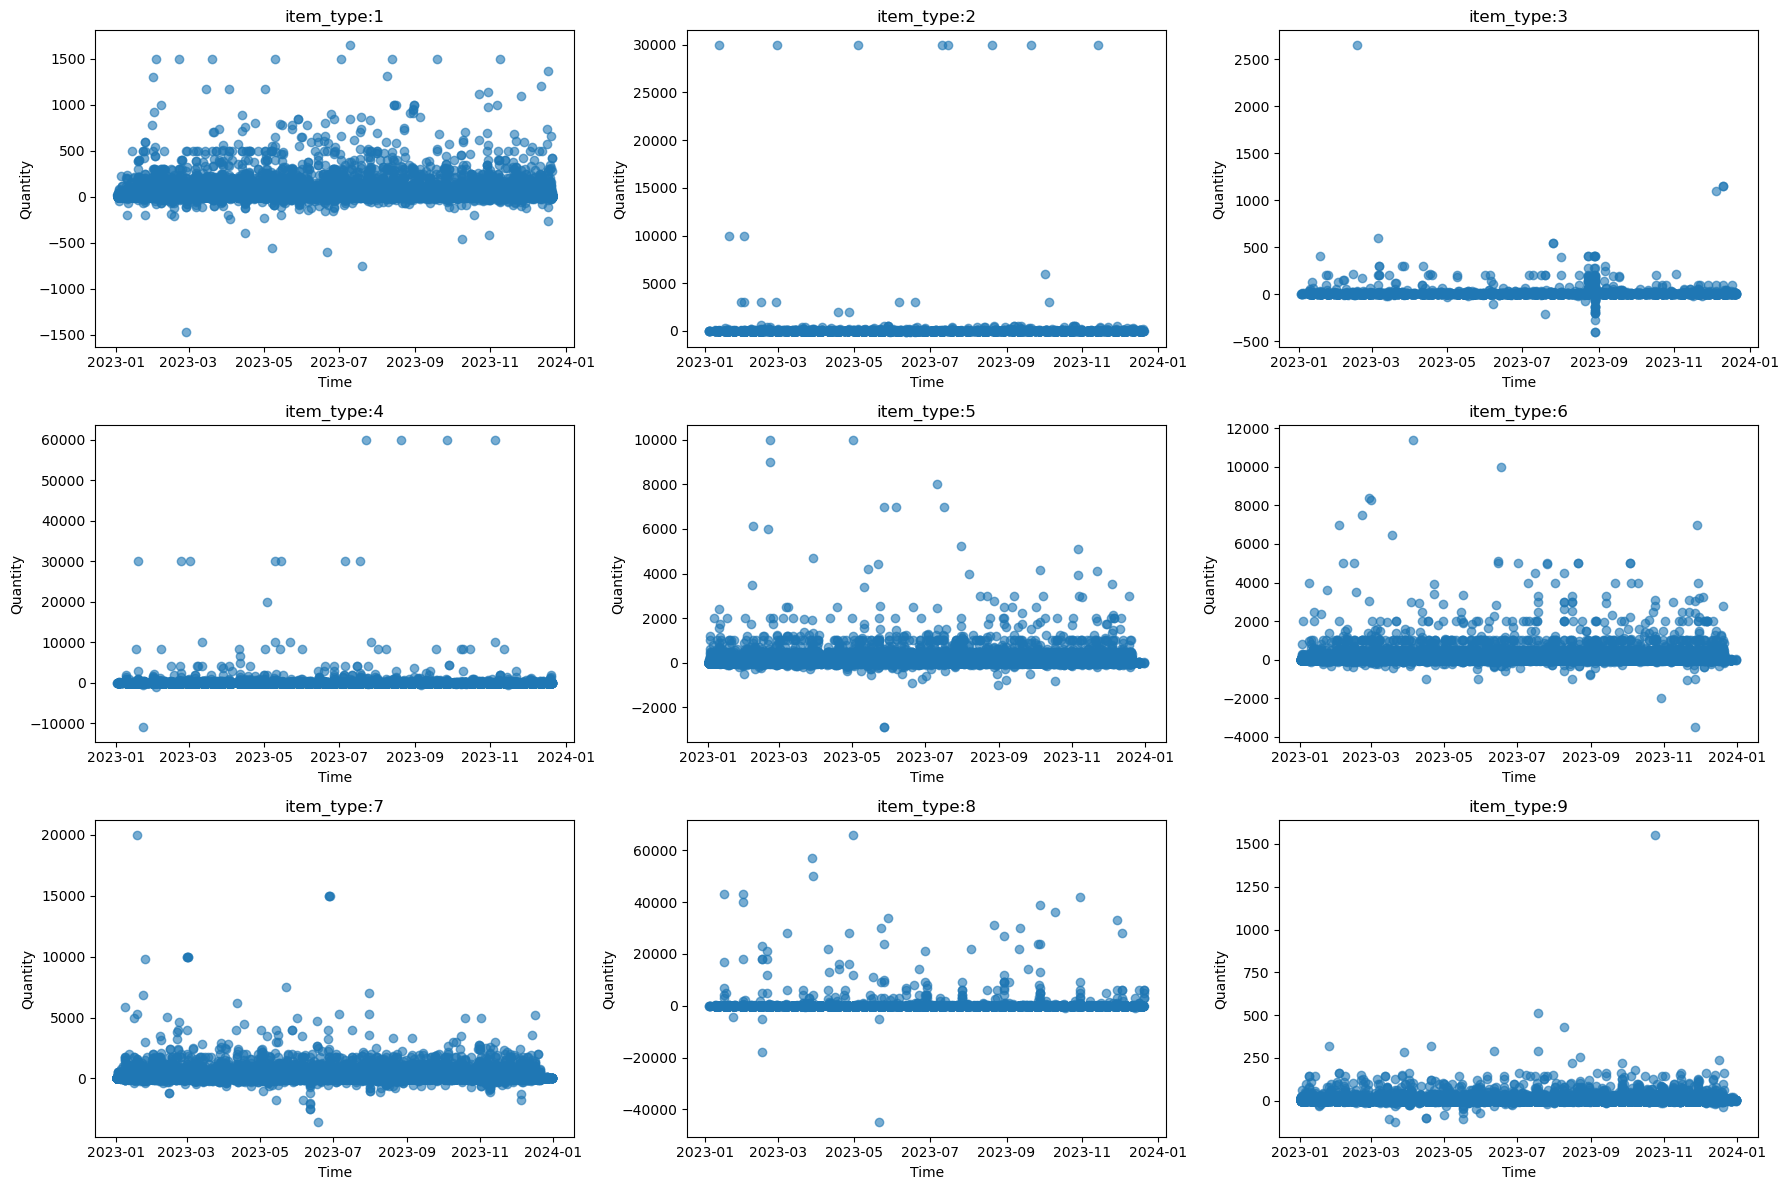

In [308]:
# to see the quantity over time

cat, x, y = 'item_type','accounting_date','value_quantity'
cats = sorted(df_2023[cat].unique())
n = len(cats)

ncols = 3
nrows = -(-n // ncols)

plt.figure(figsize = (6 * ncols, 4 * nrows))

for i, c in enumerate(cats,1):
    subset = df_2023[df_2023[cat] == c]
    plt.subplot(nrows, ncols, i)
    plt.scatter(subset[x],subset[y],alpha = 0.6)
    plt.title(f"{cat}:{c}")
    plt.xlabel("Time")
    plt.ylabel("Quantity")
    
plt.tight_layout()
plt.show()

##### Boxplot

/var/folders/c6/xxws1v553296lnd2hthddtqh0000gn/T/ipykernel_26791/3655460589.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data ,labels = cats, showfliers=True, whis=1.5)


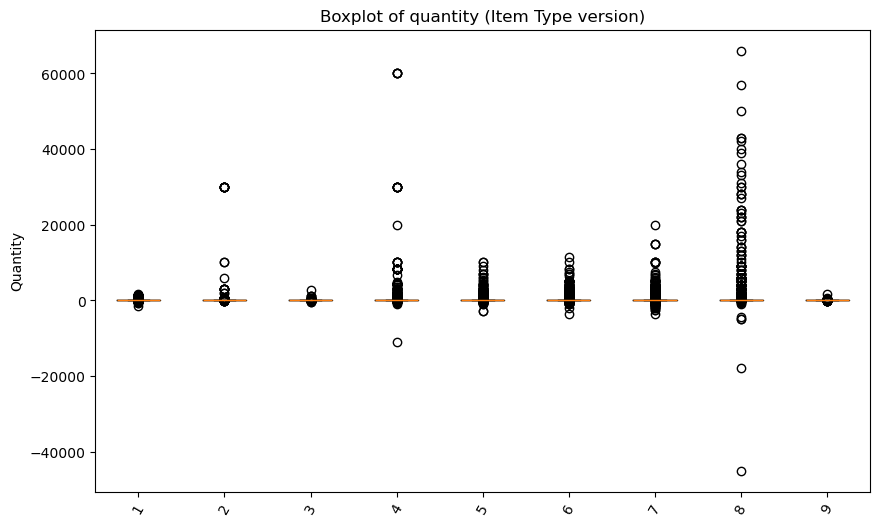

In [310]:
cat, val = 'item_type','value_quantity'
cats = sorted(df_2023[cat].unique())

data = [df_2023.loc[df_2023[cat].eq(c),val].values for c in cats]

plt.figure(figsize=(10,6))

plt.boxplot(data ,labels = cats, showfliers=True, whis=1.5)
plt.xticks(rotation=60)
plt.title('Boxplot of quantity (Item Type version)')
plt.ylabel('Quantity')

plt.show()

#### Outlier Removal - IQR method

In [312]:
#caluclate 25th percentile of transformed sales
percentile25 = df_2023.groupby("item_type")['value_quantity'].quantile(0.25)
print('percentile25:')
print(percentile25)
print()
#caluclate 75th percentile of transformed sales
percentile75 = df_2023.groupby("item_type")['value_quantity'].quantile(0.75)
print('percentile75:')
print(percentile75)
print()
#calculate the IQR
iqr = percentile75 - percentile25
print('IQR:')
print(iqr)
print()
#locate the limitation range 
upper_limit = percentile75 + 1.5 * iqr
lower_limit = percentile25 - 1.5 * iqr

print('upper limit:')
print(upper_limit)
print()
print('lower limit:')
print(lower_limit)

# save these values in new columns for further adjustemnts
df_2023["percentile25"] = df_2023['item_type'].map(percentile25)
df_2023["percentile75"] = df_2023['item_type'].map(percentile75)
df_2023["lower end"] = df_2023['item_type'].map(lower_limit)
df_2023["upper end"] = df_2023['item_type'].map(upper_limit)

percentile25:
item_type
1    2.0
2    2.0
3    1.0
4    2.0
5    2.0
6    2.0
7    3.0
8    1.0
9    2.0
Name: value_quantity, dtype: float64

percentile75:
item_type
1    11.0
2    20.0
3    10.0
4    20.0
5    15.0
6    20.0
7    20.0
8    18.0
9     8.0
Name: value_quantity, dtype: float64

IQR:
item_type
1     9.0
2    18.0
3     9.0
4    18.0
5    13.0
6    18.0
7    17.0
8    17.0
9     6.0
Name: value_quantity, dtype: float64

upper limit:
item_type
1    24.5
2    47.0
3    23.5
4    47.0
5    34.5
6    47.0
7    45.5
8    43.5
9    17.0
Name: value_quantity, dtype: float64

lower limit:
item_type
1   -11.5
2   -25.0
3   -12.5
4   -25.0
5   -17.5
6   -25.0
7   -22.5
8   -24.5
9    -7.0
Name: value_quantity, dtype: float64


In [313]:
#isolate outliers on low end by group
sales_lower = df_2023[df_2023['value_quantity'] < df_2023['item_type'].map(lower_limit)]
#isolate outliers on upper end by group
sales_upper = df_2023[df_2023['value_quantity'] > df_2023['item_type'].map(upper_limit)]
#locate the medium sales for each type
median_sales = df_2023.groupby('item_type')['value_quantity'].median()
# create a new column to save the median value for each categories
df_2023["median_quantity"] = df_2023.groupby("item_type")["value_quantity"].transform("median")
# create other columns to save the transformed replaced value 
df_2023['quantity outlier'] = ~df_2023["value_quantity"].between(df_2023['lower end'], df_2023['upper end'], inclusive='both')
df_2023['value_quantity_fixed'] = df_2023['value_quantity'].mask(df_2023['quantity outlier'],df_2023['median_cost'])
df_2023[['item_type','value_quantity','median_quantity','quantity outlier', 'value_quantity_fixed']]

,item_type,value_quantity,median_quantity,quantity outlier,value_quantity_fixed
9,5,-2.0,6.0,False,-2.0000
10,5,6.0,6.0,False,6.0000
11,5,138.0,6.0,True,31.8002
13,5,72.0,6.0,True,31.8002
14,5,6.0,6.0,False,6.0000
...,...,...,...,...,...
1037200,5,6.0,6.0,False,6.0000
1037201,5,12.0,6.0,False,12.0000
1037202,5,6.0,6.0,False,6.0000
1037203,5,18.0,6.0,False,18.0000


/var/folders/c6/xxws1v553296lnd2hthddtqh0000gn/T/ipykernel_26791/2282675794.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_bf ,labels = order, vert=False, showfliers=True, whis=1.5)
/var/folders/c6/xxws1v553296lnd2hthddtqh0000gn/T/ipykernel_26791/2282675794.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_af ,labels = order, vert=False, showfliers=True, whis=1.5)


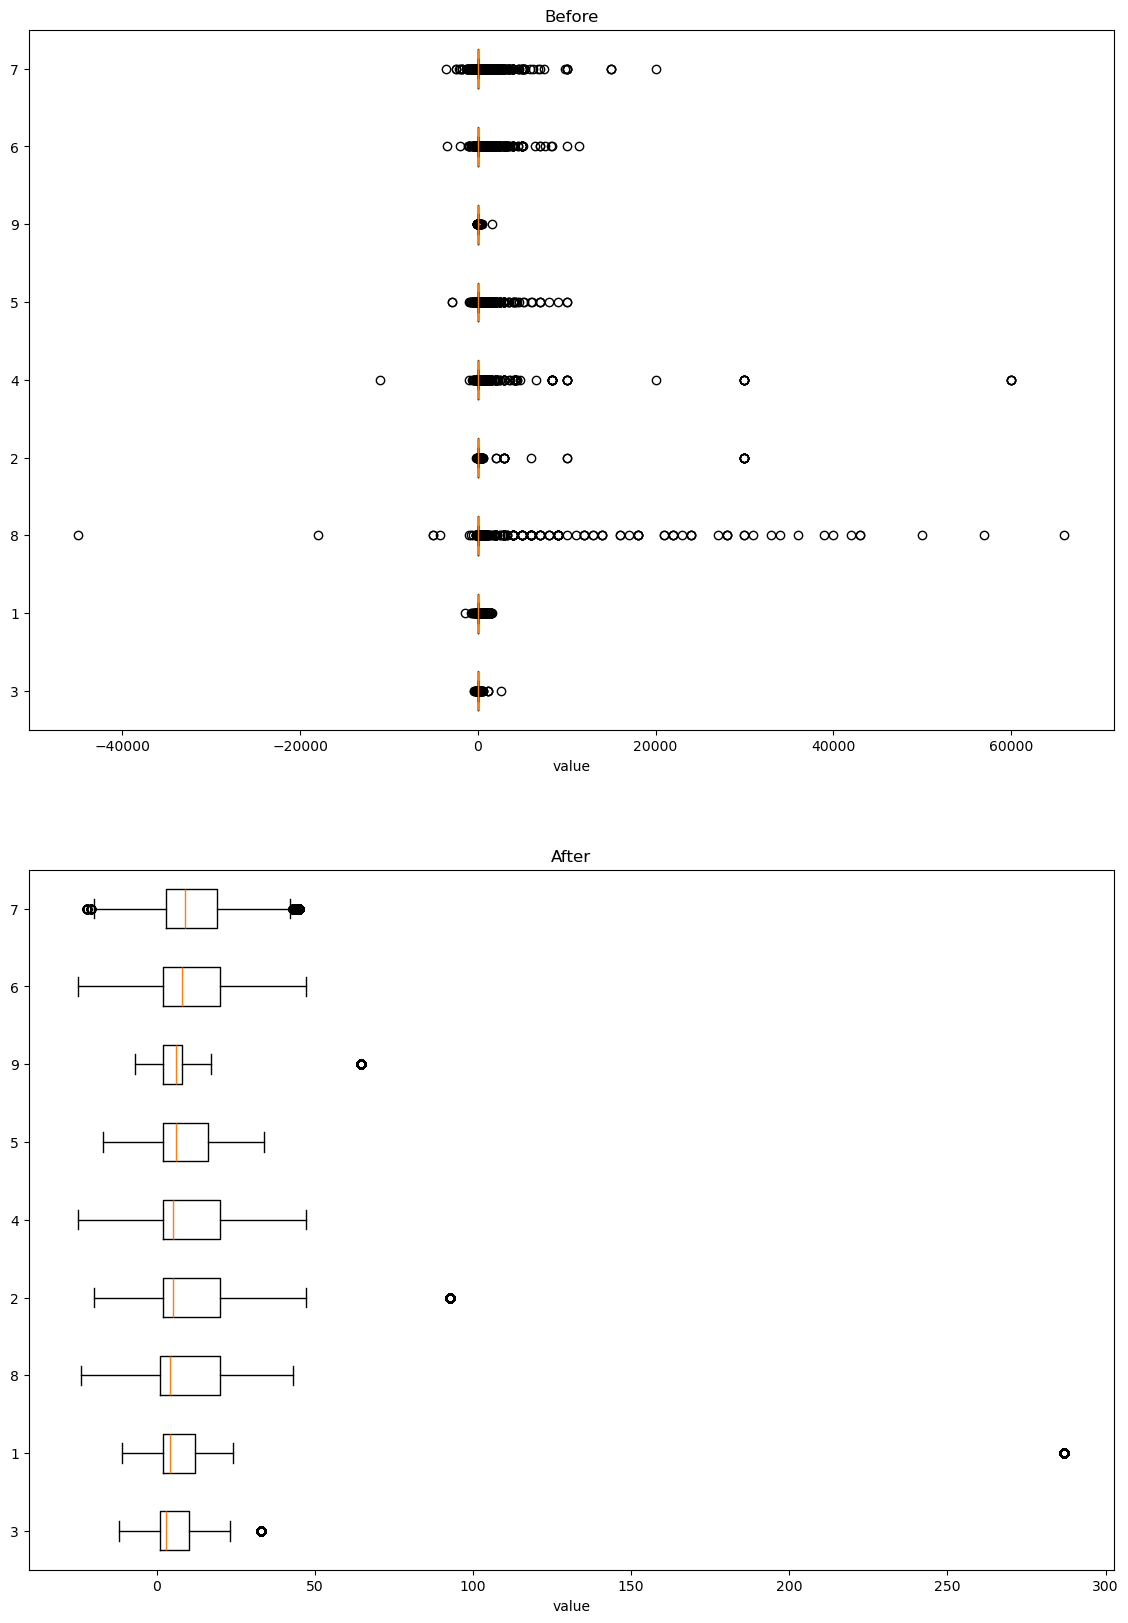

In [314]:
# review the result of outlier fixing  

#boxplot
cat, before, after = 'item_type', 'value_quantity', 'value_quantity_fixed'

order = (df_2023.groupby(cat)[before].median().sort_values().index)

data_bf = [df_2023.loc[df_2023[cat].eq(c),before].values for c in order]
data_af = [df_2023.loc[df_2023[cat].eq(c),after].values for c in order]

plt.figure(figsize=(14, 20))

plt.subplot(2,1,1)
plt.boxplot(data_bf ,labels = order, vert=False, showfliers=True, whis=1.5)
plt.title ('Before')
plt.xlabel('value')

plt.subplot(2,1,2)
plt.boxplot(data_af ,labels = order, vert=False, showfliers=True, whis=1.5)
plt.title ('After')
plt.xlabel('value')


plt.show()

#### Transformation

##### Histogram

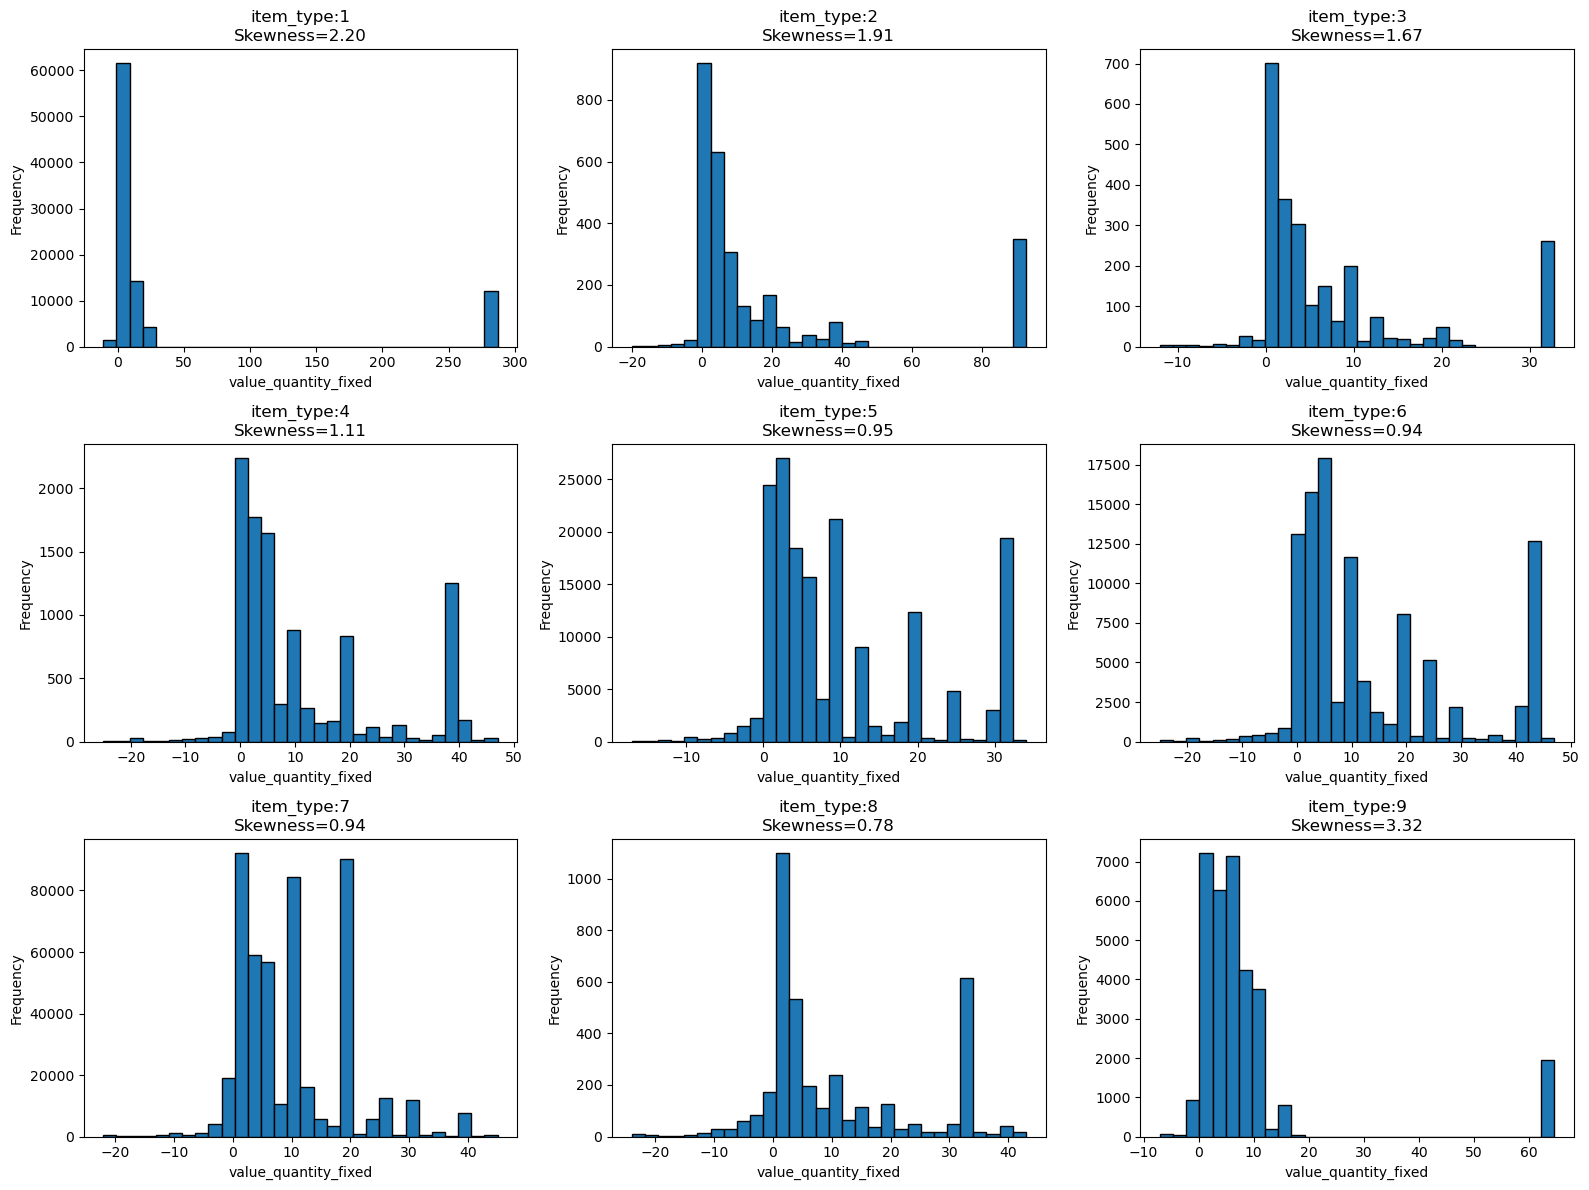

item_type
1    2.197354
2    1.905231
3    1.666056
4    1.111812
5    0.946189
6    0.942879
7    0.935881
8    0.777278
9    3.316941
Name: value_quantity_fixed, dtype: float64


In [317]:
# visualization on skewness
cat, col = 'item_type','value_quantity_fixed'
cats = sorted(df_2023[cat].unique())

nrows, ncols = 3,3
plt.figure(figsize=(16, 12))

for i,c in enumerate(cats[:nrows * ncols], 1):
    plt.subplot(nrows,ncols,i)
    data = df_2023.loc[df_2023[cat] == c, 'value_quantity_fixed']
    skew_val = data.skew()
    plt.hist(data,bins=30,edgecolor='black')
    plt.title(f'{cat}:{c}\nSkewness={skew_val:.2f}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

# skewness list
skew_by_cat = df_2023.groupby(cat)[col].skew()
print(skew_by_cat)

##### Signed log

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


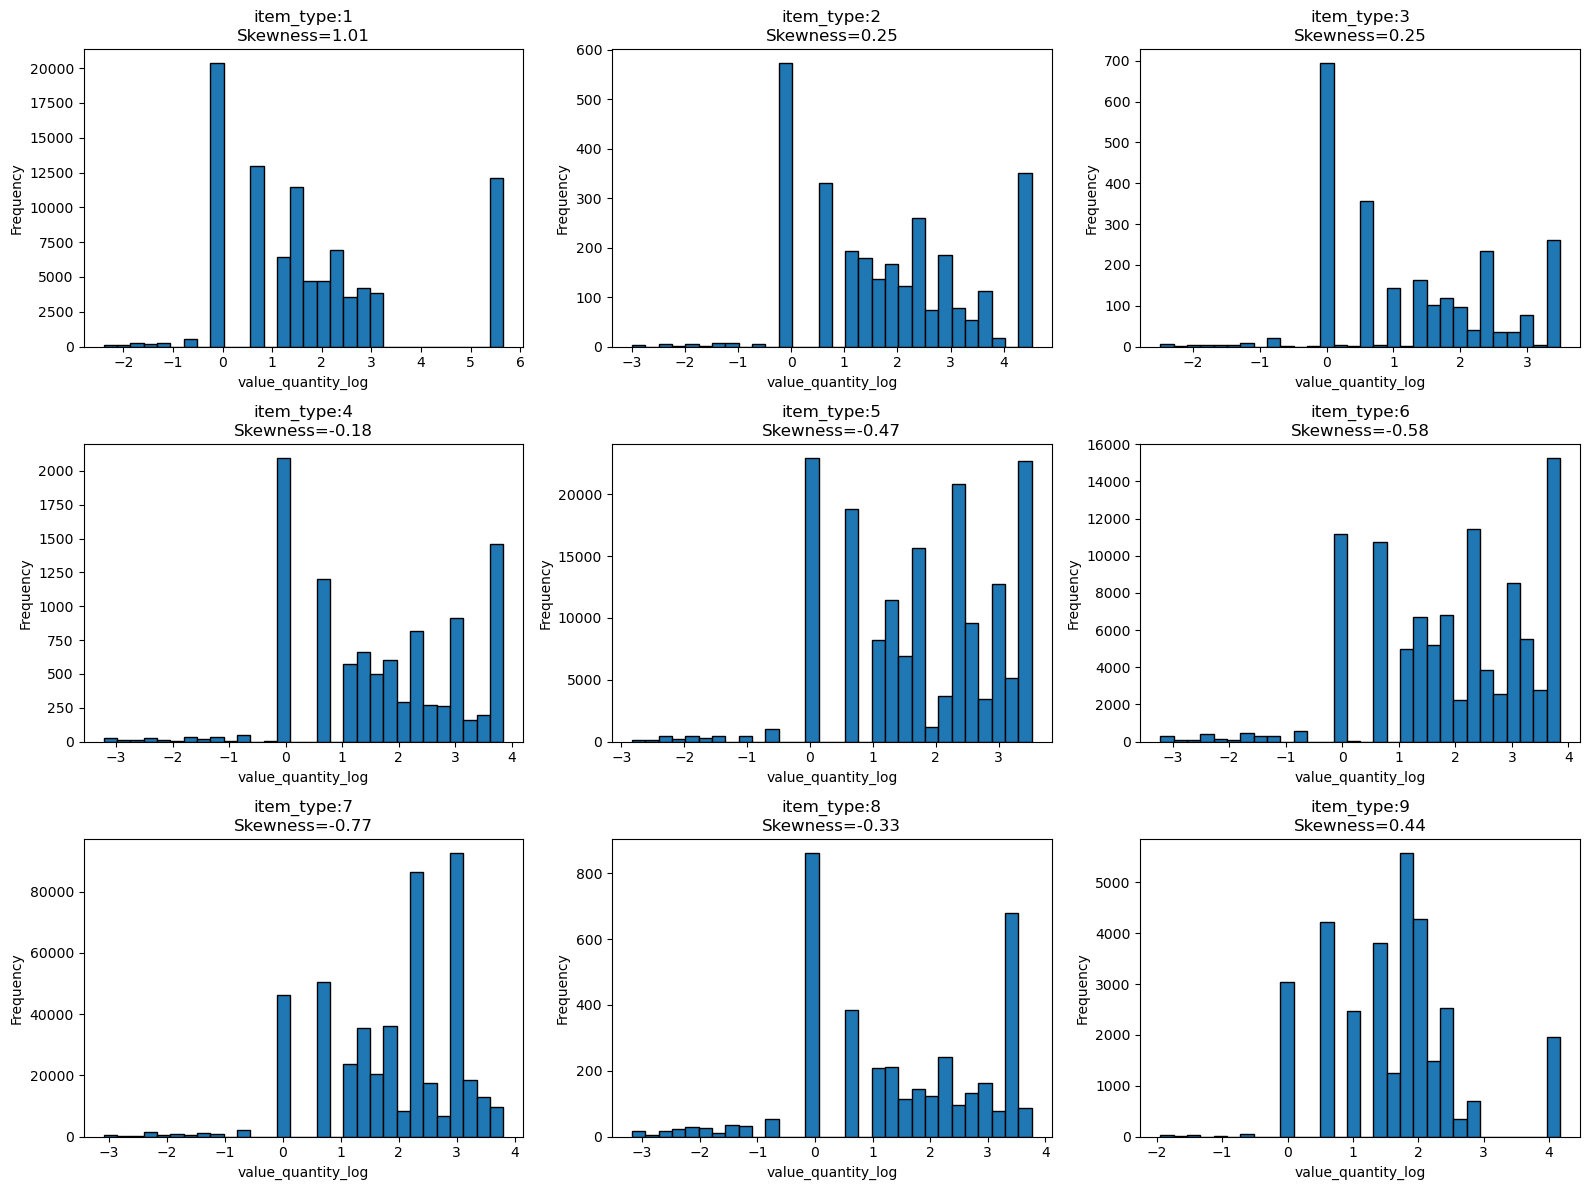

item_type
1    1.014544
2    0.254136
3    0.248253
4   -0.182875
5   -0.473414
6   -0.584436
7   -0.774789
8   -0.334758
9    0.441849
Name: value_quantity_log, dtype: float64


In [319]:
# signed log transforming
df_2023['value_quantity_log'] = signed_log(df_2023['value_quantity_fixed'])

# visualization on skewness
cat1, col1 = 'item_type','value_quantity_log'
cats1 = sorted(df_2023[cat1].unique())

nrows, ncols = 3,3
plt.figure(figsize=(16, 12))

for i,c in enumerate(cats1[:nrows * ncols], 1):
    plt.subplot(nrows,ncols,i)
    data = df_2023.loc[df_2023[cat1] == c, 'value_quantity_log']
    skew_val = data.skew()
    plt.hist(data,bins=30,edgecolor='black')
    plt.title(f'{cat1}:{c}\nSkewness={skew_val:.2f}')
    plt.xlabel(col1)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

# list the skewness
skew_by_cat = df_2023.groupby(cat1)[col1].skew()
print(skew_by_cat)

##### Square Root

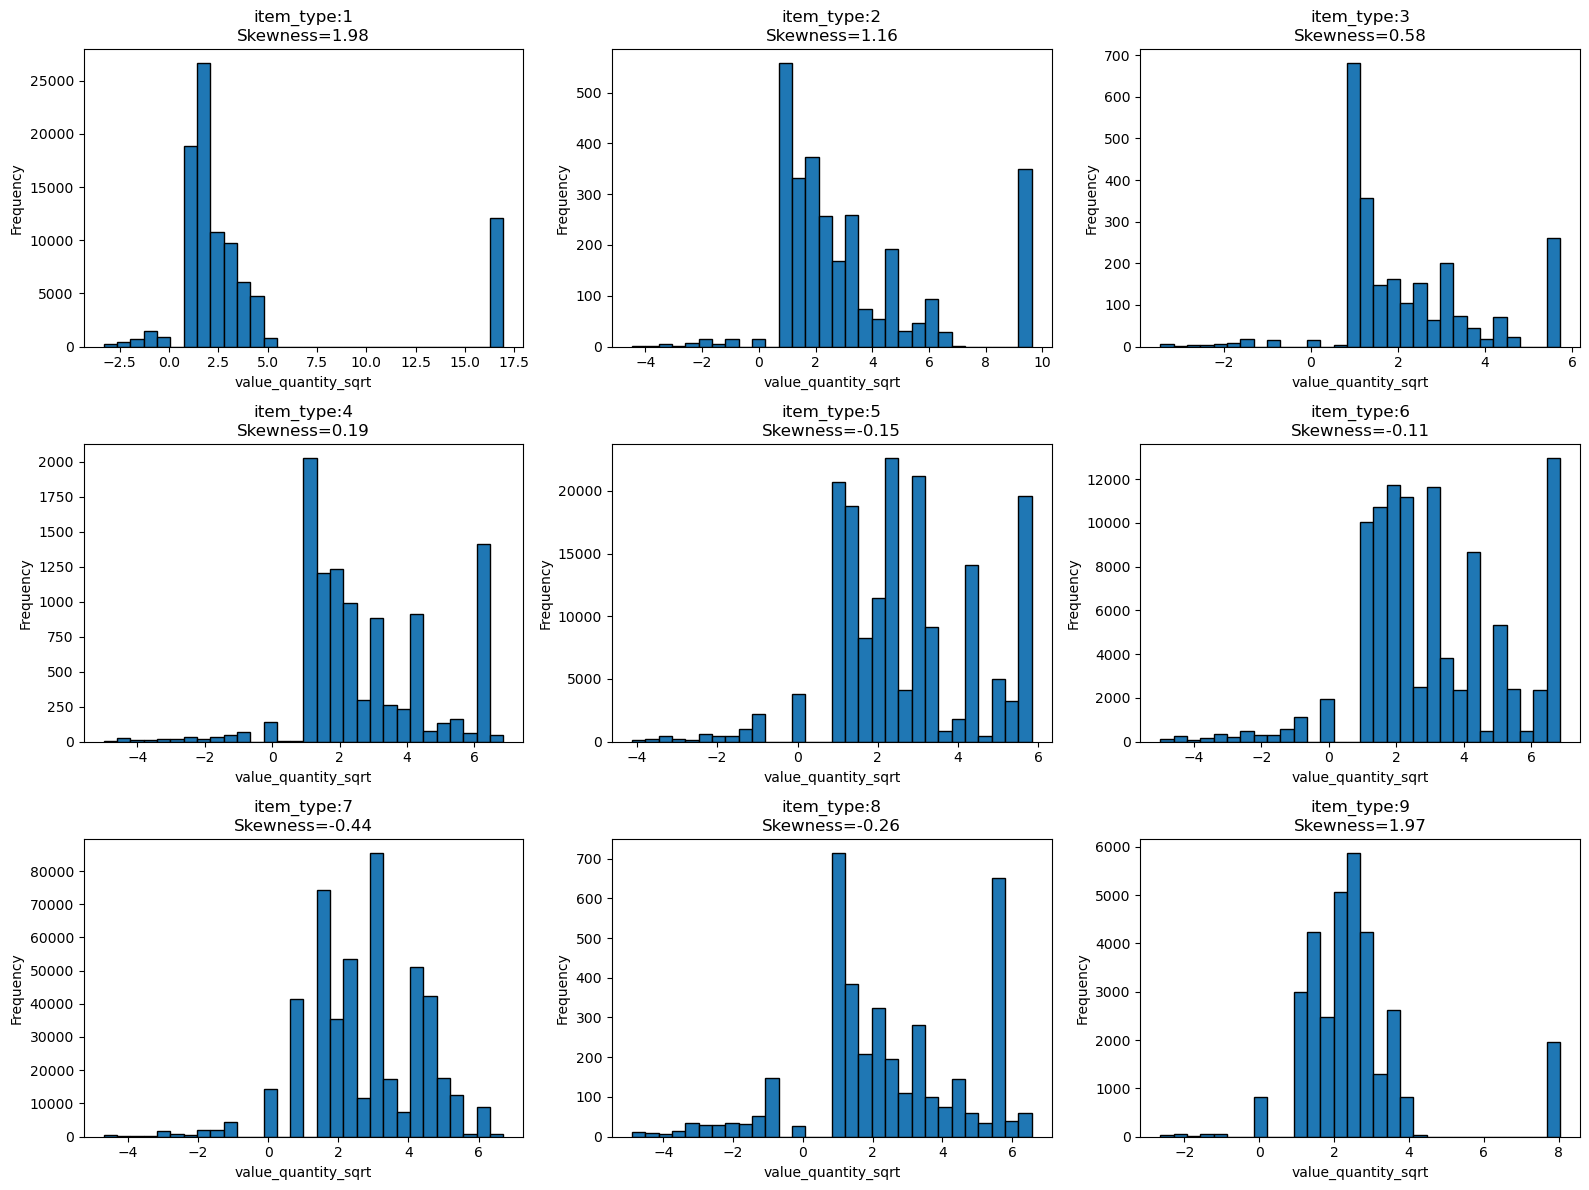

item_type
1    1.979251
2    1.163885
3    0.578336
4    0.194332
5   -0.150345
6   -0.114735
7   -0.437247
8   -0.255113
9    1.973547
Name: value_quantity_sqrt, dtype: float64


In [321]:
# transforming by square root
df_2023['value_quantity_sqrt'] = signed_sqrt(df_2023['value_quantity_fixed'])

# visualization on skewness
cat2, col2 = 'item_type','value_quantity_sqrt'
cats2 = sorted(df_2023[cat2].unique())

nrows, ncols = 3,3
plt.figure(figsize=(16, 12))

for i,c in enumerate(cats2[:nrows * ncols], 1):
    plt.subplot(nrows,ncols,i)
    data = df_2023.loc[df_2023[cat2] == c, 'value_quantity_sqrt']
    skew_val = data.skew()
    plt.hist(data,bins=30,edgecolor='black')
    plt.title(f'{cat2}:{c}\nSkewness={skew_val:.2f}')
    plt.xlabel(col2)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

# list the skewness
skew_by_cat = df_2023.groupby(cat2)[col2].skew()
print(skew_by_cat)

##### Yeo-Johnson 

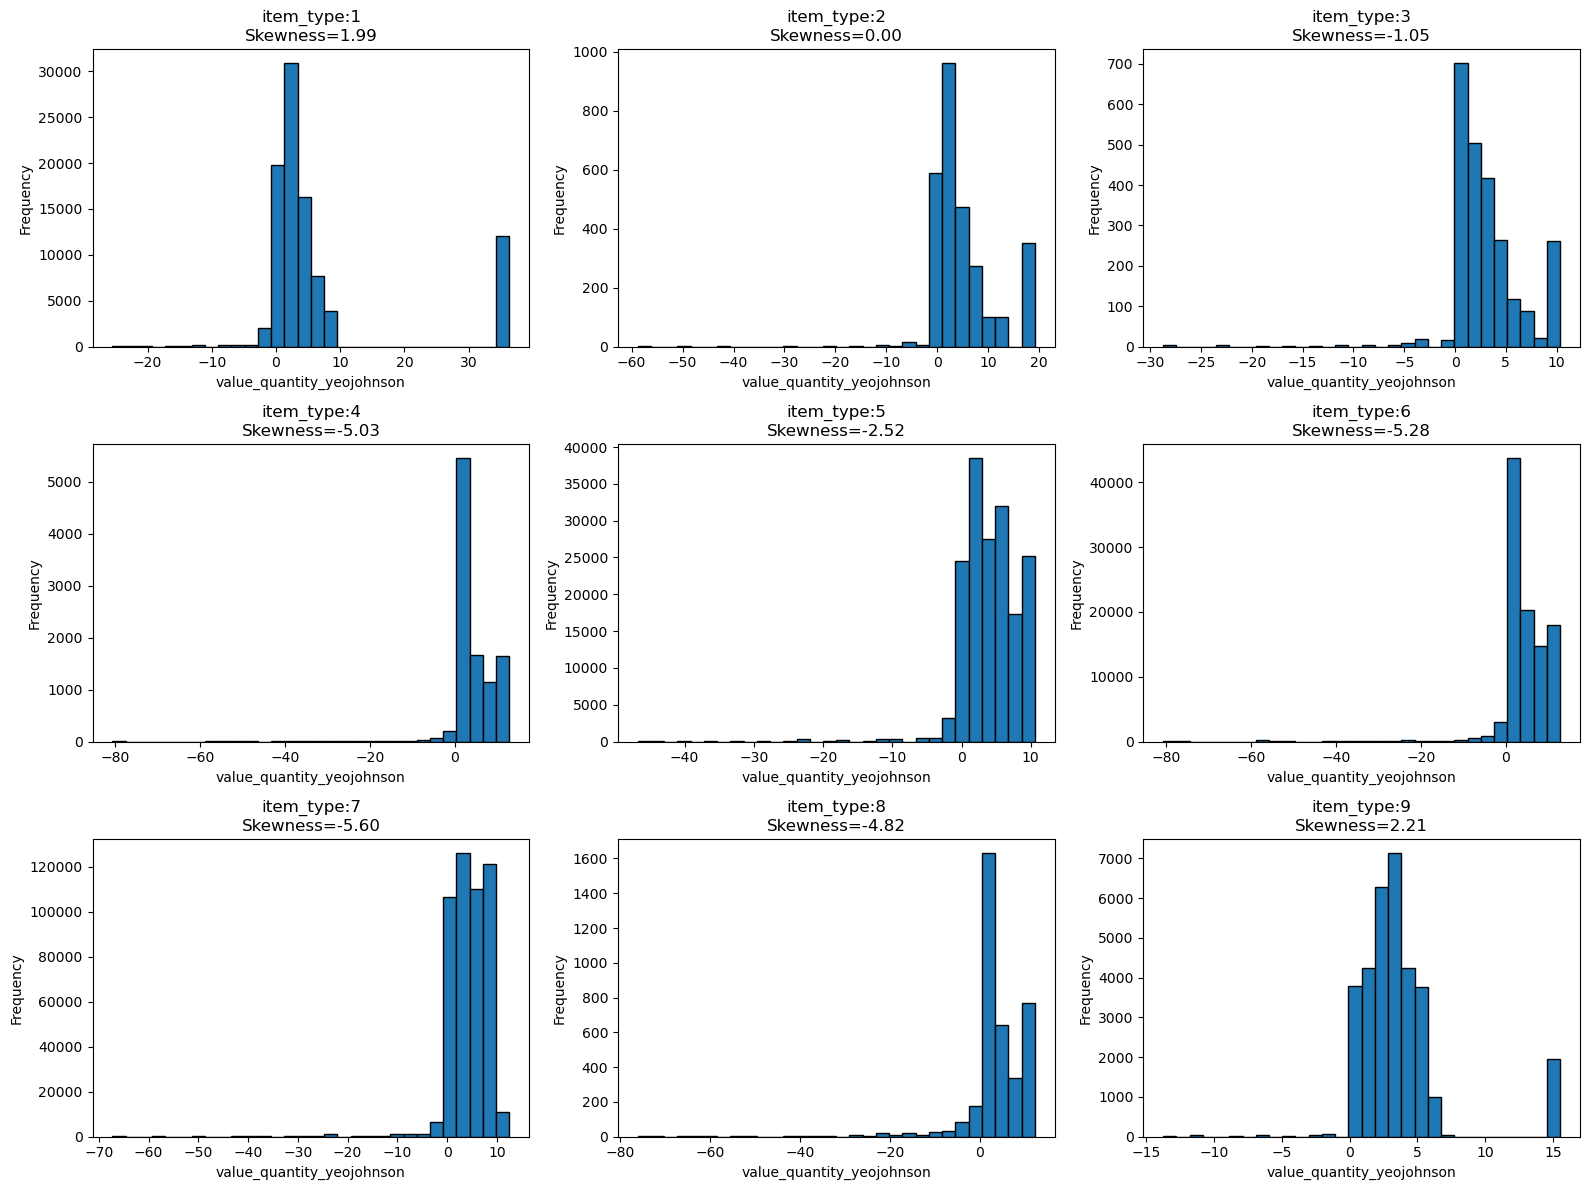

item_type
1    1.993301
2    0.001306
3   -1.049026
4   -5.027783
5   -2.524301
6   -5.279022
7   -5.597333
8   -4.821213
9    2.213784
Name: value_quantity_yeojohnson, dtype: float64


In [323]:
df_2023['value_quantity_yeojohnson'] = pt.fit_transform(df_2023[['value_quantity_fixed']])

# visualization on skewness
cat3, col3 = 'item_type','value_quantity_yeojohnson'
cats3 = sorted(df_2023[cat3].unique())

nrows, ncols = 3,3
plt.figure(figsize=(16, 12))

for i,c in enumerate(cats3[:nrows * ncols], 1):
    plt.subplot(nrows,ncols,i)
    data = df_2023.loc[df_2023[cat3] == c, 'value_quantity_yeojohnson']
    skew_val = data.skew()
    plt.hist(data,bins=30,edgecolor='black')
    plt.title(f'{cat3}:{c}\nSkewness={skew_val:.2f}')
    plt.xlabel(col3)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

# list skewness
skew_by_cat = df_2023.groupby(cat3)[col3].skew()
print(skew_by_cat)

### Value_Quantity (AUD) 2024

#### Visualization - outliers

##### scatterplot

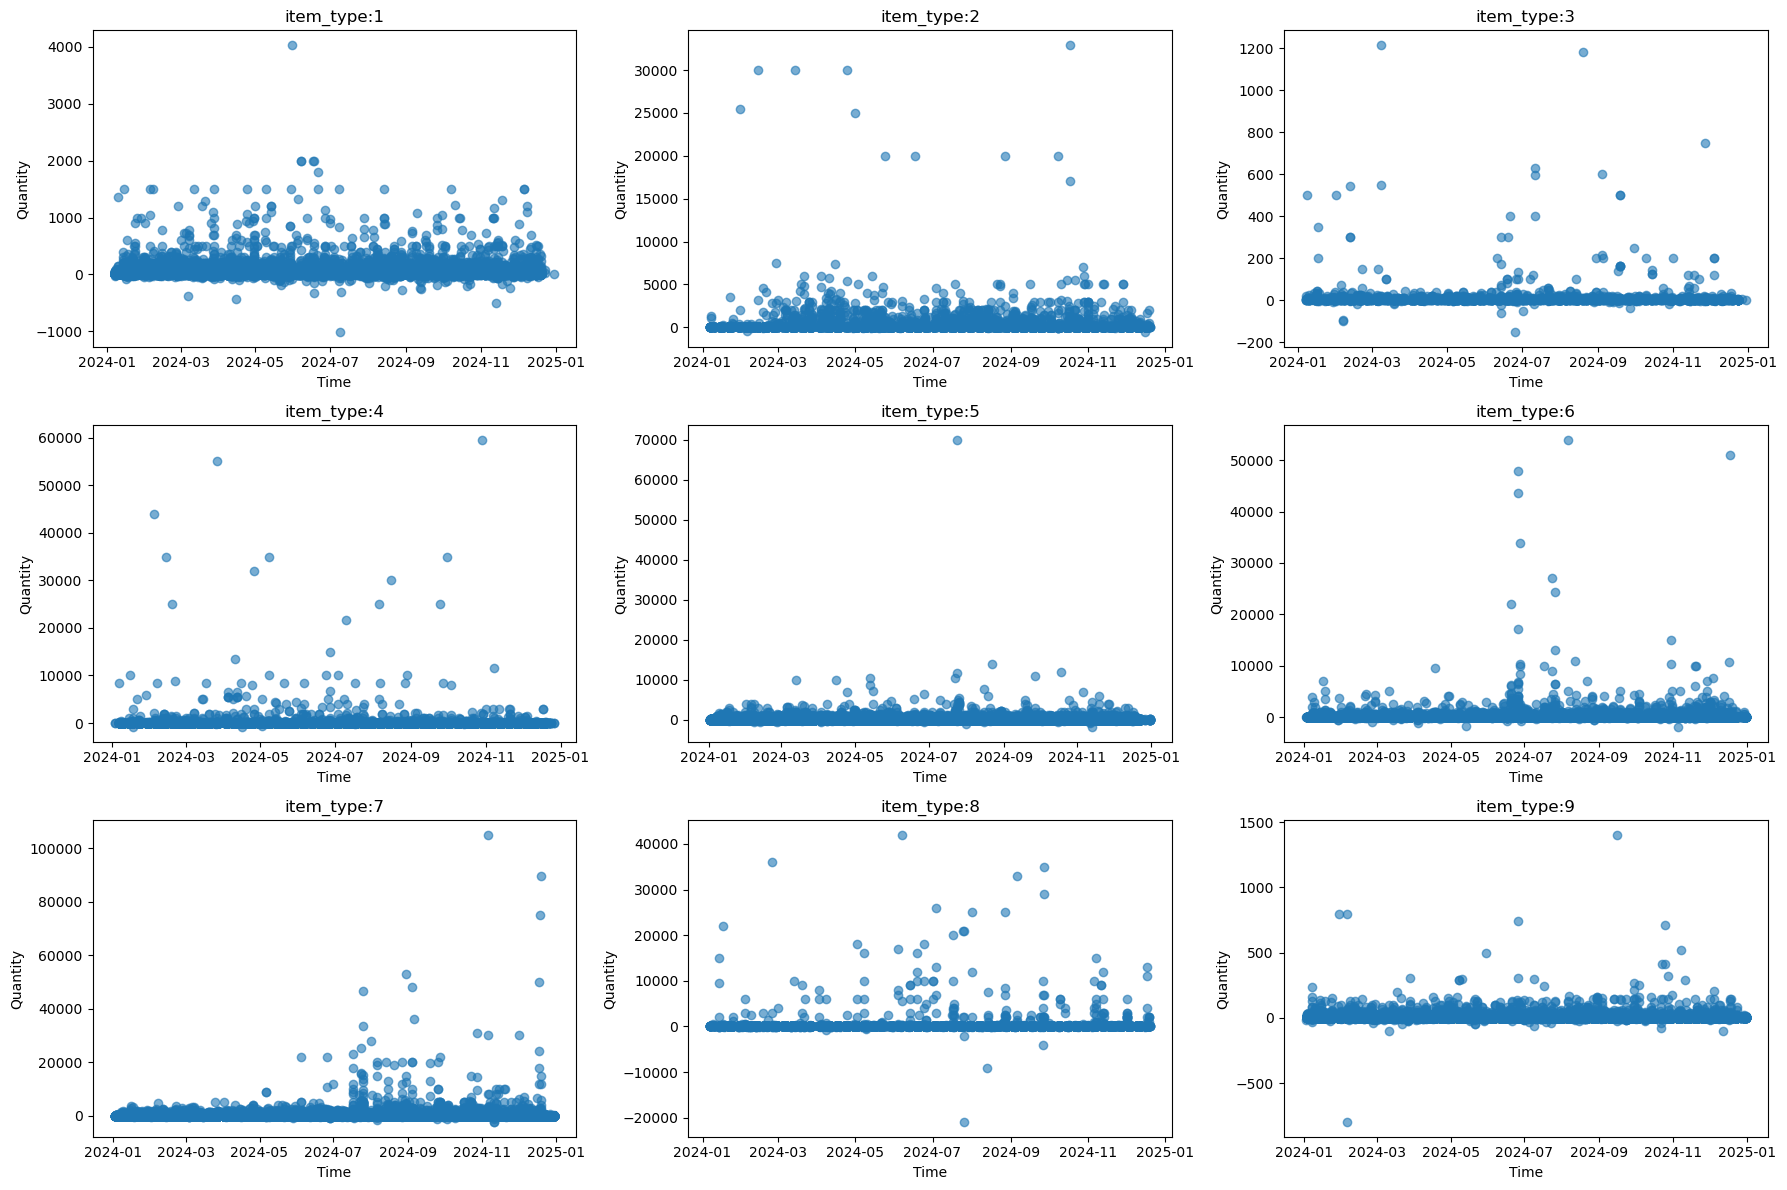

In [327]:
# to see the quantity over time

cat, x, y = 'item_type','accounting_date','value_quantity'
cats = sorted(df_2024[cat].unique())
n = len(cats)

ncols = 3
nrows = -(-n // ncols)

plt.figure(figsize = (6 * ncols, 4 * nrows))

for i, c in enumerate(cats,1):
    subset = df_2024[df_2024[cat] == c]
    plt.subplot(nrows, ncols, i)
    plt.scatter(subset[x],subset[y],alpha = 0.6)
    plt.title(f"{cat}:{c}")
    plt.xlabel("Time")
    plt.ylabel("Quantity")
    
plt.tight_layout()
plt.show()

##### Boxplot

/var/folders/c6/xxws1v553296lnd2hthddtqh0000gn/T/ipykernel_26791/3819835914.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data ,labels = cats, showfliers=True, whis=1.5)


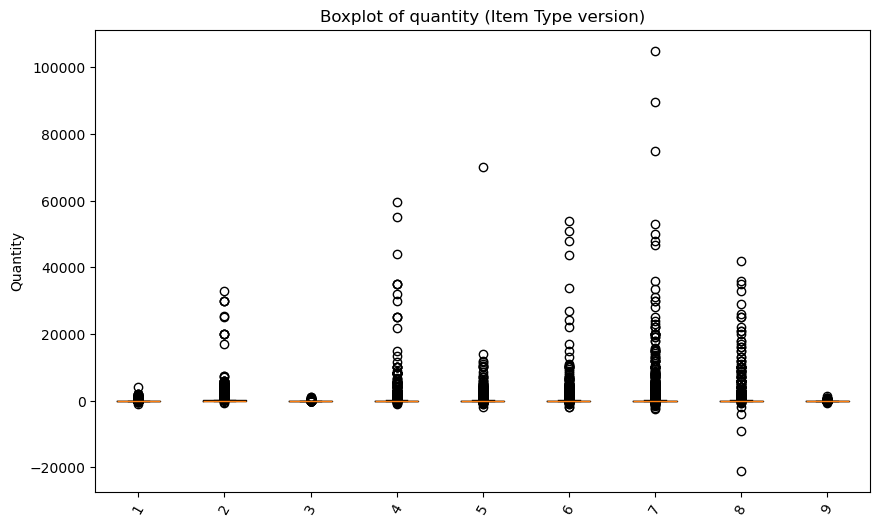

In [329]:
cat, val = 'item_type','value_quantity'
cats = sorted(df_2024[cat].unique())

data = [df_2024.loc[df_2024[cat].eq(c),val].values for c in cats]

plt.figure(figsize=(10,6))

plt.boxplot(data ,labels = cats, showfliers=True, whis=1.5)
plt.xticks(rotation=60)
plt.title('Boxplot of quantity (Item Type version)')
plt.ylabel('Quantity')

plt.show()

#### Outlier Removal - IQR method

In [331]:
#caluclate 25th percentile of transformed sales
percentile25 = df_2024.groupby("item_type")['value_quantity'].quantile(0.25)
print('percentile25:')
print(percentile25)
print()
#caluclate 75th percentile of transformed sales
percentile75 = df_2024.groupby("item_type")['value_quantity'].quantile(0.75)
print('percentile75:')
print(percentile75)
print()
#calculate the IQR
iqr = percentile75 - percentile25
print('IQR:')
print(iqr)
print()
#locate the limitation range 
upper_limit = percentile75 + 1.5 * iqr
lower_limit = percentile25 - 1.5 * iqr

print('upper limit:')
print(upper_limit)
print()
print('lower limit:')
print(lower_limit)

# save these values in new columns for further adjustemnts
df_2024["percentile25"] = df_2024['item_type'].map(percentile25)
df_2024["percentile75"] = df_2024['item_type'].map(percentile75)
df_2024["lower end"] = df_2024['item_type'].map(lower_limit)
df_2024["upper end"] = df_2024['item_type'].map(upper_limit)

percentile25:
item_type
1    2.0
2    2.0
3    1.0
4    2.0
5    3.0
6    2.0
7    2.0
8    1.0
9    2.0
Name: value_quantity, dtype: float64

percentile75:
item_type
1     12.0
2    120.0
3      8.0
4     16.0
5     20.0
6     20.0
7     20.0
8     14.0
9      8.0
Name: value_quantity, dtype: float64

IQR:
item_type
1     10.0
2    118.0
3      7.0
4     14.0
5     17.0
6     18.0
7     18.0
8     13.0
9      6.0
Name: value_quantity, dtype: float64

upper limit:
item_type
1     27.0
2    297.0
3     18.5
4     37.0
5     45.5
6     47.0
7     47.0
8     33.5
9     17.0
Name: value_quantity, dtype: float64

lower limit:
item_type
1    -13.0
2   -175.0
3     -9.5
4    -19.0
5    -22.5
6    -25.0
7    -25.0
8    -18.5
9     -7.0
Name: value_quantity, dtype: float64


In [332]:
#isolate outliers on low end by group
sales_lower = df_2024[df_2024['value_quantity'] < df_2024['item_type'].map(lower_limit)]
#isolate outliers on upper end by group
sales_upper = df_2024[df_2024['value_quantity'] > df_2024['item_type'].map(upper_limit)]
#locate the medium sales for each type
median_sales = df_2024.groupby('item_type')['value_quantity'].median()
# create a new column to save the median value for each categories
df_2024["median_quantity"] = df_2024.groupby("item_type")["value_quantity"].transform("median")
# create other columns to save the transformed replaced value 
df_2024['quantity outlier'] = ~df_2024["value_quantity"].between(df_2024['lower end'], df_2024['upper end'], inclusive='both')
df_2024['value_quantity_fixed'] = df_2024['value_quantity'].mask(df_2024['quantity outlier'],df_2024['median_cost'])
df_2024[['item_type','value_quantity','median_quantity','quantity outlier', 'value_quantity_fixed']]

,item_type,value_quantity,median_quantity,quantity outlier,value_quantity_fixed
5,5,3.0,9.0,False,3.0000
6,5,1.0,9.0,False,1.0000
28,5,51.0,9.0,True,35.3356
29,5,10.0,9.0,False,10.0000
30,5,10.0,9.0,False,10.0000
...,...,...,...,...,...
951172,5,8.0,9.0,False,8.0000
951173,1,5.0,4.0,False,5.0000
951174,6,31.0,7.0,False,31.0000
951175,5,1.0,9.0,False,1.0000


/var/folders/c6/xxws1v553296lnd2hthddtqh0000gn/T/ipykernel_26791/462697646.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_bf ,labels = order, vert=False, showfliers=True, whis=1.5)
/var/folders/c6/xxws1v553296lnd2hthddtqh0000gn/T/ipykernel_26791/462697646.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_af ,labels = order, vert=False, showfliers=True, whis=1.5)


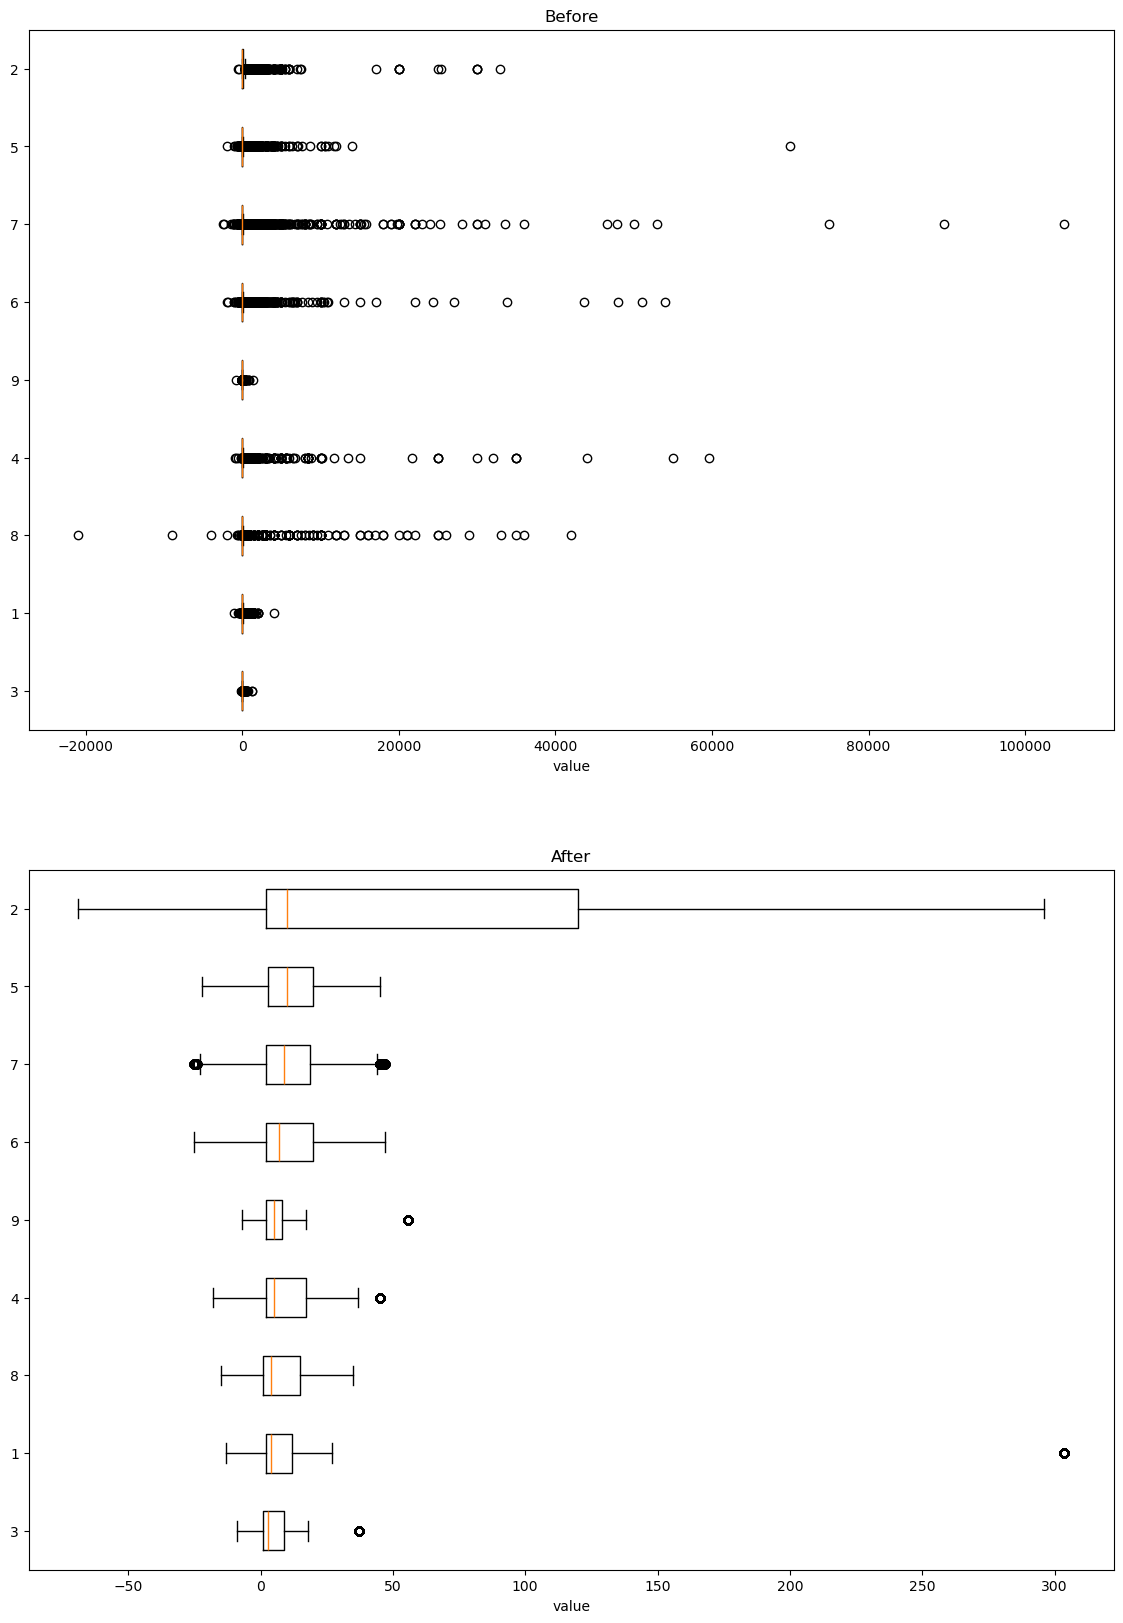

In [333]:
# review the result of outlier fixing  

#boxplot
cat, before, after = 'item_type', 'value_quantity', 'value_quantity_fixed'

order = (df_2024.groupby(cat)[before].median().sort_values().index)

data_bf = [df_2024.loc[df_2024[cat].eq(c),before].values for c in order]
data_af = [df_2024.loc[df_2024[cat].eq(c),after].values for c in order]

plt.figure(figsize=(14, 20))

plt.subplot(2,1,1)
plt.boxplot(data_bf ,labels = order, vert=False, showfliers=True, whis=1.5)
plt.title ('Before')
plt.xlabel('value')

plt.subplot(2,1,2)
plt.boxplot(data_af ,labels = order, vert=False, showfliers=True, whis=1.5)
plt.title ('After')
plt.xlabel('value')


plt.show()

#### Transformation

##### Histogram

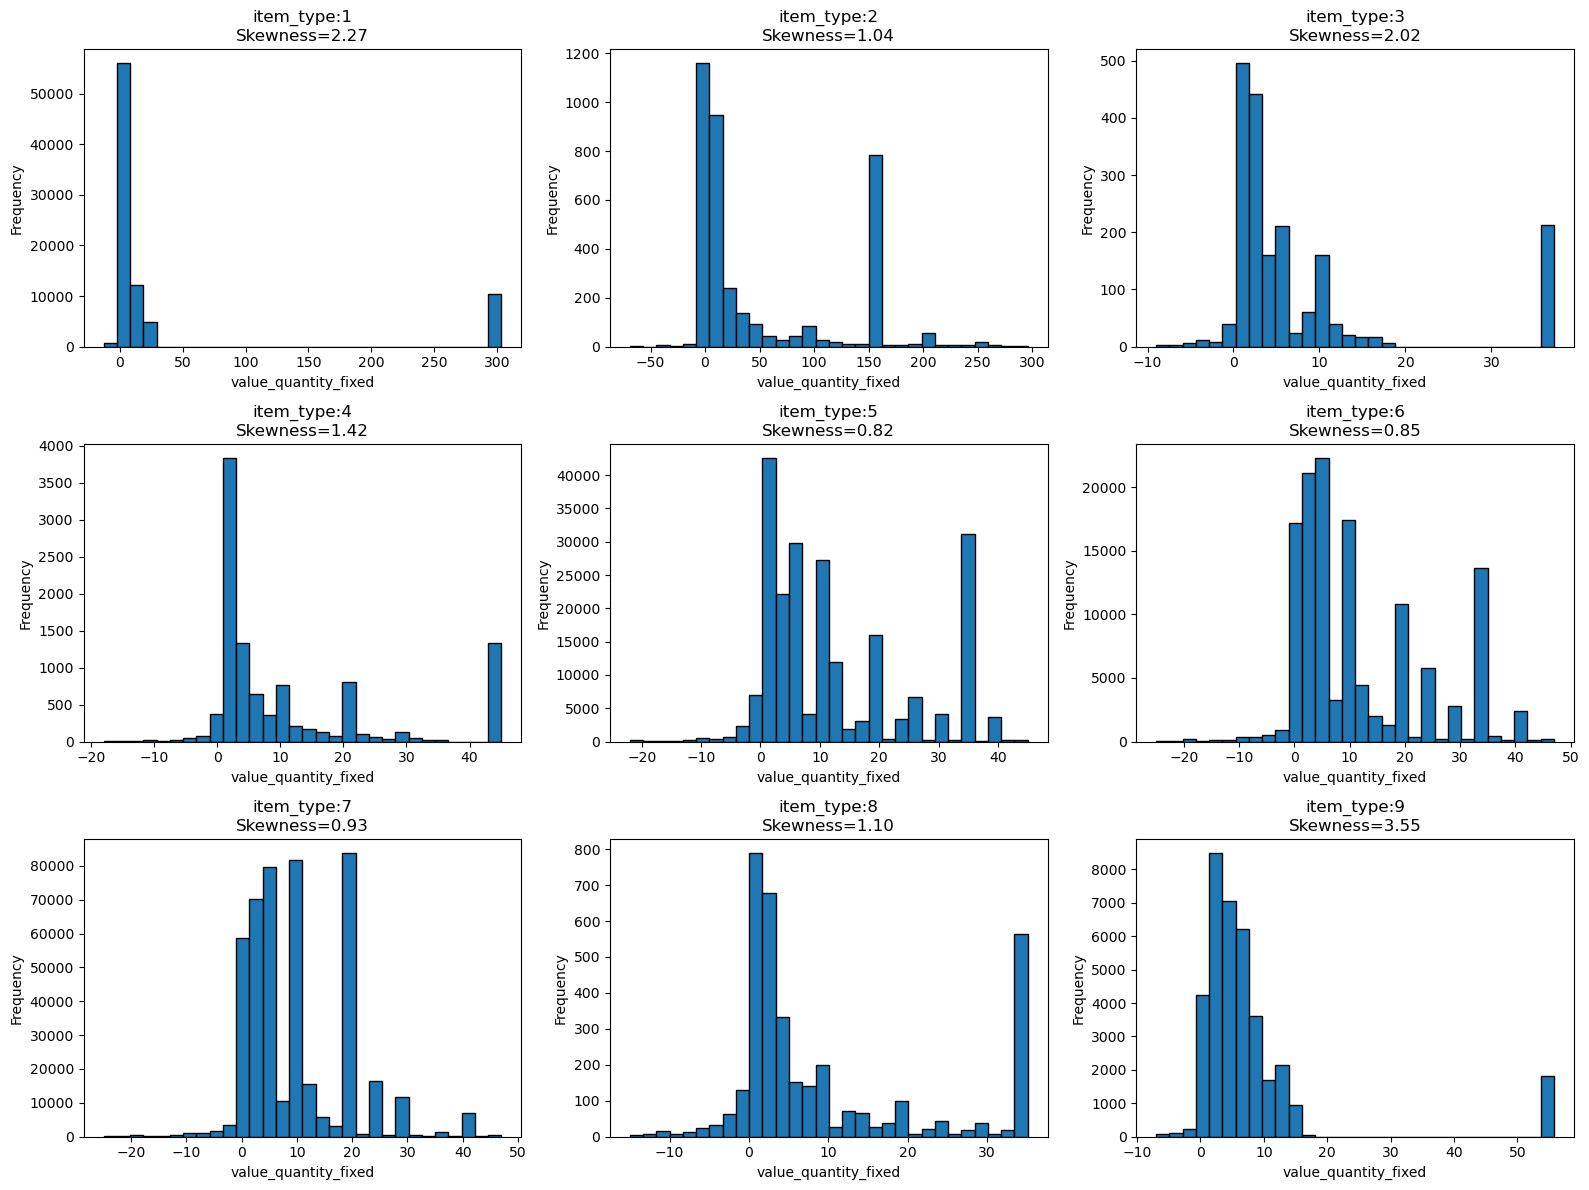

item_type
1    2.197354
2    1.905231
3    1.666056
4    1.111812
5    0.946189
6    0.942879
7    0.935881
8    0.777278
9    3.316941
Name: value_quantity_fixed, dtype: float64


In [336]:
# visualization on skewness
cat, col = 'item_type','value_quantity_fixed'
cats = sorted(df_2024[cat].unique())

nrows, ncols = 3,3
plt.figure(figsize=(16, 12))

for i,c in enumerate(cats[:nrows * ncols], 1):
    plt.subplot(nrows,ncols,i)
    data = df_2024.loc[df_2024[cat] == c, 'value_quantity_fixed']
    skew_val = data.skew()
    plt.hist(data,bins=30,edgecolor='black')
    plt.title(f'{cat}:{c}\nSkewness={skew_val:.2f}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

# skewness list
skew_by_cat = df_2023.groupby(cat)[col].skew()
print(skew_by_cat)

##### Signed log

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


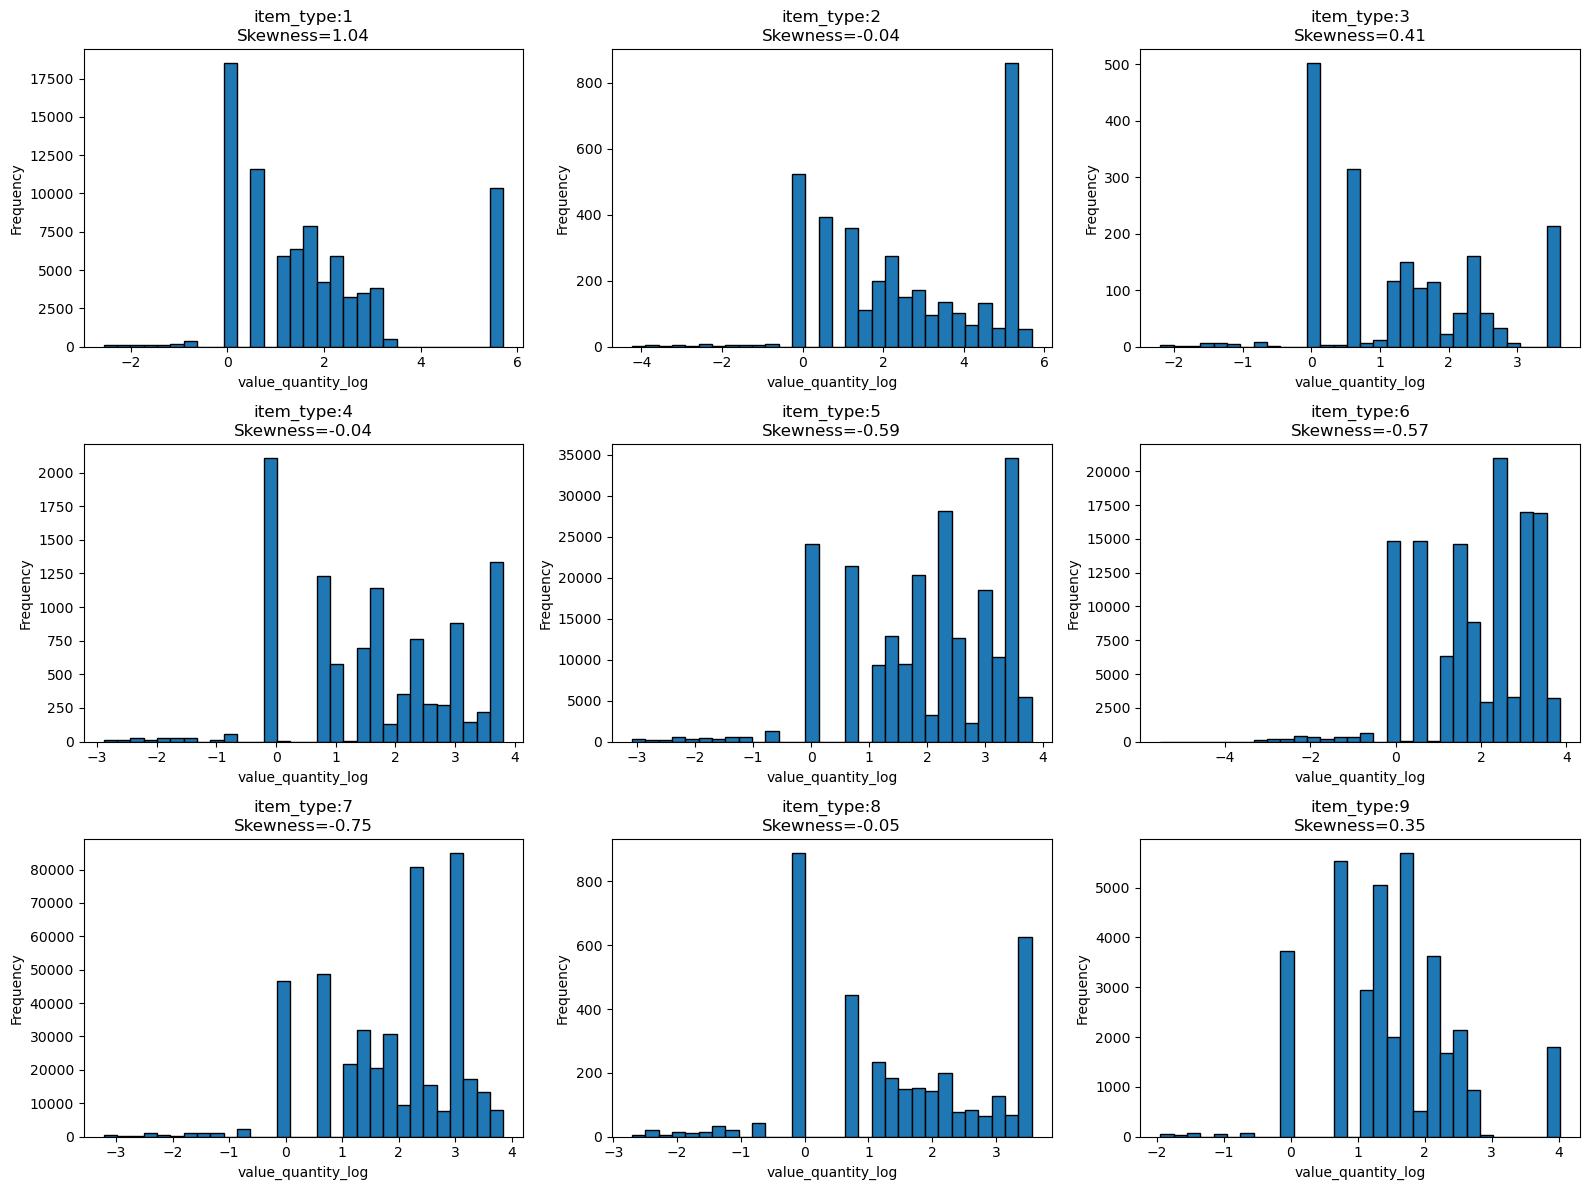

item_type
1    1.044043
2   -0.037661
3    0.407256
4   -0.043536
5   -0.588505
6   -0.565207
7   -0.752596
8   -0.049131
9    0.345676
Name: value_quantity_log, dtype: float64


In [338]:
# signed log transforming
df_2024['value_quantity_log'] = signed_log(df_2024['value_quantity_fixed'])

# visualization on skewness
cat1, col1 = 'item_type','value_quantity_log'
cats1 = sorted(df_2024[cat1].unique())

nrows, ncols = 3,3
plt.figure(figsize=(16, 12))

for i,c in enumerate(cats1[:nrows * ncols], 1):
    plt.subplot(nrows,ncols,i)
    data = df_2024.loc[df_2024[cat1] == c, 'value_quantity_log']
    skew_val = data.skew()
    plt.hist(data,bins=30,edgecolor='black')
    plt.title(f'{cat1}:{c}\nSkewness={skew_val:.2f}')
    plt.xlabel(col1)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

# list the skewness
skew_by_cat = df_2024.groupby(cat1)[col1].skew()
print(skew_by_cat)

##### Square Root

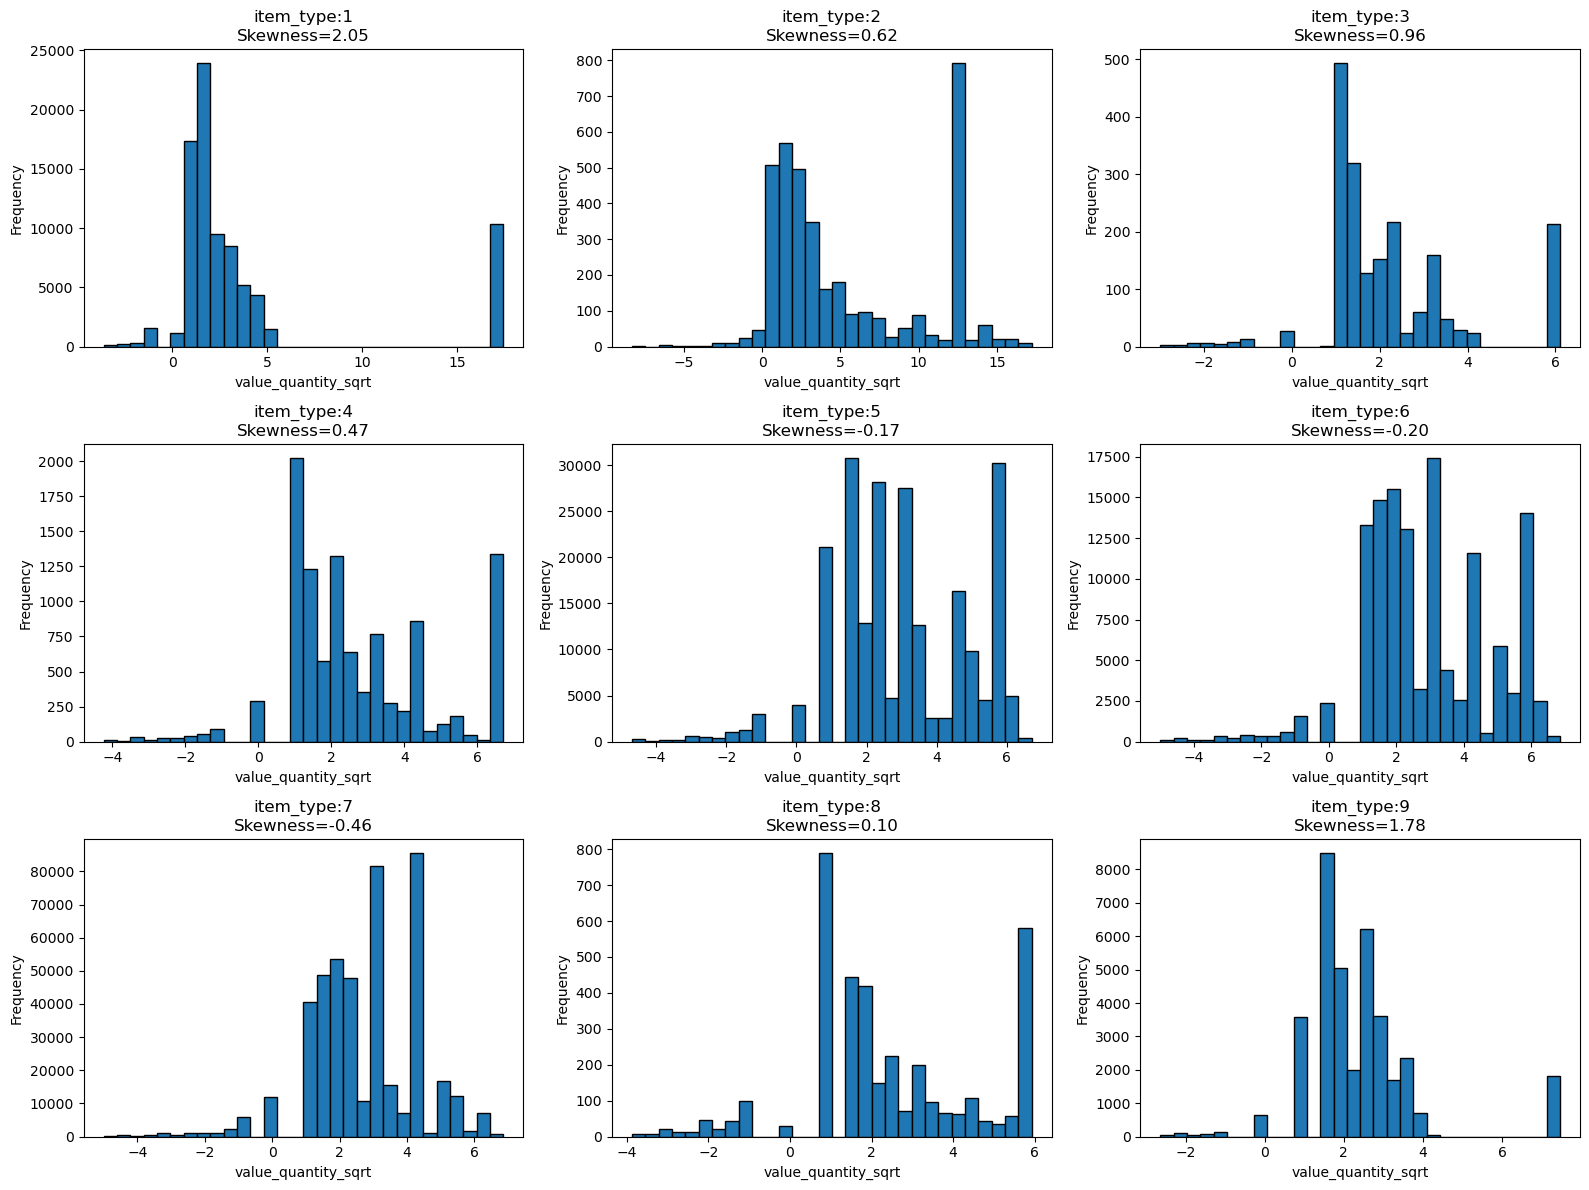

item_type
1    2.054069
2    0.623227
3    0.955240
4    0.470069
5   -0.171862
6   -0.203563
7   -0.461281
8    0.098389
9    1.781062
Name: value_quantity_sqrt, dtype: float64


In [340]:
# transforming by square root
df_2024['value_quantity_sqrt'] = signed_sqrt(df_2024['value_quantity_fixed'])

# visualization on skewness
cat2, col2 = 'item_type','value_quantity_sqrt'
cats2 = sorted(df_2024[cat2].unique())

nrows, ncols = 3,3
plt.figure(figsize=(16, 12))

for i,c in enumerate(cats2[:nrows * ncols], 1):
    plt.subplot(nrows,ncols,i)
    data = df_2024.loc[df_2024[cat2] == c, 'value_quantity_sqrt']
    skew_val = data.skew()
    plt.hist(data,bins=30,edgecolor='black')
    plt.title(f'{cat2}:{c}\nSkewness={skew_val:.2f}')
    plt.xlabel(col2)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

# list the skewness
skew_by_cat = df_2024.groupby(cat2)[col2].skew()
print(skew_by_cat)

##### Yeo-Johnson 

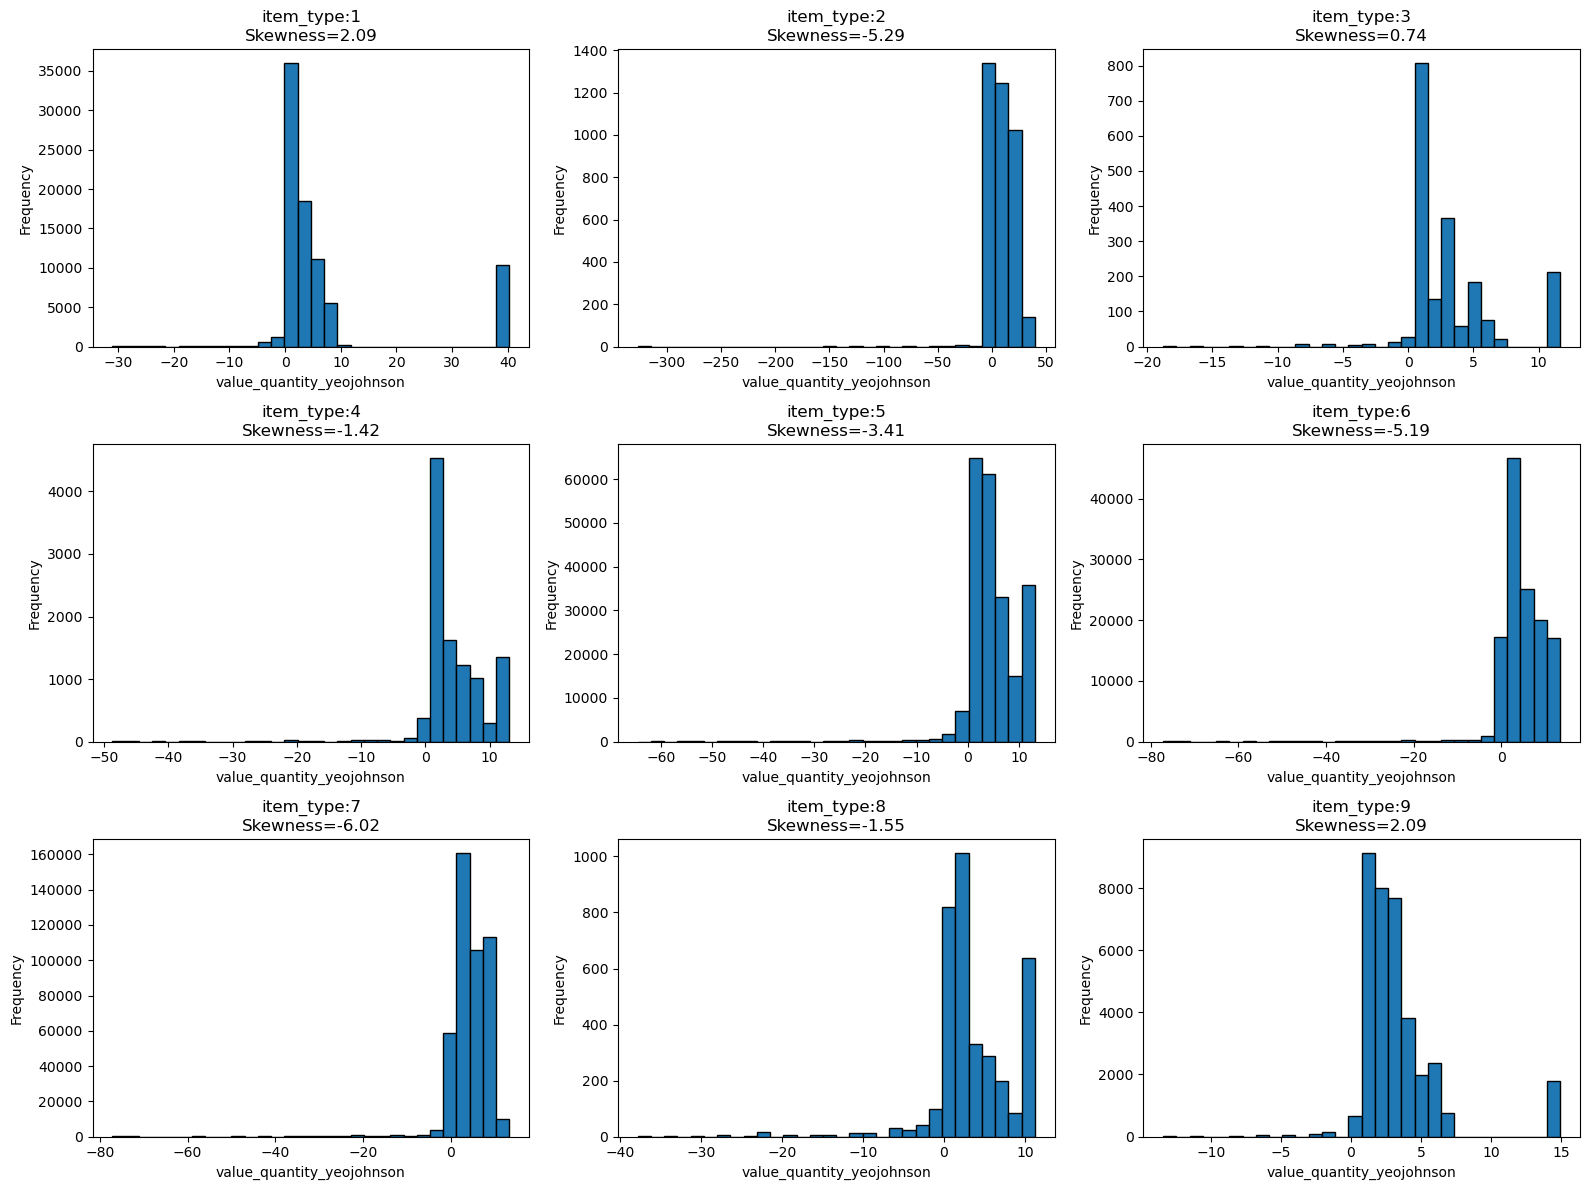

item_type
1    2.087012
2   -5.293145
3    0.740158
4   -1.424890
5   -3.409440
6   -5.186946
7   -6.023444
8   -1.551431
9    2.090001
Name: value_quantity_yeojohnson, dtype: float64


In [342]:
df_2024['value_quantity_yeojohnson'] = pt.fit_transform(df_2024[['value_quantity_fixed']])

# visualization on skewness
cat3, col3 = 'item_type','value_quantity_yeojohnson'
cats3 = sorted(df_2024[cat3].unique())

nrows, ncols = 3,3
plt.figure(figsize=(16, 12))

for i,c in enumerate(cats3[:nrows * ncols], 1):
    plt.subplot(nrows,ncols,i)
    data = df_2024.loc[df_2024[cat3] == c, 'value_quantity_yeojohnson']
    skew_val = data.skew()
    plt.hist(data,bins=30,edgecolor='black')
    plt.title(f'{cat3}:{c}\nSkewness={skew_val:.2f}')
    plt.xlabel(col3)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

# list skewness
skew_by_cat = df_2024.groupby(cat3)[col3].skew()
print(skew_by_cat)

## Feature Engineering (New Variables)

### Total Revenue

* Column `value_price_adjustment` contain only binary values: 

    * **0:** no price adjustment (e.g., discount or surcharge) was apply
    
    * **1:**  discount or surcharge

So cannot calculate total revenue using `total_revenue = value_sales_aud + value_price_adjustment`

* Use `value_sales_aud` as `total_revenue` directly (because it already reflects the final amount after any adjustments)

#### Total Revenue 2023

In [346]:
df_2023['total_revenue'] = df_2023['value_sales_aud']
df_2023[['value_sales_aud', 'total_revenue']].head()

,value_sales_aud,total_revenue
9,-6.38,-6.38
10,19.14,19.14
11,439.18,439.18
13,229.68,229.68
14,20.10,20.10


#### Total Revenue 2024

In [348]:
df_2024['total_revenue'] = df_2024['value_sales_aud']
df_2024[['value_sales_aud', 'total_revenue']].head()

,value_sales_aud,total_revenue
5,22.5,22.5
6,7.5,7.5
28,122.4,122.4
29,24.0,24.0
30,24.0,24.0


### Profit

`profit = value_sales_aud - value_cost_aud`

#### Profit 2023

In [351]:
df_2023['profit'] = df_2023['value_sales_aud'] - df_2023['value_cost_aud']

df_2023[['value_sales_aud', 'value_cost_aud', 'profit']].head()

,value_sales_aud,value_cost_aud,profit
9,-6.38,-4.2428,-2.1372
10,19.14,12.7284,6.4116
11,439.18,292.7532,146.4268
13,229.68,152.7408,76.9392
14,20.10,12.7284,7.3716


#### Profit 2024

In [353]:
df_2024['profit'] = df_2024['value_sales_aud'] - df_2024['value_cost_aud']

df_2024[['value_sales_aud', 'value_cost_aud', 'profit']].head()

,value_sales_aud,value_cost_aud,profit
5,22.5,14.0700,8.4300
6,7.5,4.6900,2.8100
28,122.4,44.7015,77.6985
29,24.0,7.8190,16.1810
30,24.0,7.8190,16.1810


### Profit Margin

**Reason for assign `NaN` only when `value_sales` == 0**:

* **1. To avoide divide by zero:** Since `profit_margin` is calculated as:
    `profit_margin = (value_sales_aud - value_cost_aud) / value_sales_aud`

-> dividing by zero would raise an error or produce meaningless values. So, when `value_sales_aud == 0`, it’s safer and more appropriate to assign `NaN`.

* **2. No business meaning when sales = 0:** If there’s no revenue (`value_sales_aud = 0`), calculating a margin doesn’t make sense. There’s no sale, so the margin is undefined.

* **3. Cost = 0 still has meaning:** 
    * If `value_cost_aud == 0` but there is a sale, this might represent valid business scenarios, such as:
        * Free goods from suppliers (e.g., marketing promotions) 
        * Fully depreciated stock.
        * Accounting lags (cost not recorded yet).
    * These transactions result in a 100% profit margin, which is not incorrect from a calculation perspective.
* **4. Don’t want to throw away useful data:** If you also assign NaN when `value_cost_aud == 0`, you’ll remove potentially valuable rows that could highlight interesting patterns like very high-margin sales, zero-cost samples, or promotion campaigns.

* **5. More flexible for later analysis:** If needed, you can always flag or filter out `value_cost_aud == 0` later when analyzing outliers or building models—but keeping the data for now retains maximum flexibility.

#### Profit Margin 2023

In [357]:
df_2023['profit_margin'] = np.where(
    df_2023['value_sales_aud'] == 0,
    np.nan,
    (df_2023['value_sales_aud'] - df_2023['value_cost_aud']) / df_2023['value_sales_aud']
)

df_2023[['value_sales_aud', 'value_cost_aud', 'profit_margin']].head()

,value_sales_aud,value_cost_aud,profit_margin
9,-6.38,-4.2428,0.334984
10,19.14,12.7284,0.334984
11,439.18,292.7532,0.333410
13,229.68,152.7408,0.334984
14,20.10,12.7284,0.366746


#### Profit Margin 2024

In [359]:
df_2024['profit_margin'] = np.where(
    df_2024['value_sales_aud'] == 0,
    np.nan,
    (df_2024['value_sales_aud'] - df_2024['value_cost_aud']) / df_2024['value_sales_aud']
)

df_2024[['value_sales_aud', 'value_cost_aud', 'profit_margin']].head()

,value_sales_aud,value_cost_aud,profit_margin
5,22.5,14.0700,0.374667
6,7.5,4.6900,0.374667
28,122.4,44.7015,0.634792
29,24.0,7.8190,0.674208
30,24.0,7.8190,0.674208


### Unit Price

`unit_price = value_sales_aud / value_quantity`

#### Unit Price 2023

In [362]:
df_2023['unit_price'] = np.where(
    df_2023['value_quantity'] == 0,
    np.nan,
    df_2023['value_sales_aud'] / df_2023['value_quantity']
)

df_2023[['value_sales_aud', 'value_quantity', 'unit_price']].head()

,value_sales_aud,value_quantity,unit_price
9,-6.38,-2.0,3.190000
10,19.14,6.0,3.190000
11,439.18,138.0,3.182464
13,229.68,72.0,3.190000
14,20.10,6.0,3.350000


#### Unit Price 2024

In [364]:
df_2024['unit_price'] = np.where(
    df_2024['value_quantity'] == 0,
    np.nan,
    df_2024['value_sales_aud'] / df_2024['value_quantity']
)

df_2024[['value_sales_aud', 'value_quantity', 'unit_price']].head()

,value_sales_aud,value_quantity,unit_price
5,22.5,3.0,7.5
6,7.5,1.0,7.5
28,122.4,51.0,2.4
29,24.0,10.0,2.4
30,24.0,10.0,2.4


### Order Month

`order_month = month from order_date` -> seasonality research

#### Order Month 2023

In [367]:
df_2023['order_month'] = df_2023['order_date'].dt.month

df_2023[['order_date', 'order_month']].head()

,order_date,order_month
9,2023-02-02,2
10,2023-03-01,3
11,2023-04-27,4
13,2023-01-11,1
14,2023-06-05,6


#### Order Month 2024

In [369]:
df_2024['order_month'] = df_2024['order_date'].dt.month

df_2024[['order_date', 'order_month']].head()

,order_date,order_month
5,2024-03-27,3
6,2024-03-05,3
28,2024-03-15,3
29,2024-05-27,5
30,2024-05-06,5


### Days to Invoice

`days_to_invoice = invoice_date – order_date`

#### Days to Invoice 2023

In [372]:
df_2023['days_to_invoice'] = (df_2023['invoice_date'] - df_2023['order_date']).dt.days

df_2023[['invoice_date', 'order_date', 'days_to_invoice']].head()

,invoice_date,order_date,days_to_invoice
9,2023-02-02,2023-02-02,0
10,2023-03-01,2023-03-01,0
11,2023-05-03,2023-04-27,6
13,2023-01-18,2023-01-11,7
14,2023-06-05,2023-06-05,0


#### Days to Invoice 2024

In [374]:
df_2024['days_to_invoice'] = (df_2024['invoice_date'] - df_2024['order_date']).dt.days

df_2024[['invoice_date', 'order_date', 'days_to_invoice']].head()

,invoice_date,order_date,days_to_invoice
5,2024-03-28,2024-03-27,1
6,2024-03-06,2024-03-05,1
28,2024-03-15,2024-03-15,0
29,2024-05-27,2024-05-27,0
30,2024-05-06,2024-05-06,0


## Outliers & Handle Outliers

### Outliers & Handle Outliers 2023

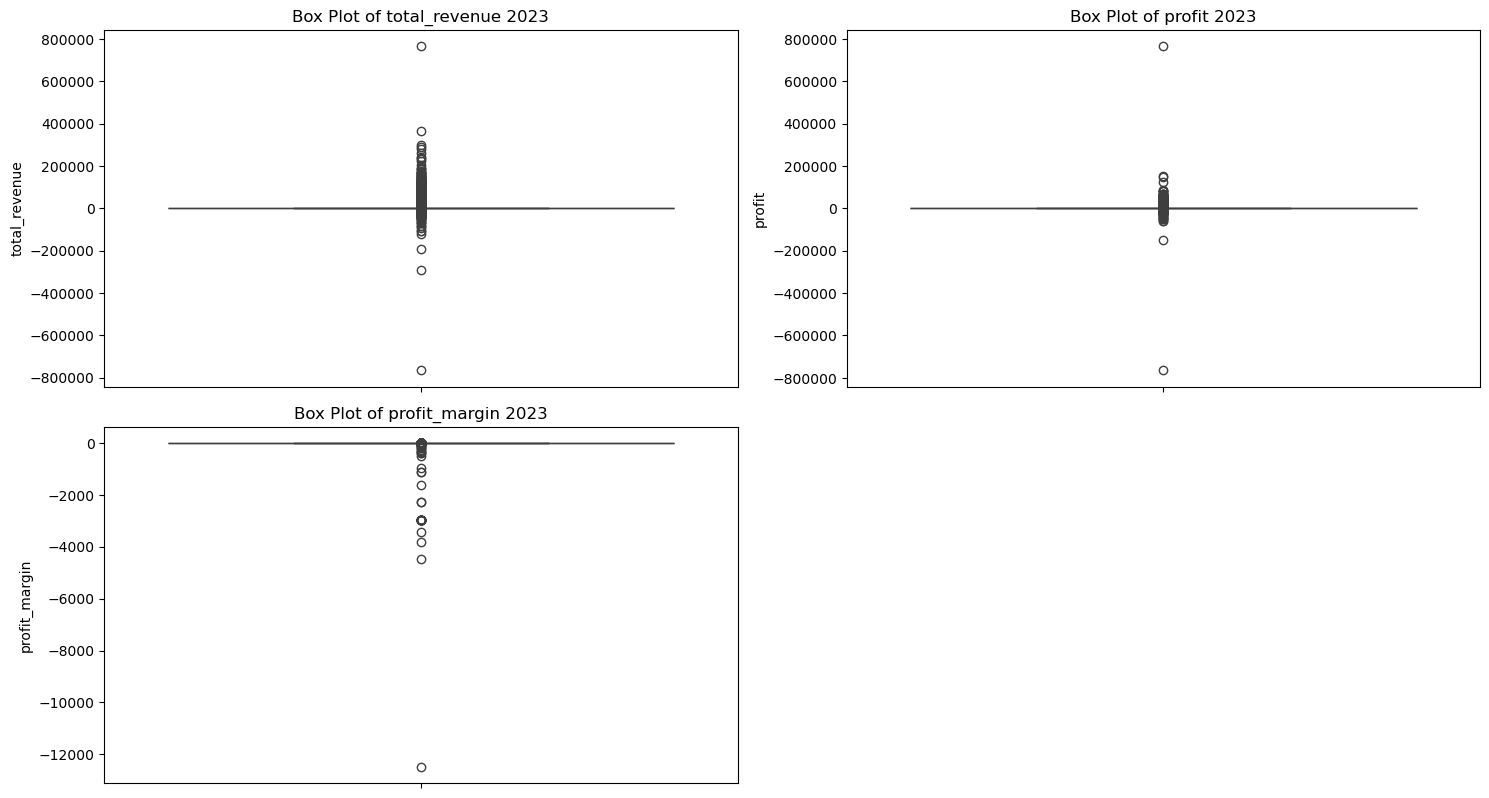

In [377]:
columns_to_plot = ['total_revenue', 'profit', 'profit_margin']
plt.figure(figsize=(15, 12))
for i, column in enumerate(columns_to_plot, 1):
    plt.subplot(3, 2, i)
    sns.boxplot(data=df_2023, y = column)
    plt.title(f'Box Plot of {column} 2023')
plt.tight_layout()
plt.show()

In [378]:
# Fix Outliers with Median
def fix_outliers(column_name, verbose=True):
    
    percentile25 = df_2023[column_name].quantile(0.25)
    percentile75 = df_2023[column_name].quantile(0.75)

    iqr = percentile75 - percentile25

    upper_limit = percentile75 + 1.5 * iqr
    lower_limit = percentile25 - 1.5 * iqr

    print(f'Upper limit for {column_name} is: {upper_limit}')
    print(f'Lower limit for {column_name} is: {lower_limit}')

    median_value = df_2023[column_name].median()

    outliers = ((df_2023[column_name] < lower_limit) | (df_2023[column_name] > upper_limit)).sum()

    df_2023[column_name] = df_2023[column_name].mask(df_2023[column_name] < lower_limit, median_value)
    df_2023[column_name] = df_2023[column_name].mask(df_2023[column_name] > upper_limit, median_value)
    
    if verbose:
        print(f"[{column_name}] Lower: {lower_limit:.2f}, Upper: {upper_limit:.2f}, Median: {median_value:.2f}")
        print(f"→ Replaced {outliers} outliers with median\n")

columns_to_fix = ['total_revenue', 'profit', 'profit_margin']

for col in columns_to_fix:
    fix_outliers(col, verbose=True)

Upper limit for total_revenue is: 456.25
Lower limit for total_revenue is: -237.75
[total_revenue] Lower: -237.75, Upper: 456.25, Median: 65.80
→ Replaced 126000 outliers with median

Upper limit for profit is: 203.89399999999995
Lower limit for profit is: -104.57159999999998
[profit] Lower: -104.57, Upper: 203.89, Median: 31.48
→ Replaced 120051 outliers with median

Upper limit for profit_margin is: 0.9316576168731932
Lower limit for profit_margin is: 0.10784336581740533
[profit_margin] Lower: 0.11, Upper: 0.93, Median: 0.51
→ Replaced 60720 outliers with median



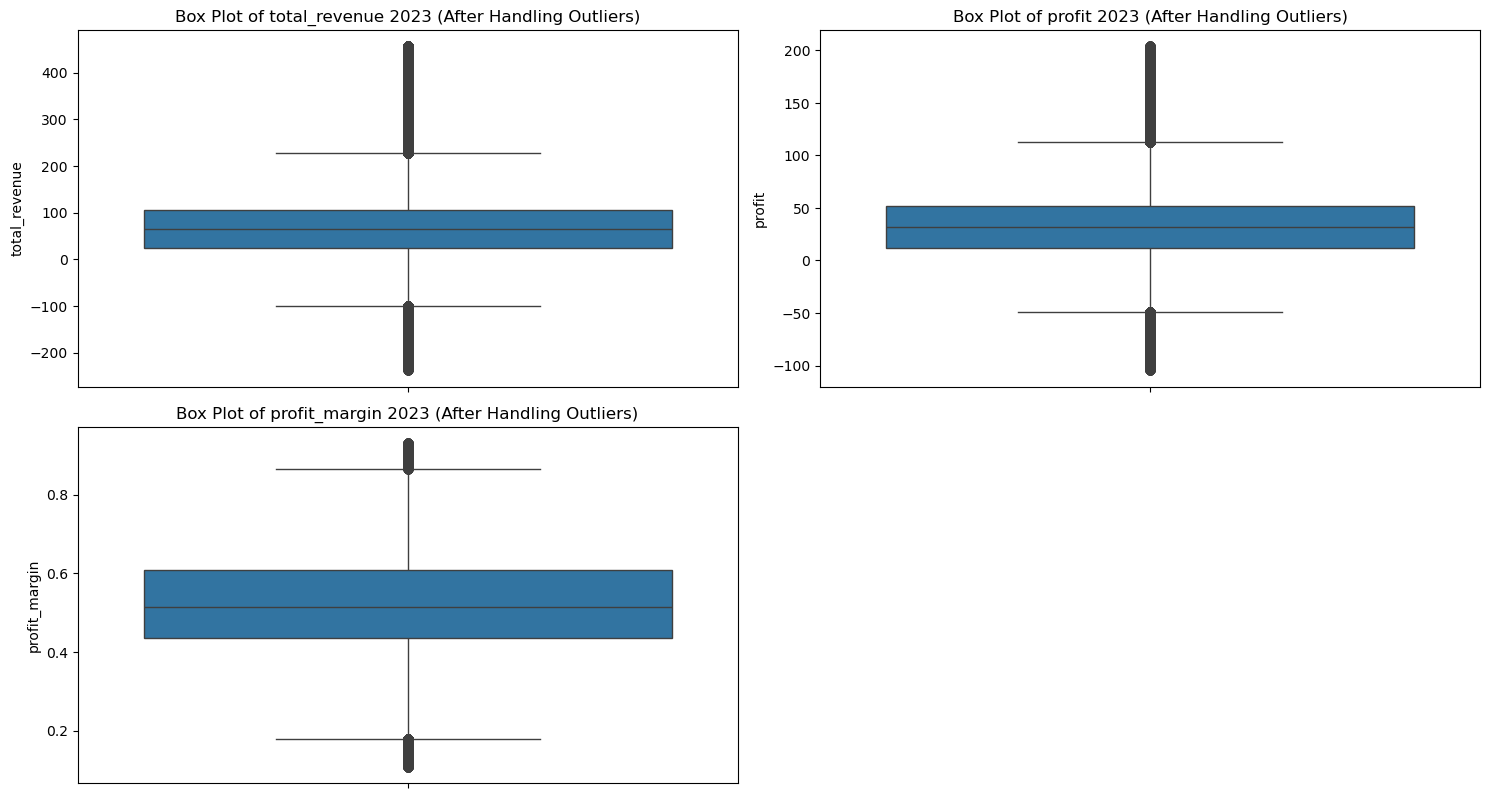

In [379]:
columns_to_plot = ['total_revenue', 'profit', 'profit_margin']
plt.figure(figsize=(15, 12))
for i, column in enumerate(columns_to_plot, 1):
    plt.subplot(3, 2, i)
    sns.boxplot(data=df_2023, y = column)
    plt.title(f'Box Plot of {column} 2023 (After Handling Outliers)')
plt.tight_layout()
plt.show()

### Outliers & Handle Outliers 2024

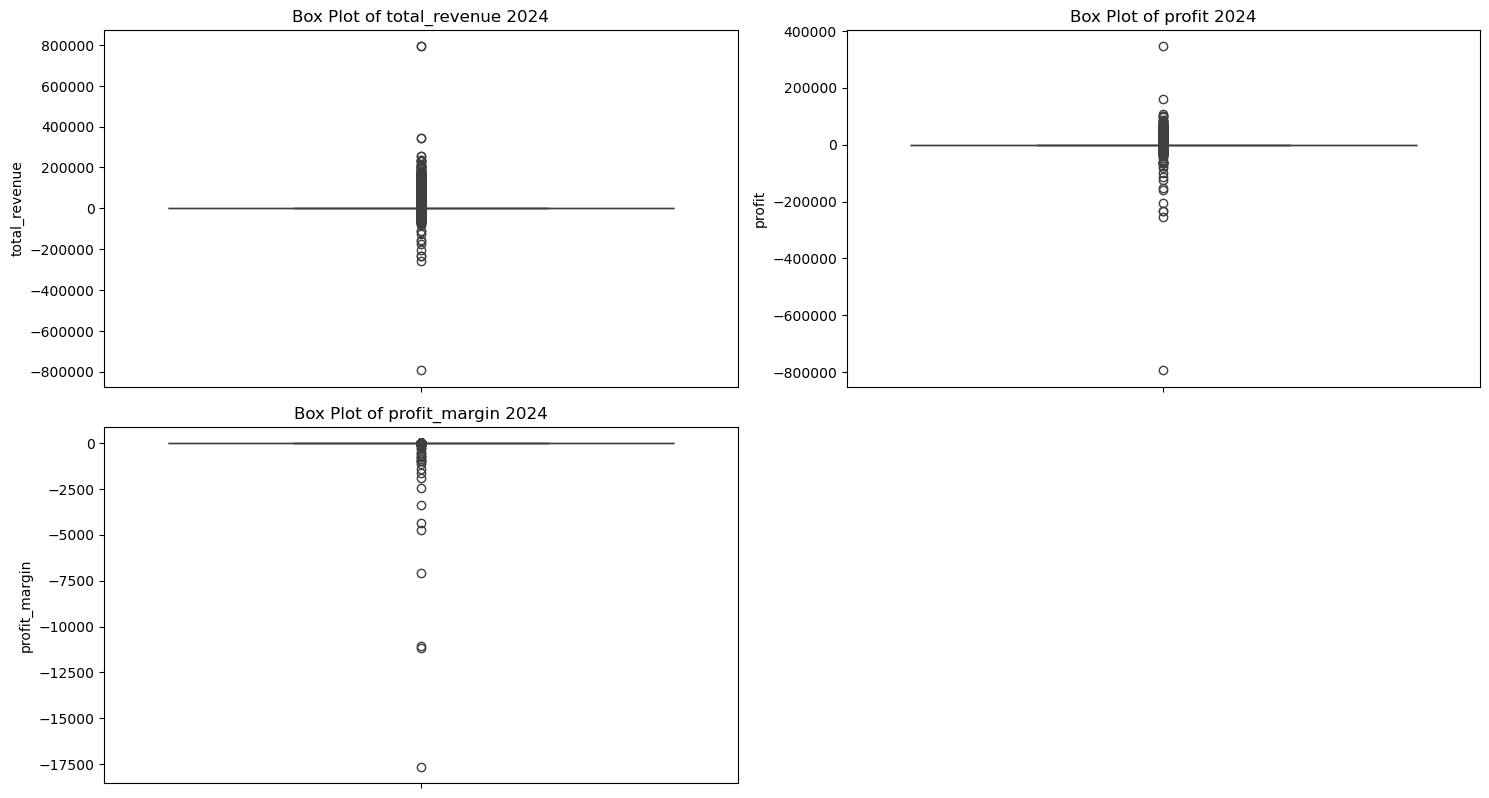

In [381]:
columns_to_plot = ['total_revenue', 'profit', 'profit_margin']
plt.figure(figsize=(15, 12))
for i, column in enumerate(columns_to_plot, 1):
    plt.subplot(3, 2, i)
    sns.boxplot(data=df_2024, y = column)
    plt.title(f'Box Plot of {column} 2024')
plt.tight_layout()
plt.show()

In [382]:
# Fix Outliers with Median
def fix_outliers(column_name, verbose=True):
    
    percentile25 = df_2024[column_name].quantile(0.25)
    percentile75 = df_2024[column_name].quantile(0.75)

    iqr = percentile75 - percentile25

    upper_limit = percentile75 + 1.5 * iqr
    lower_limit = percentile25 - 1.5 * iqr

    print(f'Upper limit for {column_name} is: {upper_limit}')
    print(f'Lower limit for {column_name} is: {lower_limit}')

    median_value = df_2024[column_name].median()

    outliers = ((df_2024[column_name] < lower_limit) | (df_2024[column_name] > upper_limit)).sum()

    df_2024[column_name] = df_2024[column_name].mask(df_2024[column_name] < lower_limit, median_value)
    df_2024[column_name] = df_2024[column_name].mask(df_2024[column_name] > upper_limit, median_value)
    
    if verbose:
        print(f"[{column_name}] Lower: {lower_limit:.2f}, Upper: {upper_limit:.2f}, Median: {median_value:.2f}")
        print(f"→ Replaced {outliers} outliers with median\n")

columns_to_fix = ['total_revenue', 'profit', 'profit_margin']

for col in columns_to_fix:
    fix_outliers(col, verbose=True)

Upper limit for total_revenue is: 462.70000000000005
Lower limit for total_revenue is: -240.50000000000006
[total_revenue] Lower: -240.50, Upper: 462.70, Median: 67.80
→ Replaced 131212 outliers with median

Upper limit for profit is: 203.24079999999998
Lower limit for profit is: -103.988
[profit] Lower: -103.99, Upper: 203.24, Median: 31.78
→ Replaced 126218 outliers with median

Upper limit for profit_margin is: 0.9764430142605661
Lower limit for profit_margin is: 0.06285138648880001
[profit_margin] Lower: 0.06, Upper: 0.98, Median: 0.52
→ Replaced 52267 outliers with median



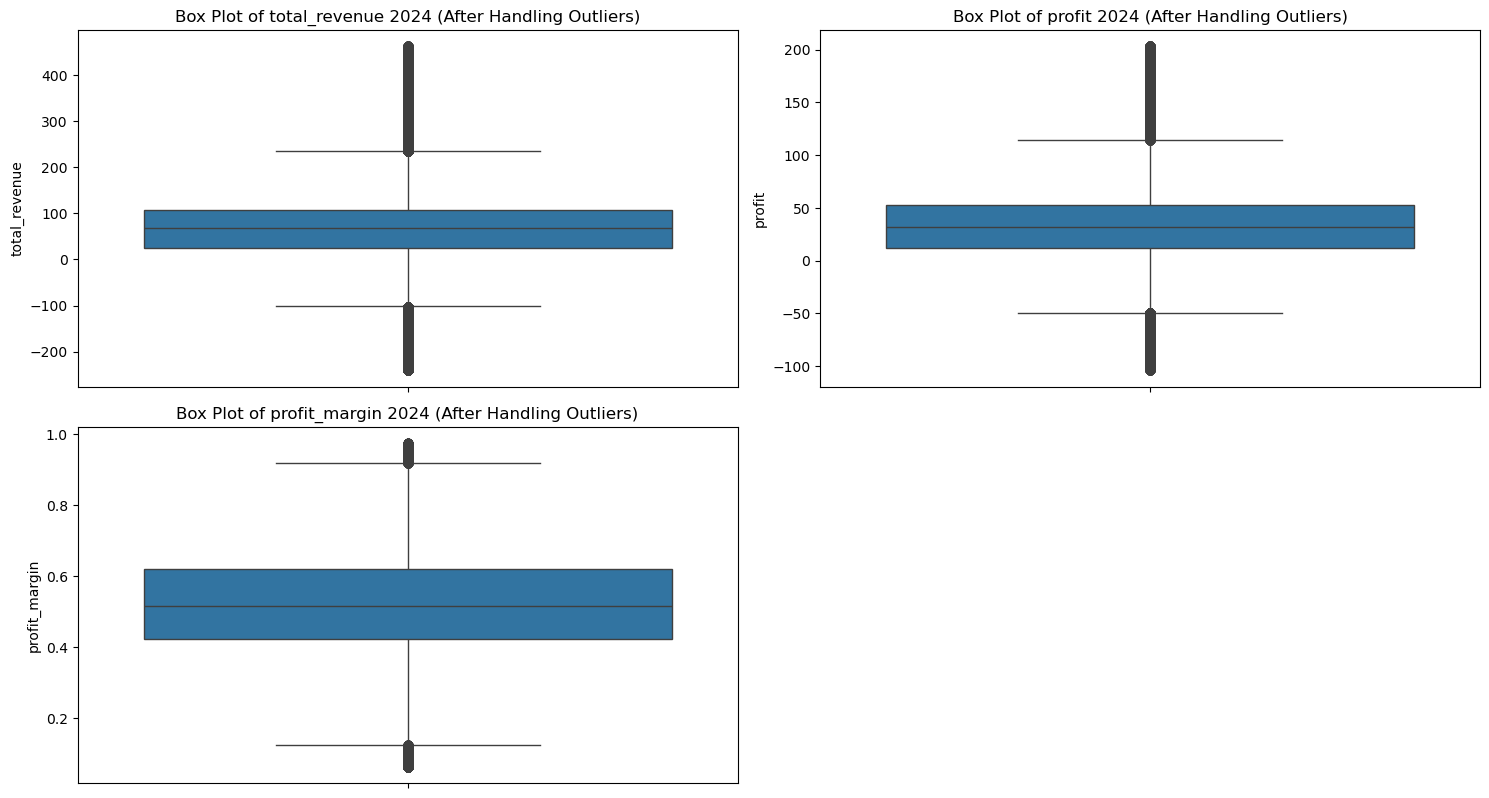

In [383]:
columns_to_plot = ['total_revenue', 'profit', 'profit_margin']
plt.figure(figsize=(15, 12))
for i, column in enumerate(columns_to_plot, 1):
    plt.subplot(3, 2, i)
    sns.boxplot(data=df_2024, y = column)
    plt.title(f'Box Plot of {column} 2024 (After Handling Outliers)')
plt.tight_layout()
plt.show()

## Skewness & Transformation 

**Filter value > 0 before skewness & transform (this file filter before transform)**

* `log(0)` and `sqrt(0)` can cause errors or not have much statistical significance.

* Box-Cox require data to be positive.

* Skewness is very sensitive to zero values → otherwise filtering will lead to false conclusions.

**Should we filter before outliers**

* Want to detect real anomalies in transactions with quantity/repinue > 0 -> should

* Want to find out if zero is abnormal? (E.g. system error, data entry error) -> shouldn't

In [386]:
cols = ['total_revenue', 'profit', 'profit_margin']

def classify_skew(x):
    if abs(x) <= 0.5:
        return '≈ Normal'
    elif abs(x) <= 1:
        return 'Mildly Skewed'
    else:
        return 'Highly Skewed'

skew_summary = {}

for year, df in {'2023': df_2023, '2024': df_2024}.items():
    skew = df[cols].skew().round(3)
    skew_summary[year] = skew

combined_skew_df = pd.DataFrame(skew_summary)

combined_skew_df['Skewness Range'] = combined_skew_df['2024'].apply(classify_skew)

display(combined_skew_df)

,2023,2024,Skewness Range
total_revenue,1.523,1.492,Highly Skewed
profit,1.314,1.277,Highly Skewed
profit_margin,0.037,-0.084,≈ Normal


In [387]:
# Check NaN, inf, -inf, zero in 'value_sales', 'value_cost', 'value_quantity', 'total_revenue', 'profit', 'profit_margin' columns
cols = ['total_revenue', 'profit', 'profit_margin']

dfs = {'2023': df_2023, '2024': df_2024}

summary = []

for year, df in dfs.items():
    for col in cols:
        summary.append({
            'Year': year,
            'Column': col,
            'NaN': df[col].isna().sum(),
            '+Inf': np.isposinf(df[col]).sum(),
            '-Inf': np.isneginf(df[col]).sum(),
            'Zero': (df[col] == 0).sum(),
            'Negative': (df[col] < 0).sum()
        })

summary_df = pd.DataFrame(summary)
display(summary_df)

,Year,Column,NaN,+Inf,-Inf,Zero,Negative
0,2023,total_revenue,0,0,0,10595,43289
1,2023,profit,0,0,0,623,53557
2,2023,profit_margin,10595,0,0,0,0
3,2024,total_revenue,0,0,0,10460,43017
4,2024,profit,0,0,0,1255,56364
5,2024,profit_margin,10460,0,0,0,0


In [388]:
from scipy import stats

cols = ['total_revenue', 'profit', 'profit_margin']

df_2023_positive = df_2023[(df_2023[cols] > 0).all(axis=1)].dropna(subset=cols).copy()
df_2024_positive = df_2024[(df_2024[cols] > 0).all(axis=1)].dropna(subset=cols).copy()

def apply_transformations(df):
    
    skew_result = {
        'value_sales_aud': [],
        'value_cost_aud': [],
        'value_quantity': [],
        'total_revenue': [],
        'profit': []
    }

    for col in ['total_revenue', 'profit']:
        # Log transform
        df[f'{col}_log'] = np.log(df[col])
        skew_result[col].append(df[f'{col}_log'].skew())

        # Sqrt transform
        df[f'{col}_sqrt'] = np.sqrt(df[col]) 
        skew_result[col].append(df[f'{col}_sqrt'].skew())

        # Box-Cox transform
        boxcox_data, _ = stats.boxcox(df[col] + 1)
        df[f'{col}_boxcox'] = boxcox_data
        skew_result[col].append(df[f'{col}_boxcox'].skew())

    return pd.DataFrame(skew_result, index=['Log', 'Sqrt', 'Box-Cox']).round(3)

skew_2023 = apply_transformations(df_2023_positive)
skew_2024 = apply_transformations(df_2024_positive)

combined_skew = pd.concat([skew_2023.add_suffix('_2023'), skew_2024.add_suffix('_2024')], axis=1)

display(combined_skew)


ValueError: Length of values (0) does not match length of index (3)

## Merge data

**Multiple purpose**

* `df_all` (include <= 0 values). Use for **Exploratory Insight** it can be important (eg. returns, system errors)

* `df_all_positive` Use for **Hypothesis Testing** (check the correct hypothesis with the appropriate data → need to remove the negative / 0 value if the test is distorted) and **Multiple Regression** (need continuous, clean, positive data if there is transform log, boxcox)


In [ ]:
df_all = pd.concat([df_2023, df_2024], ignore_index=True).sort_values(by='accounting_date')
display(df_all)

In [ ]:
df_all_positive = pd.concat([df_2023_positive, df_2024_positive], ignore_index=True).sort_values(by='accounting_date')
display(df_all_positive)

# Answer Section 2: Exploratory Insights (all the codes in one cell - do not insert extra cells) 

## section 2.1 (all the codes in one cell - do not insert extra cells) 

## section 2.2 (all the codes in one cell - do not insert extra cells) 

## section 2.3 (all the codes in one cell - do not insert extra cells) 

## section 2.4 (all the codes in one cell - do not insert extra cells) 

## section 2.5 (all the codes in one cell - do not insert extra cells) 

# Answer to Section 3: Test Sub Sample Differences (all the codes in one cell - do not insert extra cells) 

## section 3.1 (all the codes in one cell - do not insert extra cells) 

## section 3.2 (all the codes in one cell - do not insert extra cells) 

## section 3.3 (all the codes in one cell - do not insert extra cells) 

# Answer to Section 4: Inference (in this section, add as many cells as you need) 